# 📌 Import Thư viện cho toàn bộ Project

In [ ]:
!pip install skorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.1/263.1 kB 10.4 MB/s eta 0:00:00


In [ ]:
# Nhóm thư viện cơ bản
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Nhóm thư viện học máy
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve, average_precision_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Nhóm thư viện Pytorch
import torch # Thư viện chính của Pytorch
import torch.nn as nn # Module chứa các thành phần xây dựng mạng (lớp, loss, activation)
import torch.optim as optim # Chứa các thuật toán tối ưu (SGD, Adam...)
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler

from skorch import NeuralNetClassifier #skorch: thư viện wrapper - biến mô hình pytorch thành estimator theo chuẩn sklearn

# Nhóm thư viện Tensorflow
import tensorflow as tf
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.metrics import AUC

# Nhóm thư viện xử lý mất cân bằng
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler


# 📌 Tải Data

## ✅ Tải dữ liệu từ máy

In [ ]:
from google.colab import files

# Hiển thị dialog để chọn file từ máy tính
uploaded = files.upload()

# Hiển thị tên các file đã tải lên
for filename in uploaded.keys():
    print(f'Đã tải lên file "{filename}" với kích thước {len(uploaded[filename])} bytes')

Saving creditcard.csv to creditcard.csv
Đã tải lên file "creditcard.csv" với kích thước 150828752 bytes


## ✅ Tải dữ liệu từ Google Drive

### 👉 Kết nối với Drive


In [ ]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Sau khi mount, bạn có thể truy cập file trong Drive tại:
# /content/drive/MyDrive/

Mounted at /content/drive


### 👉 Tải file từ Drive

In [ ]:
import pandas as pd

# Đường dẫn tới file
file_path = '/content/drive/MyDrive/creditcard.csv'

# Đọc file CSV vào dataframe
df = pd.read_csv(file_path)

# Kiểm tra vài dòng đầu tiên
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


# 📌 Triển khai

##✅1. Đọc và Khám phá dữ liệu ban đầu
    1.1 Tải dữ liệu
    1.2 Kiểm tra thông tin dữ liệu: df.info()
    1.3 Kiểm tra giá trị thiếu Missing Value: df.isnull(); df.isnull().sum()
    1.4 Thống kê mô tả: df.describe()
    1.5 Kiểm tra phân phối nhãn: df.value_counts()
    1.6 return df


### 👉 Hàm read and explore data


In [ ]:
import pandas as pd

def read_and_explore_data(file_path, show = False):
    print("1. Đọc và khám phá dữ liệu")
    print("-"*100)

    #1.1 Đọc dữ liệu
    df = pd.read_csv(file_path)
    print(f"Kích thước dữ liệu: {df.shape}")

    if show:
        #1.2 Xem thông tin dữ liệu
        print('-'*100)
        print("Thông tin dữ liệu:")
        print(df.info())
        print('-'*100)

        #1.3 Kiểm tra giá trị thiếu Missing Value
        print("Kiểm tra giá trị thiếu:")
        missing_values = df.isnull().sum()

        # conditional expression: Toán tử ba ngôi (ternary operator)
        print(missing_values[missing_values > 0] if missing_values.sum() > 0 else "Không có giá trị Missing Value")

        # 1.4 Thống kê mô tả
        print('-'*100)
        print("Thống kê mô tả:")
        display(df.describe())

        # 1.5 Kiểm tra phân phối nhãn
        print('-'*100)
        print("Kiểm tra phân phối nhãn (Fraud vs Non - Fraud):")
        fraud_count = df['Class'].value_counts()
        print(fraud_count)

        # Kiểm tra phân phối nhãn theo tỉ lệ
        print(f"Phần trăm nhãn Non - Fraud: {100*fraud_count[0]/len(df)} %")
        print(f"Phần trăm nhãn Fraud: {100*fraud_count[1]/len(df)} %")

    return df

#file_path = '/content/drive/MyDrive/creditcard.csv'

file_path = 'creditcard.csv'

df = read_and_explore_data(file_path, show = True)

1. Đọc và khám phá dữ liệu
----------------------------------------------------------------------------------------------------
Kích thước dữ liệu: (284807, 31)
----------------------------------------------------------------------------------------------------
Thông tin dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


----------------------------------------------------------------------------------------------------
Kiểm tra phân phối nhãn (Fraud vs Non - Fraud):
Class
0    284315
1       492
Name: count, dtype: int64
Phần trăm nhãn Non - Fraud: 99.827251436938 %
Phần trăm nhãn Fraud: 0.1727485630620034 %


In [ ]:
df['Hour'] = df['Time']/3600%24
df['Hour'].describe()

,Hour
count,284807.000000
mean,14.537951
std,5.847061
min,0.000000
25%,10.598194
50%,15.010833
75%,19.329722
max,23.999444


##✅2. Phân tích và trực quan hóa
    2.1. Biến mục tiêu
    2.2  Cột Amount
    2.3  Cột Time
    2.4  Các đặc trưng PCA
    2.5  Phân tích và vẽ biểu đồ Tương quan


### 👉 Hàm analyze and visualize data


2. PHÂN TÍCH VÀ TRỰC QUAN HÓA DỮ LIỆU
--------------------------------------------------


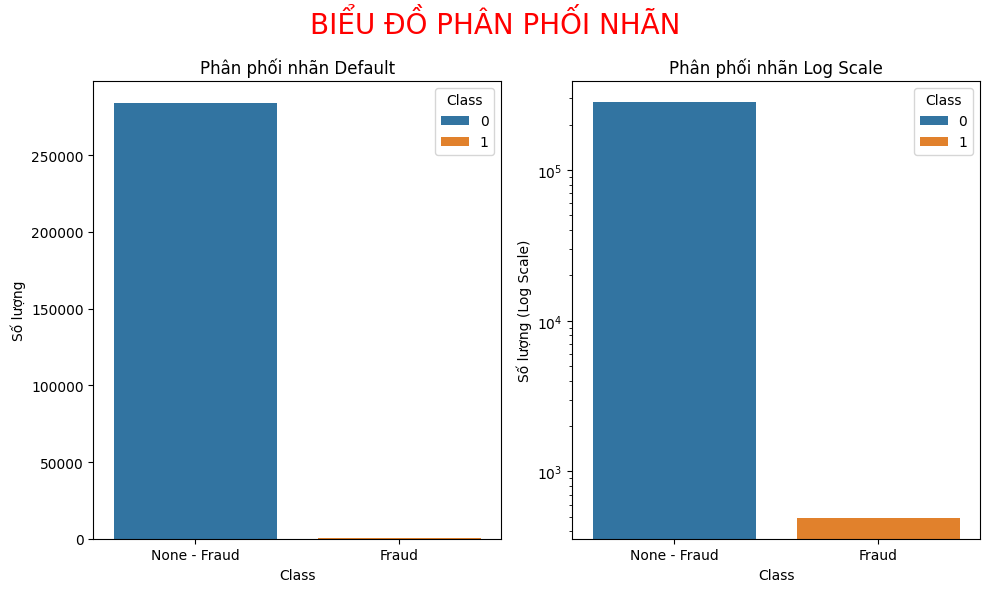

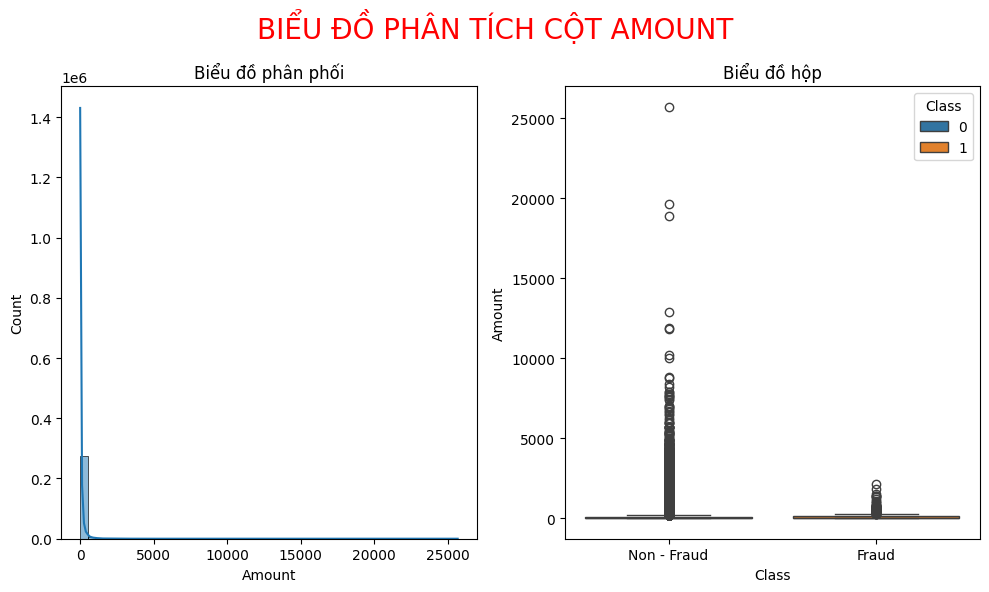

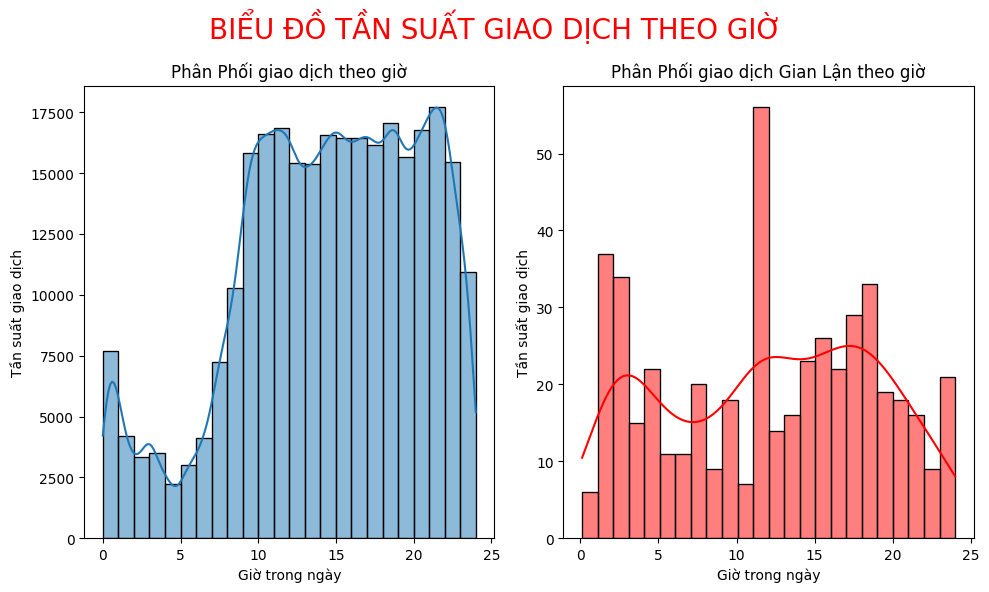

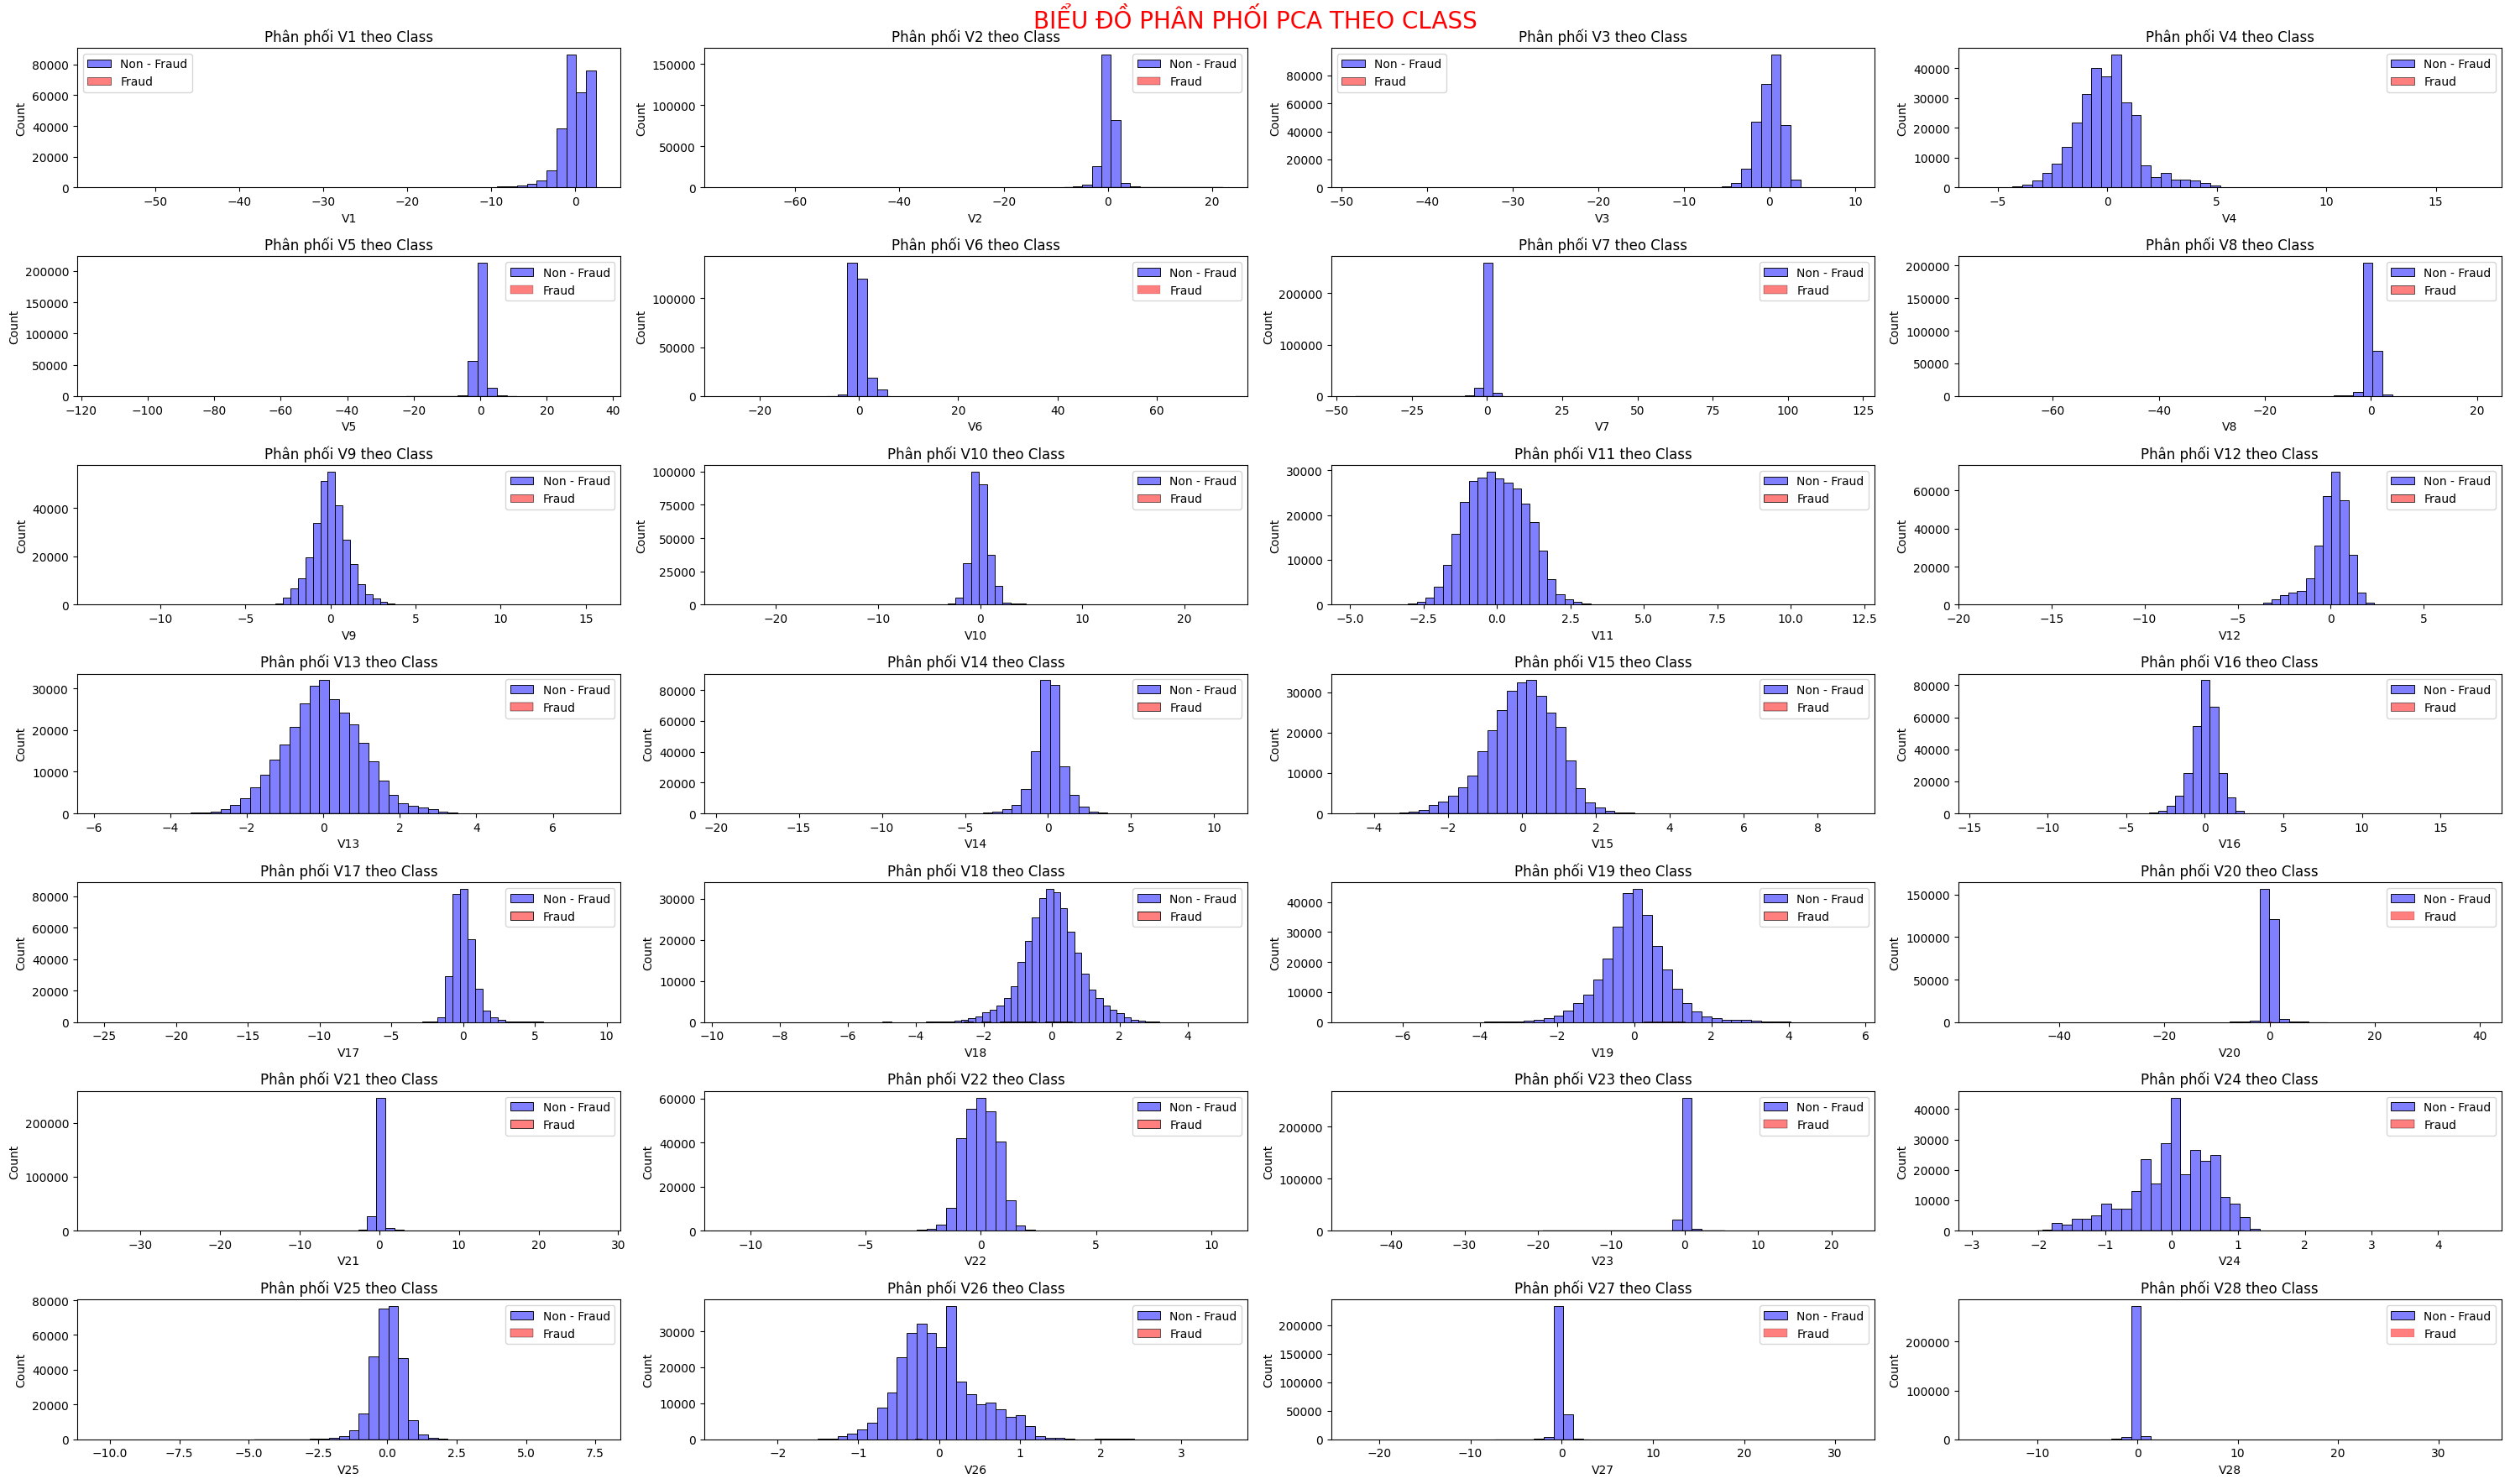

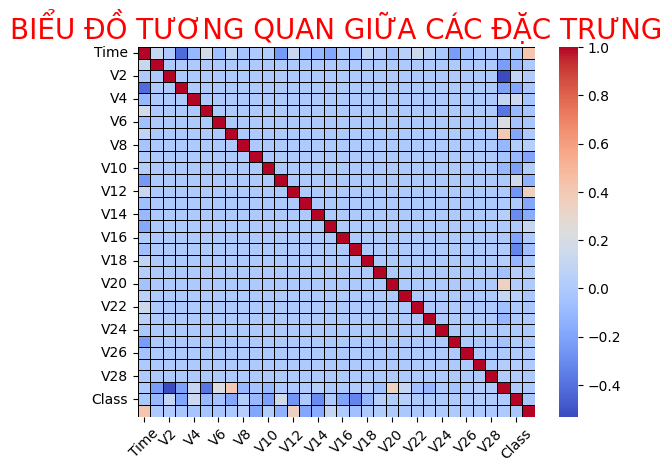

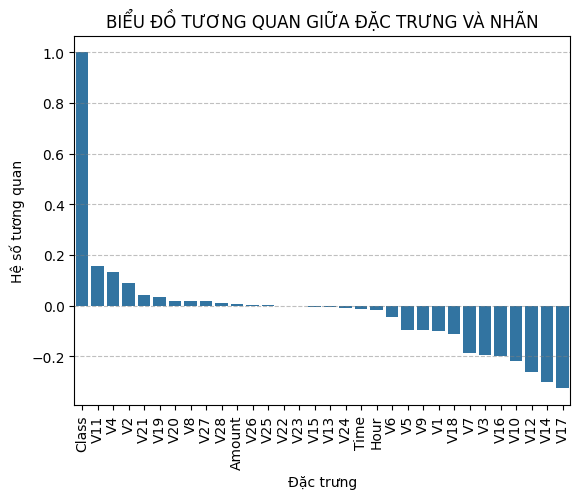

In [ ]:
def analyze_and_visualize_data(df):
    print("2. PHÂN TÍCH VÀ TRỰC QUAN HÓA DỮ LIỆU")
    print("-"*50)

    # 2.1. Phân tích và trực quan hóa biến mục tiêu
    fig1 = plt.figure(figsize = (10, 6))

    plt.subplot(1,2,1)
    sns.countplot(data = df, x = 'Class', hue = 'Class')
    plt.title("Phân phối nhãn Default")
    plt.xlabel("Class")
    plt.ylabel("Số lượng")
    plt.xticks([0,1], ['None - Fraud', 'Fraud'])

    plt.subplot(1,2,2)
    sns.countplot(data = df, x = 'Class', hue = 'Class')
    plt.title("Phân phối nhãn Log Scale")
    plt.xlabel("Class")
    plt.ylabel("Số lượng (Log Scale)")
    plt.yscale('log')
    plt.xticks([0,1], ['None - Fraud', 'Fraud'])

    fig1.suptitle("BIỂU ĐỒ PHÂN PHỐI NHÃN", fontsize = 20, color = 'red')
    plt.tight_layout()
    plt.show()
    plt.close()

    # 2.2. Phân tích và trực quan hóa cột Amount
    fig2 = plt.figure(figsize = (10,6))

    # Biểu đồ histogram
    plt.subplot(1,2,1)
    sns.histplot(data = df['Amount'], bins = 50, kde = True)
    plt.title("Biểu đồ phân phối")

    # Biểu đồ box
    plt.subplot(1,2,2)
    sns.boxplot(data = df, x = 'Class', y = 'Amount', hue = 'Class')
    plt.title("Biểu đồ hộp")
    plt.xticks([0,1], ['Non - Fraud', 'Fraud'])

    fig2.suptitle("BIỂU ĐỒ PHÂN TÍCH CỘT AMOUNT", fontsize = 20,color = 'red')
    plt.tight_layout()
    plt.show()
    plt.close()

    # 2.3. Phân tích và trực quan hóa cột Time
    fig3 = plt.figure(figsize = (10,6))

    # Tạo cột 'hour' trong df
    df['Hour'] = df['Time']/3600%24

    # Biểu đồ phân phối giao dịch theo giờ
    plt.subplot(1,2,1)
    sns.histplot(data = df['Hour'], kde = True, bins = 24)
    plt.title("Phân Phối giao dịch theo giờ")
    plt.xlabel("Giờ trong ngày")
    plt.ylabel("Tần suất giao dịch")

    # Biểu đồ phân phối giao dịch Gian Lận theo giờ
    plt.subplot(1,2,2)
    sns.histplot(data = df['Hour'][df['Class'] == 1], bins = 24, kde = True, color = 'red')
    plt.title("Phân Phối giao dịch Gian Lận theo giờ")
    plt.xlabel("Giờ trong ngày")
    plt.ylabel("Tần suất giao dịch")

    fig3.suptitle("BIỂU ĐỒ TẦN SUẤT GIAO DỊCH THEO GIỜ", fontsize = 20, color = 'red')
    plt.tight_layout()
    plt.show()
    plt.close()

    # 2.4 Phân tích và trực quan các đặc trưng PCA
    fig4 = plt.figure(figsize = (30, 18))
    pca_features = [f"V{i}" for i in range(1,29)]

    for i, feature in enumerate(pca_features):
        plt.subplot(7, 4, i+1)
        sns.histplot(df[df['Class'] == 0][feature], bins = 50, color = 'blue', alpha = 0.5, label = 'Non - Fraud')
        sns.histplot(df[df['Class'] == 1][feature], bins = 50, color = 'red', alpha = 0.5, label = 'Fraud')
        plt.title(f"Phân phối {feature} theo Class")
        plt.xlabel(feature)
        plt.legend()

    fig4 = plt.suptitle("BIỂU ĐỒ PHÂN PHỐI PCA THEO CLASS", fontsize = 20, color = 'red')
    plt.tight_layout()
    plt.show()
    plt.close()

    #2.5.1 Phân tích và vẽ biểu đồ TƯƠNG QUAN giữa các đặc trưng
    df_heat = df.corr()

    sns.heatmap(data = df_heat, annot = False, cmap = 'coolwarm', linecolor = 'black', linewidth = 0.5)
    plt.title("BIỂU ĐỒ TƯƠNG QUAN GIỮA CÁC ĐẶC TRƯNG", fontsize = 20, color = 'red')
    plt.xticks(rotation = 45)
    plt.show()
    plt.close()

    # 2.5.2 Phân tích tương quan với biến mục tiêu
    df_cor_target = df_heat["Class"].sort_values(ascending = False)
    sns.barplot(x = df_cor_target.index, y = df_cor_target.values)
    plt.title("BIỂU ĐỒ TƯƠNG QUAN GIỮA ĐẶC TRƯNG VÀ NHÃN")
    plt.xlabel("Đặc trưng")
    plt.ylabel("Hệ số tương quan")
    plt.xticks(rotation = 90)
    plt.grid(axis = 'y', linestyle = '--', color = 'gray', alpha = 0.5)
    plt.show()
    plt.close()

    return df
df = analyze_and_visualize_data(df)

### 👉 Trực quan hóa biến mục tiêu


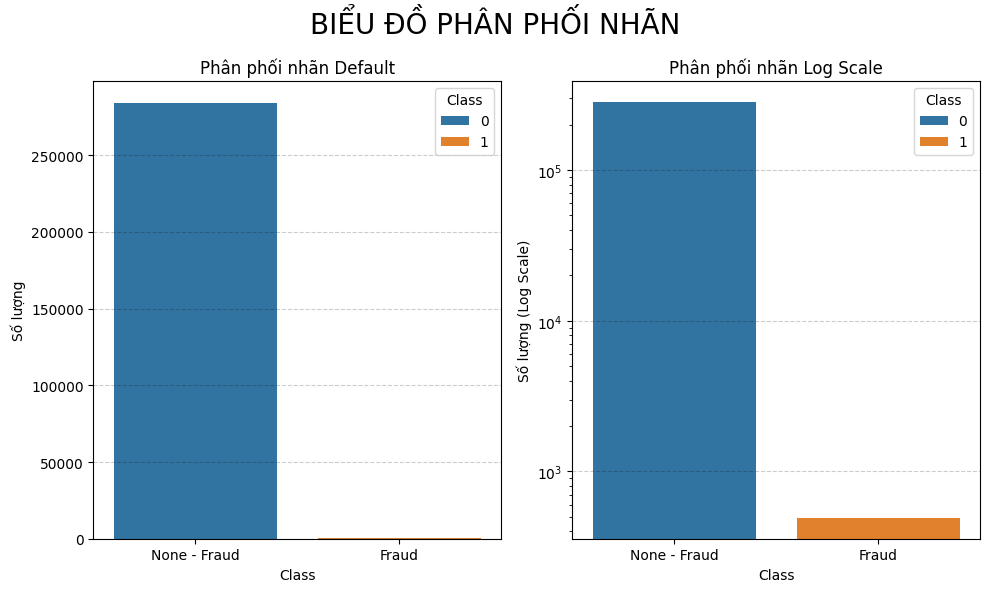

In [ ]:
def Vis_Class(df, target):
    # 2.1. Phân tích và trực quan hóa biến mục tiêu
    fig1 = plt.figure(figsize = (10, 6))

    plt.subplot(1,2,1)
    # Vẽ biểu đồ
    sns.countplot(
        data = df,
        x = target,
        hue = target
      )

    # Thêm thông tin cho biểu đồ
    plt.title("Phân phối nhãn Default")
    plt.xlabel("Class")
    plt.ylabel("Số lượng")
    plt.xticks([0,1], ['None - Fraud', 'Fraud'])

    # Thêm lưới
    plt.grid(
        axis = 'y',
        linestyle = '--',
        alpha = 0.2,
        color = 'black'
    )

    plt.subplot(1,2,2)
    # Vẽ biểu đồ
    sns.countplot(
        data = df,
        x = target,
        hue = target
      )

    # Thêm thông tin cho biểu đồ
    plt.title("Phân phối nhãn Log Scale")
    plt.xlabel("Class")
    plt.ylabel("Số lượng (Log Scale)")
    plt.yscale('log')
    plt.xticks([0,1], ['None - Fraud', 'Fraud'])
    fig1.suptitle("BIỂU ĐỒ PHÂN PHỐI NHÃN", fontsize = 20, color = 'black')

    # Thêm lưới
    plt.grid(
        axis = 'y',
        linestyle = '--',
        alpha = 0.2,
        color = 'black'
    )

    # Hiển thị
    plt.tight_layout()
    plt.show()
    plt.close()

Vis_Class(df, "Class")


### 👉 Trực quan hóa cột Amount


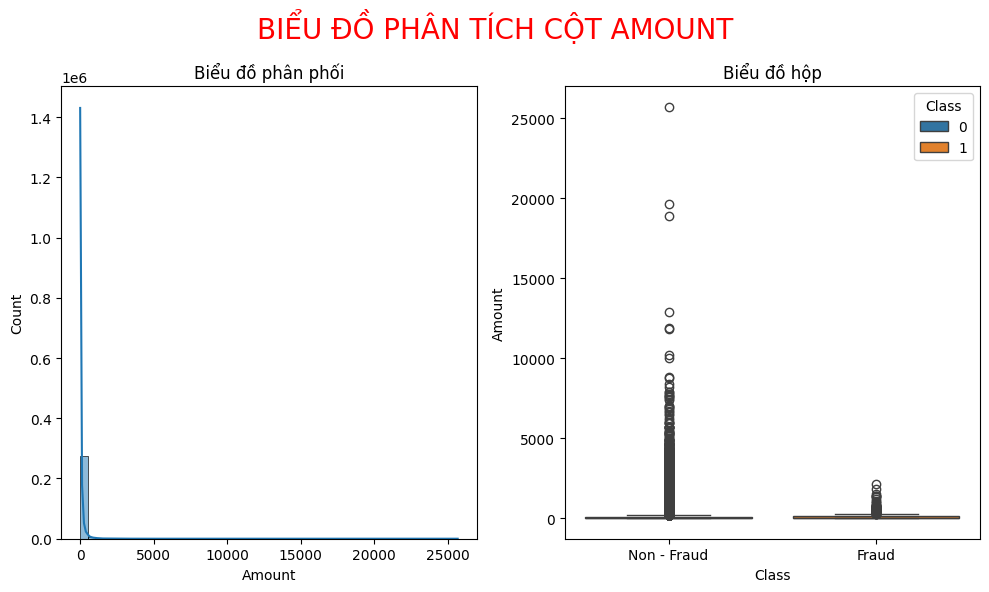

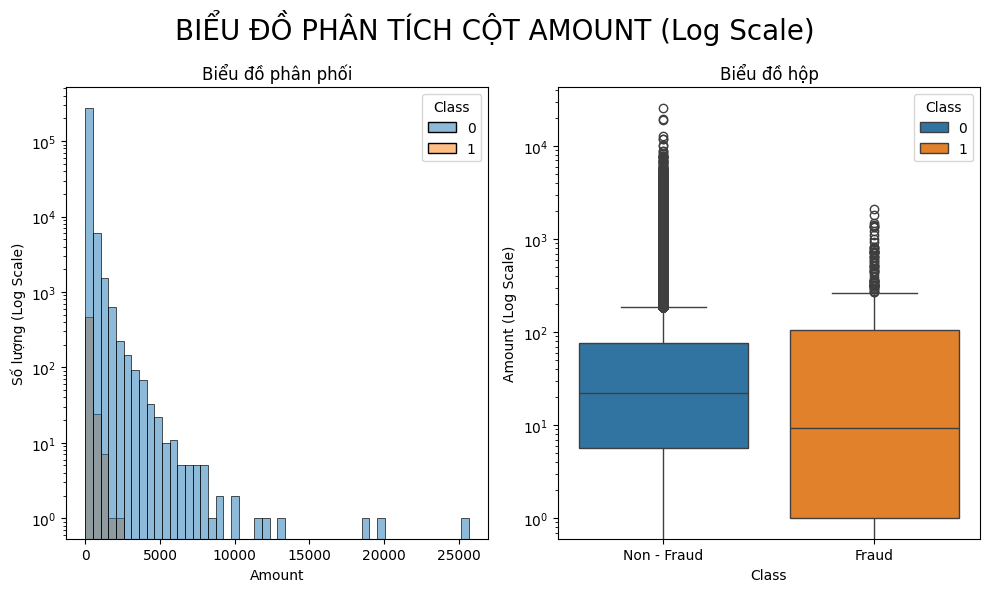

In [ ]:
# 2.2. Phân tích và trực quan hóa cột Amount
def Vis_Amount(df, col):
    fig2 = plt.figure(figsize = (10,6))

    # Biểu đồ histogram
    plt.subplot(1,2,1)
    sns.histplot(data = df['Amount'], bins = 50, kde = True)
    plt.title("Biểu đồ phân phối")

    # Biểu đồ box
    plt.subplot(1,2,2)
    sns.boxplot(data = df, x = 'Class', y = 'Amount', hue = 'Class')
    plt.title("Biểu đồ hộp")
    plt.xticks([0,1], ['Non - Fraud', 'Fraud'])

    fig2.suptitle("BIỂU ĐỒ PHÂN TÍCH CỘT AMOUNT", fontsize = 20,color = 'red')
    plt.tight_layout()
    plt.show()
    fig3 = plt.figure(figsize = (10,6))

    # Biểu đồ histogram
    plt.subplot(1,2,1)
    sns.histplot(
        data = df,
        x = col,
        bins = 50,
        hue = 'Class'
        #kde = True
      )
    plt.title("Biểu đồ phân phối")
    plt.yscale('log')
    plt.ylabel("Số lượng (Log Scale)")


    # Biểu đồ box
    plt.subplot(1,2,2)
    sns.boxplot(
        data = df,
        x = 'Class',
        y = col,
        hue = 'Class'
      )
    plt.title("Biểu đồ hộp")
    plt.xticks([0,1], ['Non - Fraud', 'Fraud'])
    plt.yscale('log')
    plt.ylabel("Amount (Log Scale)")

    fig3.suptitle(
        "BIỂU ĐỒ PHÂN TÍCH CỘT AMOUNT (Log Scale)",
        fontsize = 20,
        color = 'black'
      )
    plt.tight_layout()
    plt.show()
    plt.close()

Vis_Amount(df, "Amount")


### 👉 Trực quan hóa cột Time


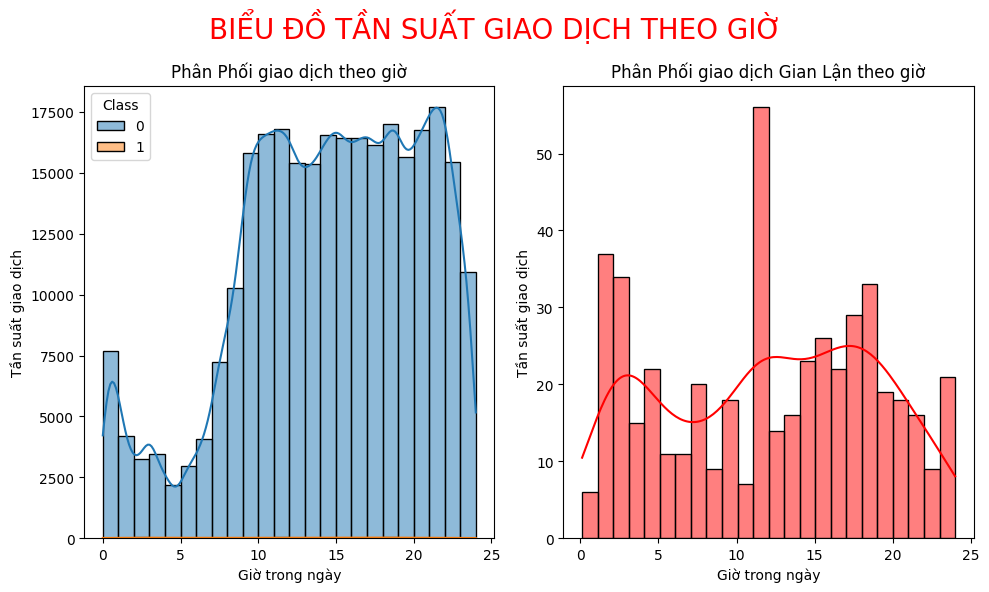

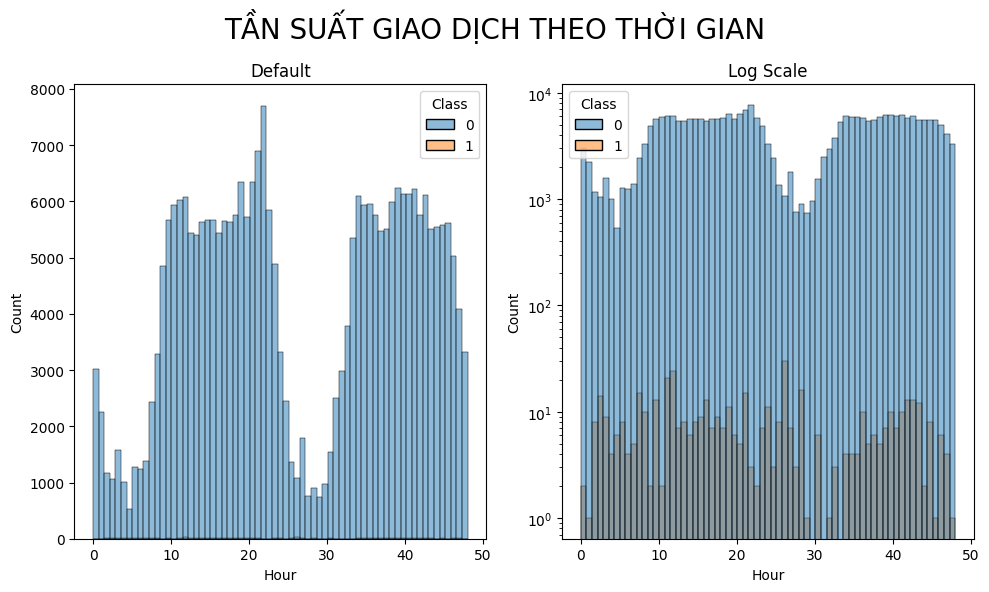

In [ ]:
 # 2.3. Phân tích và trực quan hóa cột Time
def Vis_Time(df):
    fig3 = plt.figure(figsize = (10,6))

    # Tạo cột 'hour' trong df
    df['Hour_of_day'] = df['Time']/3600%24

    # Biểu đồ phân phối giao dịch theo giờ
    plt.subplot(1,2,1)
    sns.histplot(
        data = df,
        x = 'Hour_of_day',
        kde = True,
        bins = 24,
        hue = "Class"
      )
    plt.title("Phân Phối giao dịch theo giờ")
    plt.xlabel("Giờ trong ngày")
    plt.ylabel("Tần suất giao dịch")

    # Biểu đồ phân phối giao dịch Gian Lận theo giờ
    plt.subplot(1,2,2)
    sns.histplot(
        data = df['Hour_of_day'][df['Class'] == 1],
        bins = 24,
        kde = True,
        color = 'red'
      )
    plt.title("Phân Phối giao dịch Gian Lận theo giờ")
    plt.xlabel("Giờ trong ngày")
    plt.ylabel("Tần suất giao dịch")

    fig3.suptitle("BIỂU ĐỒ TẦN SUẤT GIAO DỊCH THEO GIỜ", fontsize = 20, color = 'red')
    plt.tight_layout()
    plt.show()

    print("="*150)

    fig4 = plt.figure(figsize = (10, 6))

    df["Hour"] = df['Time'] / 3600

    plt.subplot(1,2,1)
    # Vẽ biểu đồ
    sns.histplot(
        data = df,
        x = 'Hour',
        hue = 'Class'
    )
    plt.title("Default")

    plt.subplot(1,2,2)
    # Vẽ biểu đồ
    sns.histplot(
        data = df,
        x = 'Hour',
        hue = 'Class'
    )
    plt.yscale('log')
    plt.title("Log Scale")

    fig4.suptitle(
        "TẦN SUẤT GIAO DỊCH THEO THỜI GIAN",
        fontsize = 20
      )
    plt.tight_layout()

    plt.show()
    plt.close()

Vis_Time(df)

### 👉 Trực quan hóa các đặc trưng PCA


#### 🔹Ver 1

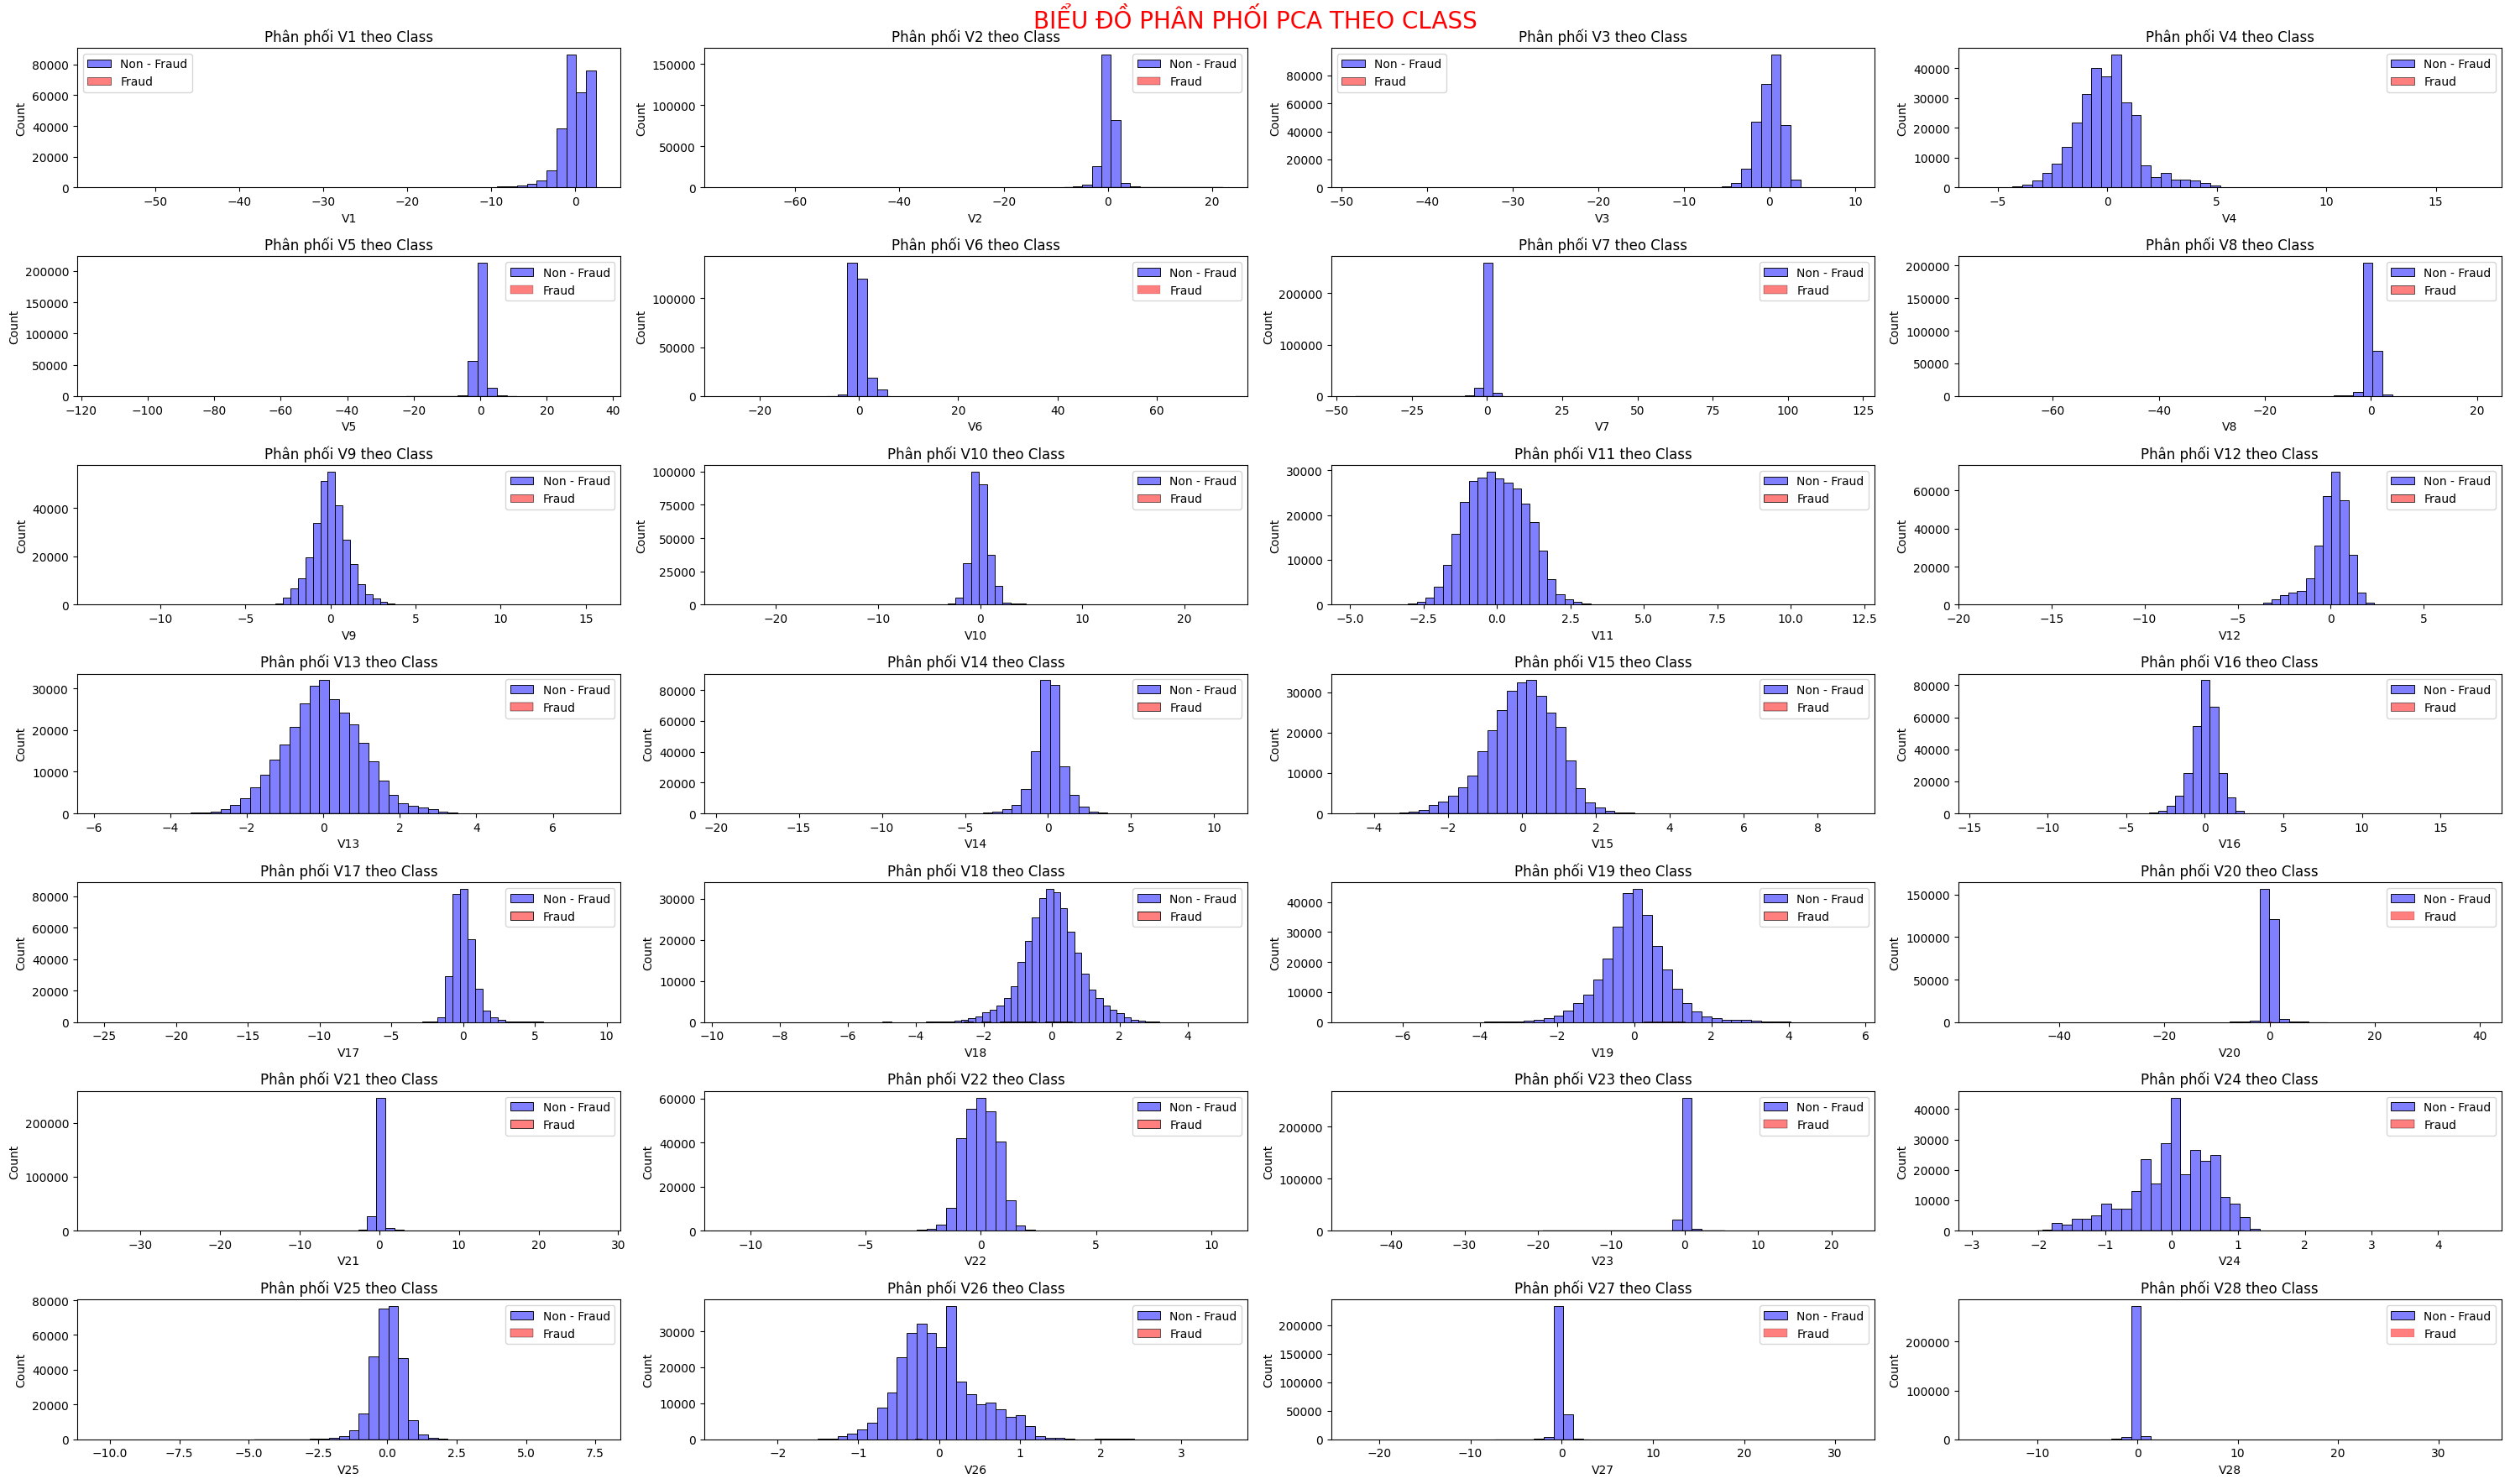

In [ ]:
def Vis_PCA(df):
    # 2.4 Phân tích và trực quan các đặc trưng PCA
    fig4 = plt.figure(figsize = (30, 18))
    pca_features = [f"V{i}" for i in range(1,29)]

    for i, feature in enumerate(pca_features):
        plt.subplot(7, 4, i+1)
        sns.histplot(
            df[df['Class'] == 0][feature],
            bins = 50,
            color = 'blue',
            alpha = 0.5,
            label = 'Non - Fraud'
          )
        sns.histplot(
            df[df['Class'] == 1][feature],
            bins = 50,
            color = 'red',
            alpha = 0.5,
            label = 'Fraud'
          )
        plt.title(f"Phân phối {feature} theo Class")
        plt.xlabel(feature)
        plt.legend()

    fig4 = plt.suptitle("BIỂU ĐỒ PHÂN PHỐI PCA THEO CLASS", fontsize = 20, color = 'red')
    plt.tight_layout()
    plt.show()
    plt.close()

Vis_PCA(df)

#### 🔹Ver 2

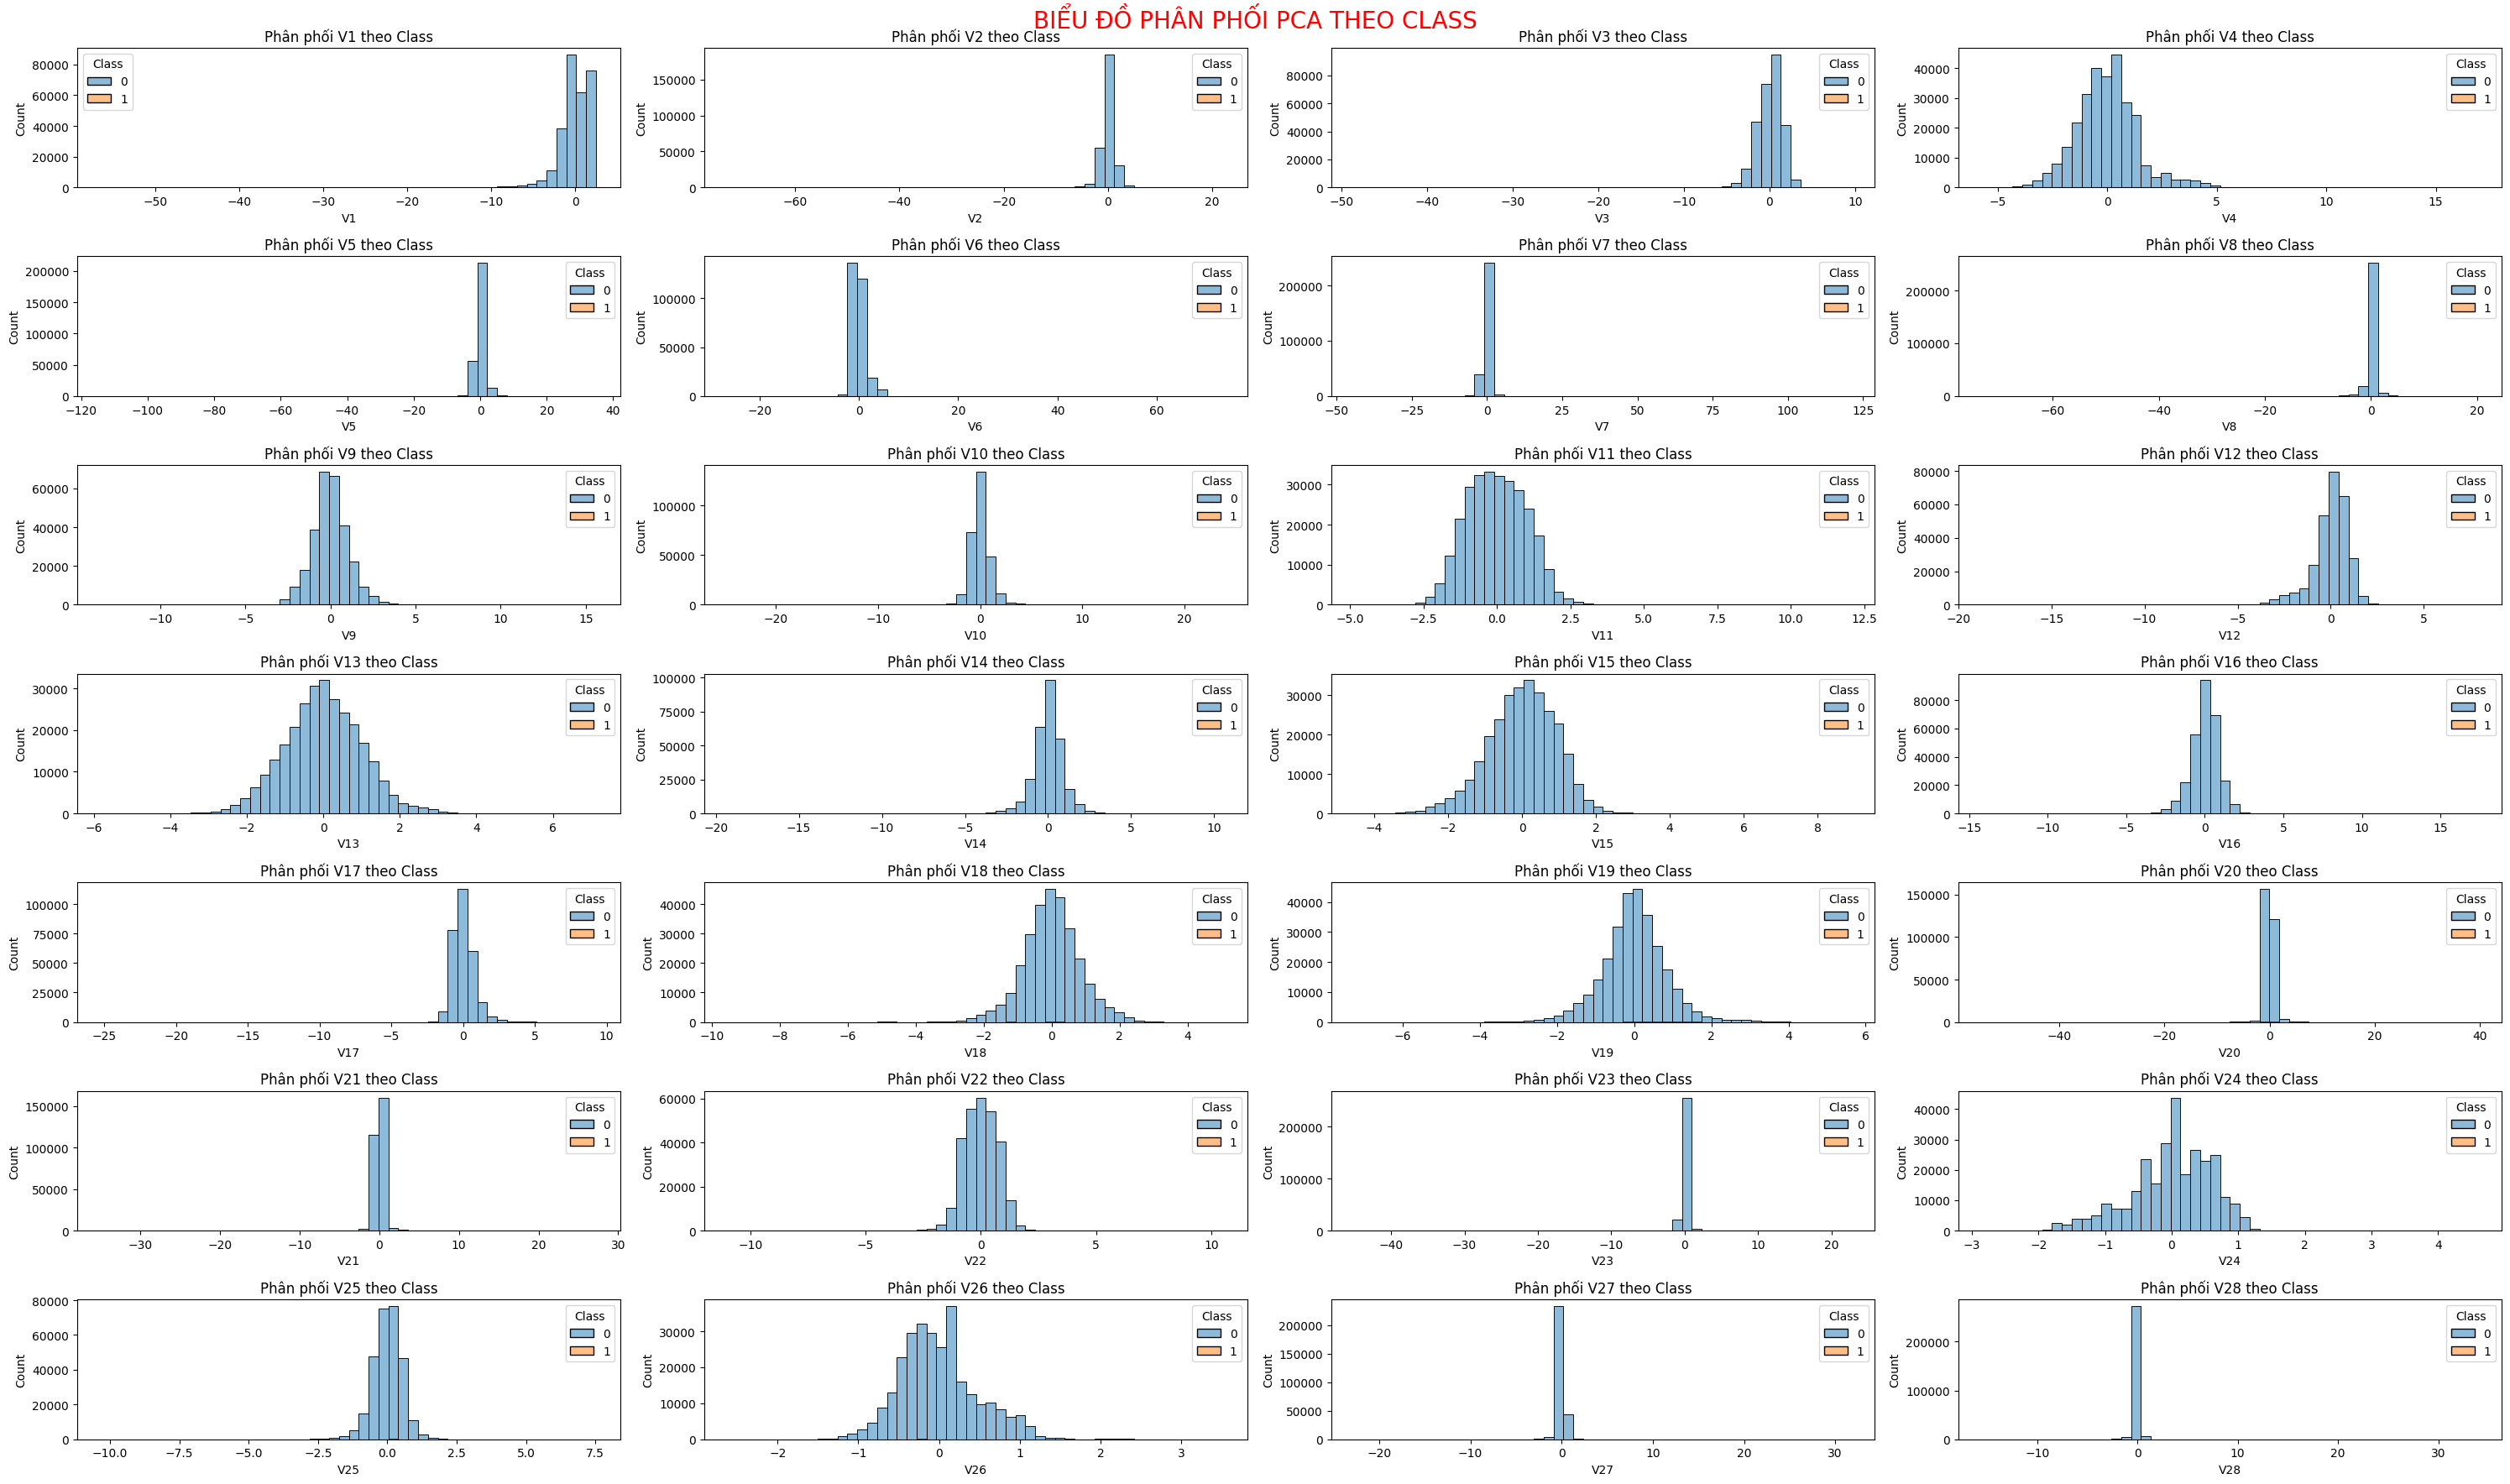

In [ ]:
def Vis_PCA(df):
    # 2.4 Phân tích và trực quan các đặc trưng PCA
    fig4 = plt.figure(figsize = (30, 18))
    pca_features = [f"V{i}" for i in range(1,29)]

    for i, feature in enumerate(pca_features):
        plt.subplot(7, 4, i+1)
        sns.histplot(
            data = df,
            x = df[feature],
            bins = 50,
            color = 'blue',
            alpha = 0.5,
            hue = 'Class'
          )
        plt.title(f"Phân phối {feature} theo Class")
        plt.xlabel(feature)

    fig4 = plt.suptitle("BIỂU ĐỒ PHÂN PHỐI PCA THEO CLASS", fontsize = 20, color = 'red')
    plt.tight_layout()
    plt.show()
    plt.close()

Vis_PCA(df)

#### 🔹Ver 3: So sánh Fraud - Non Fraud

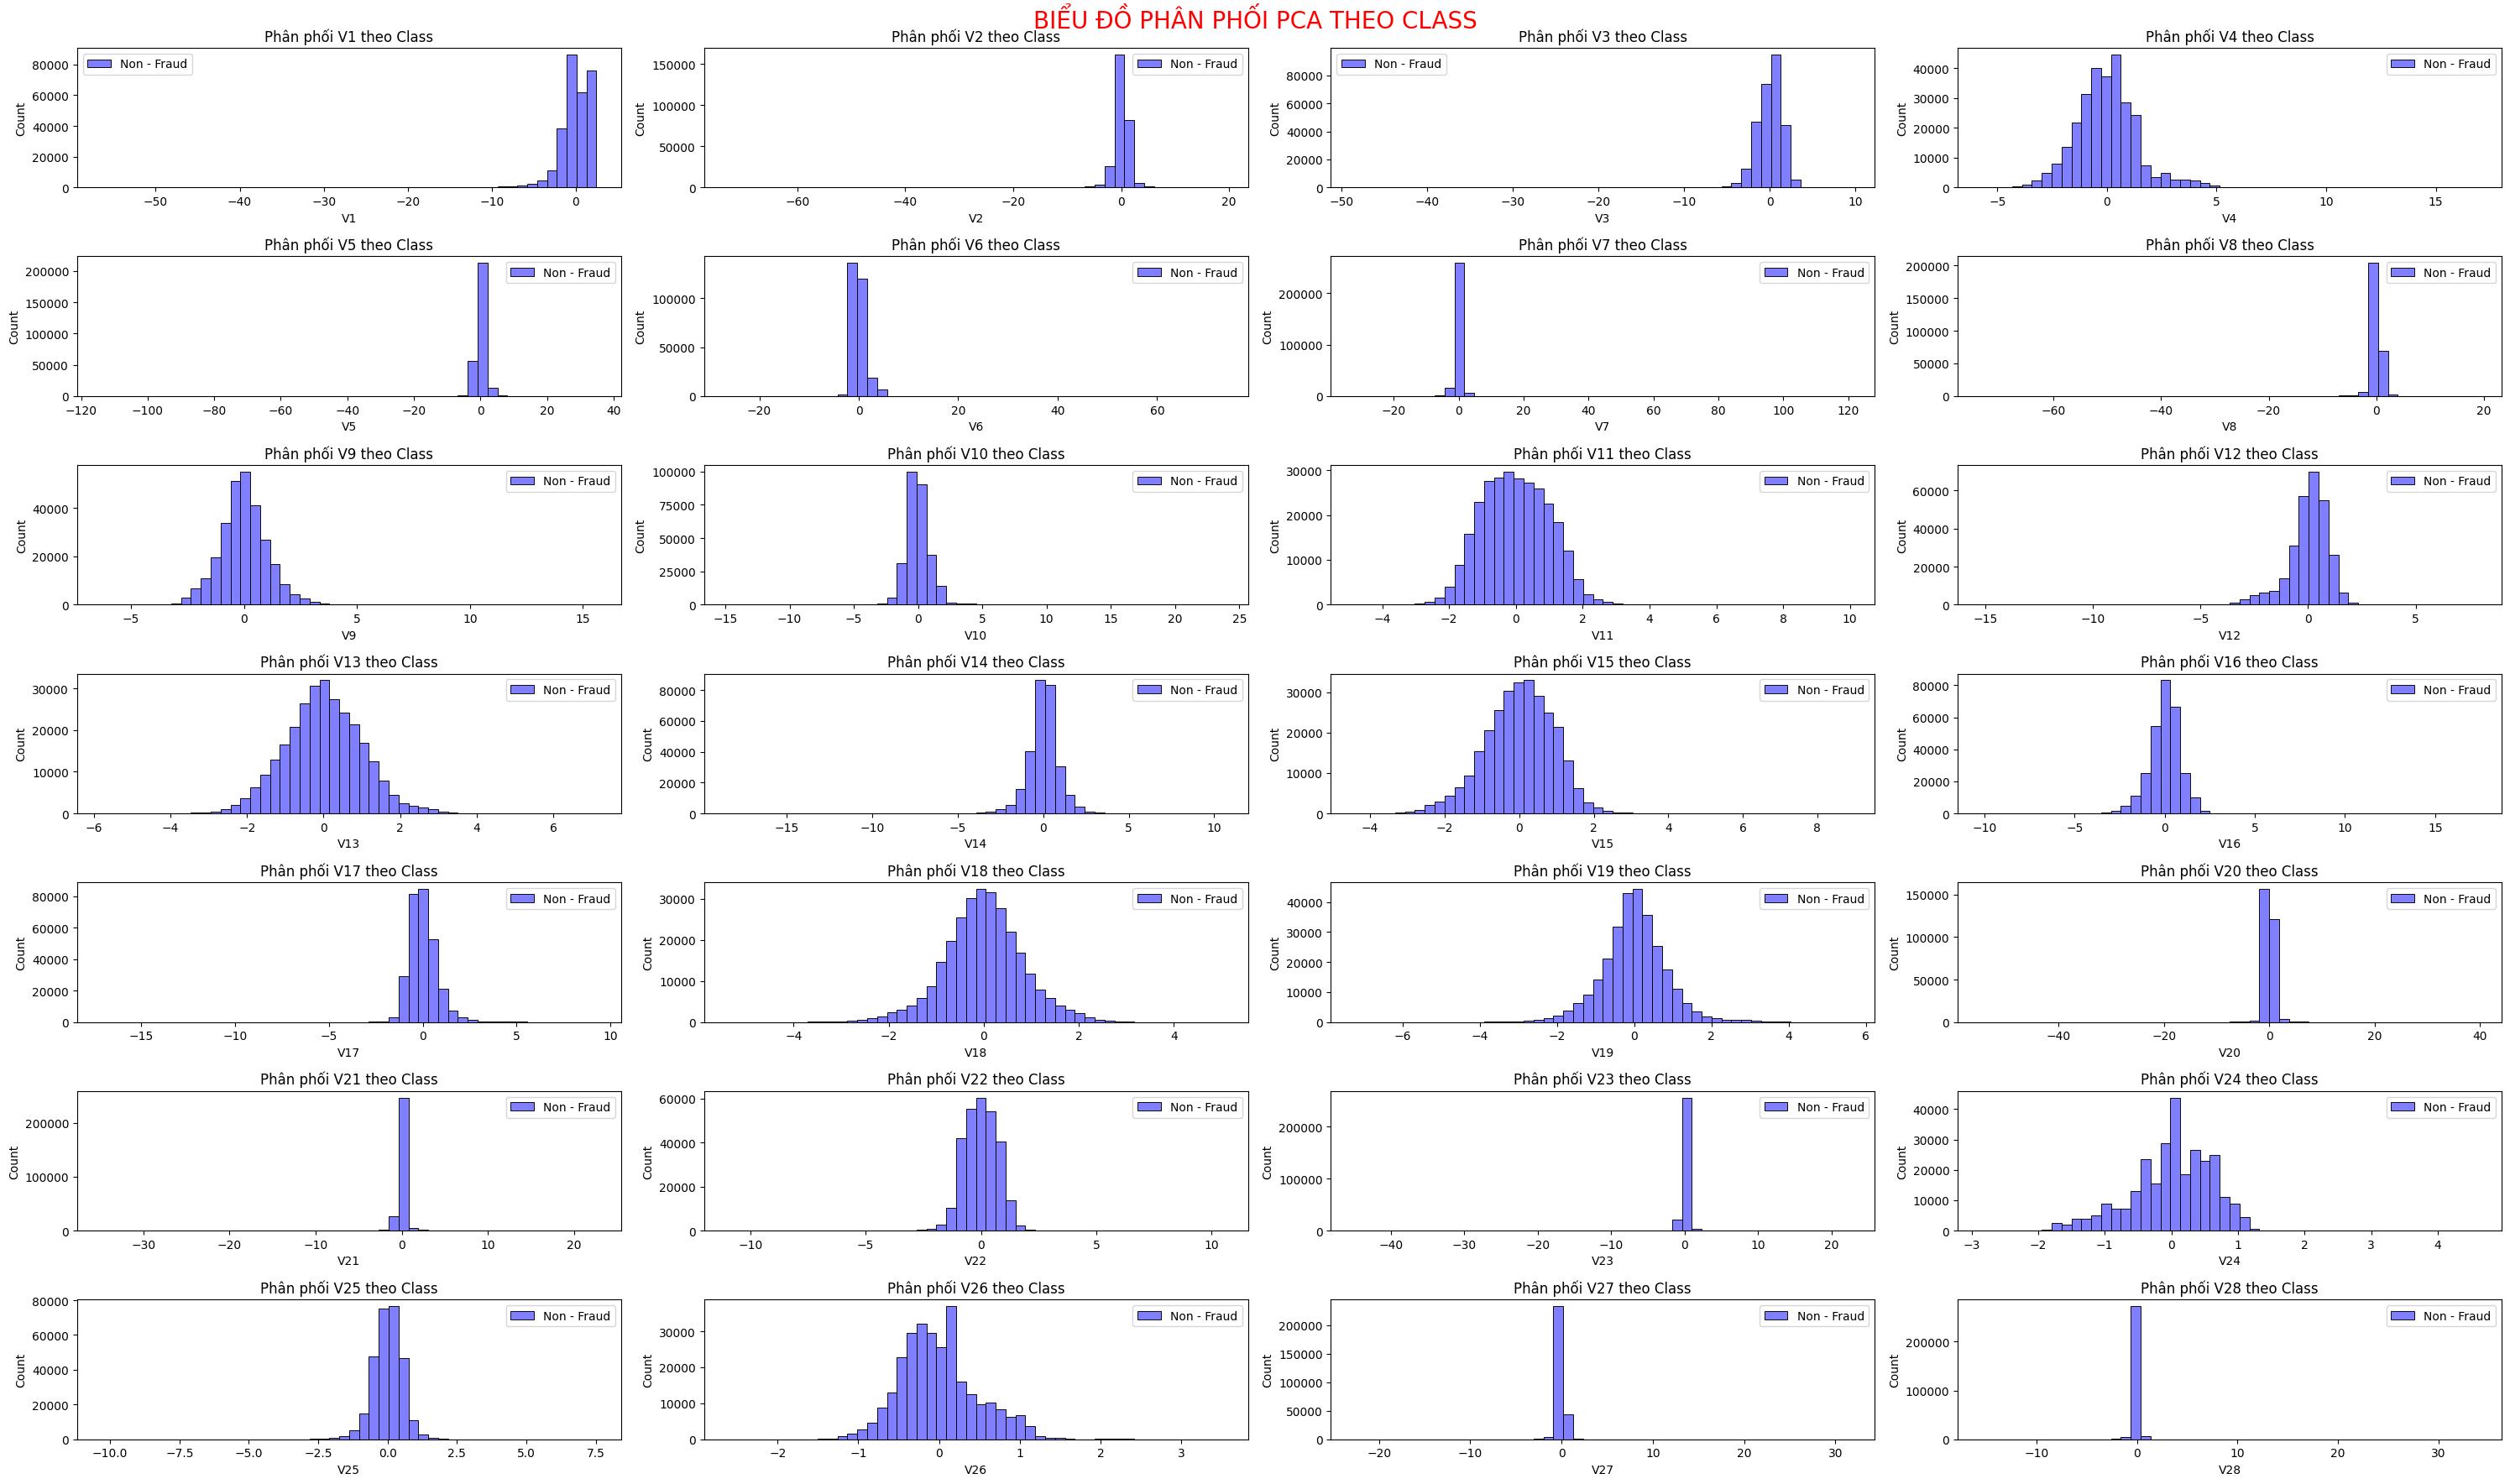

- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -


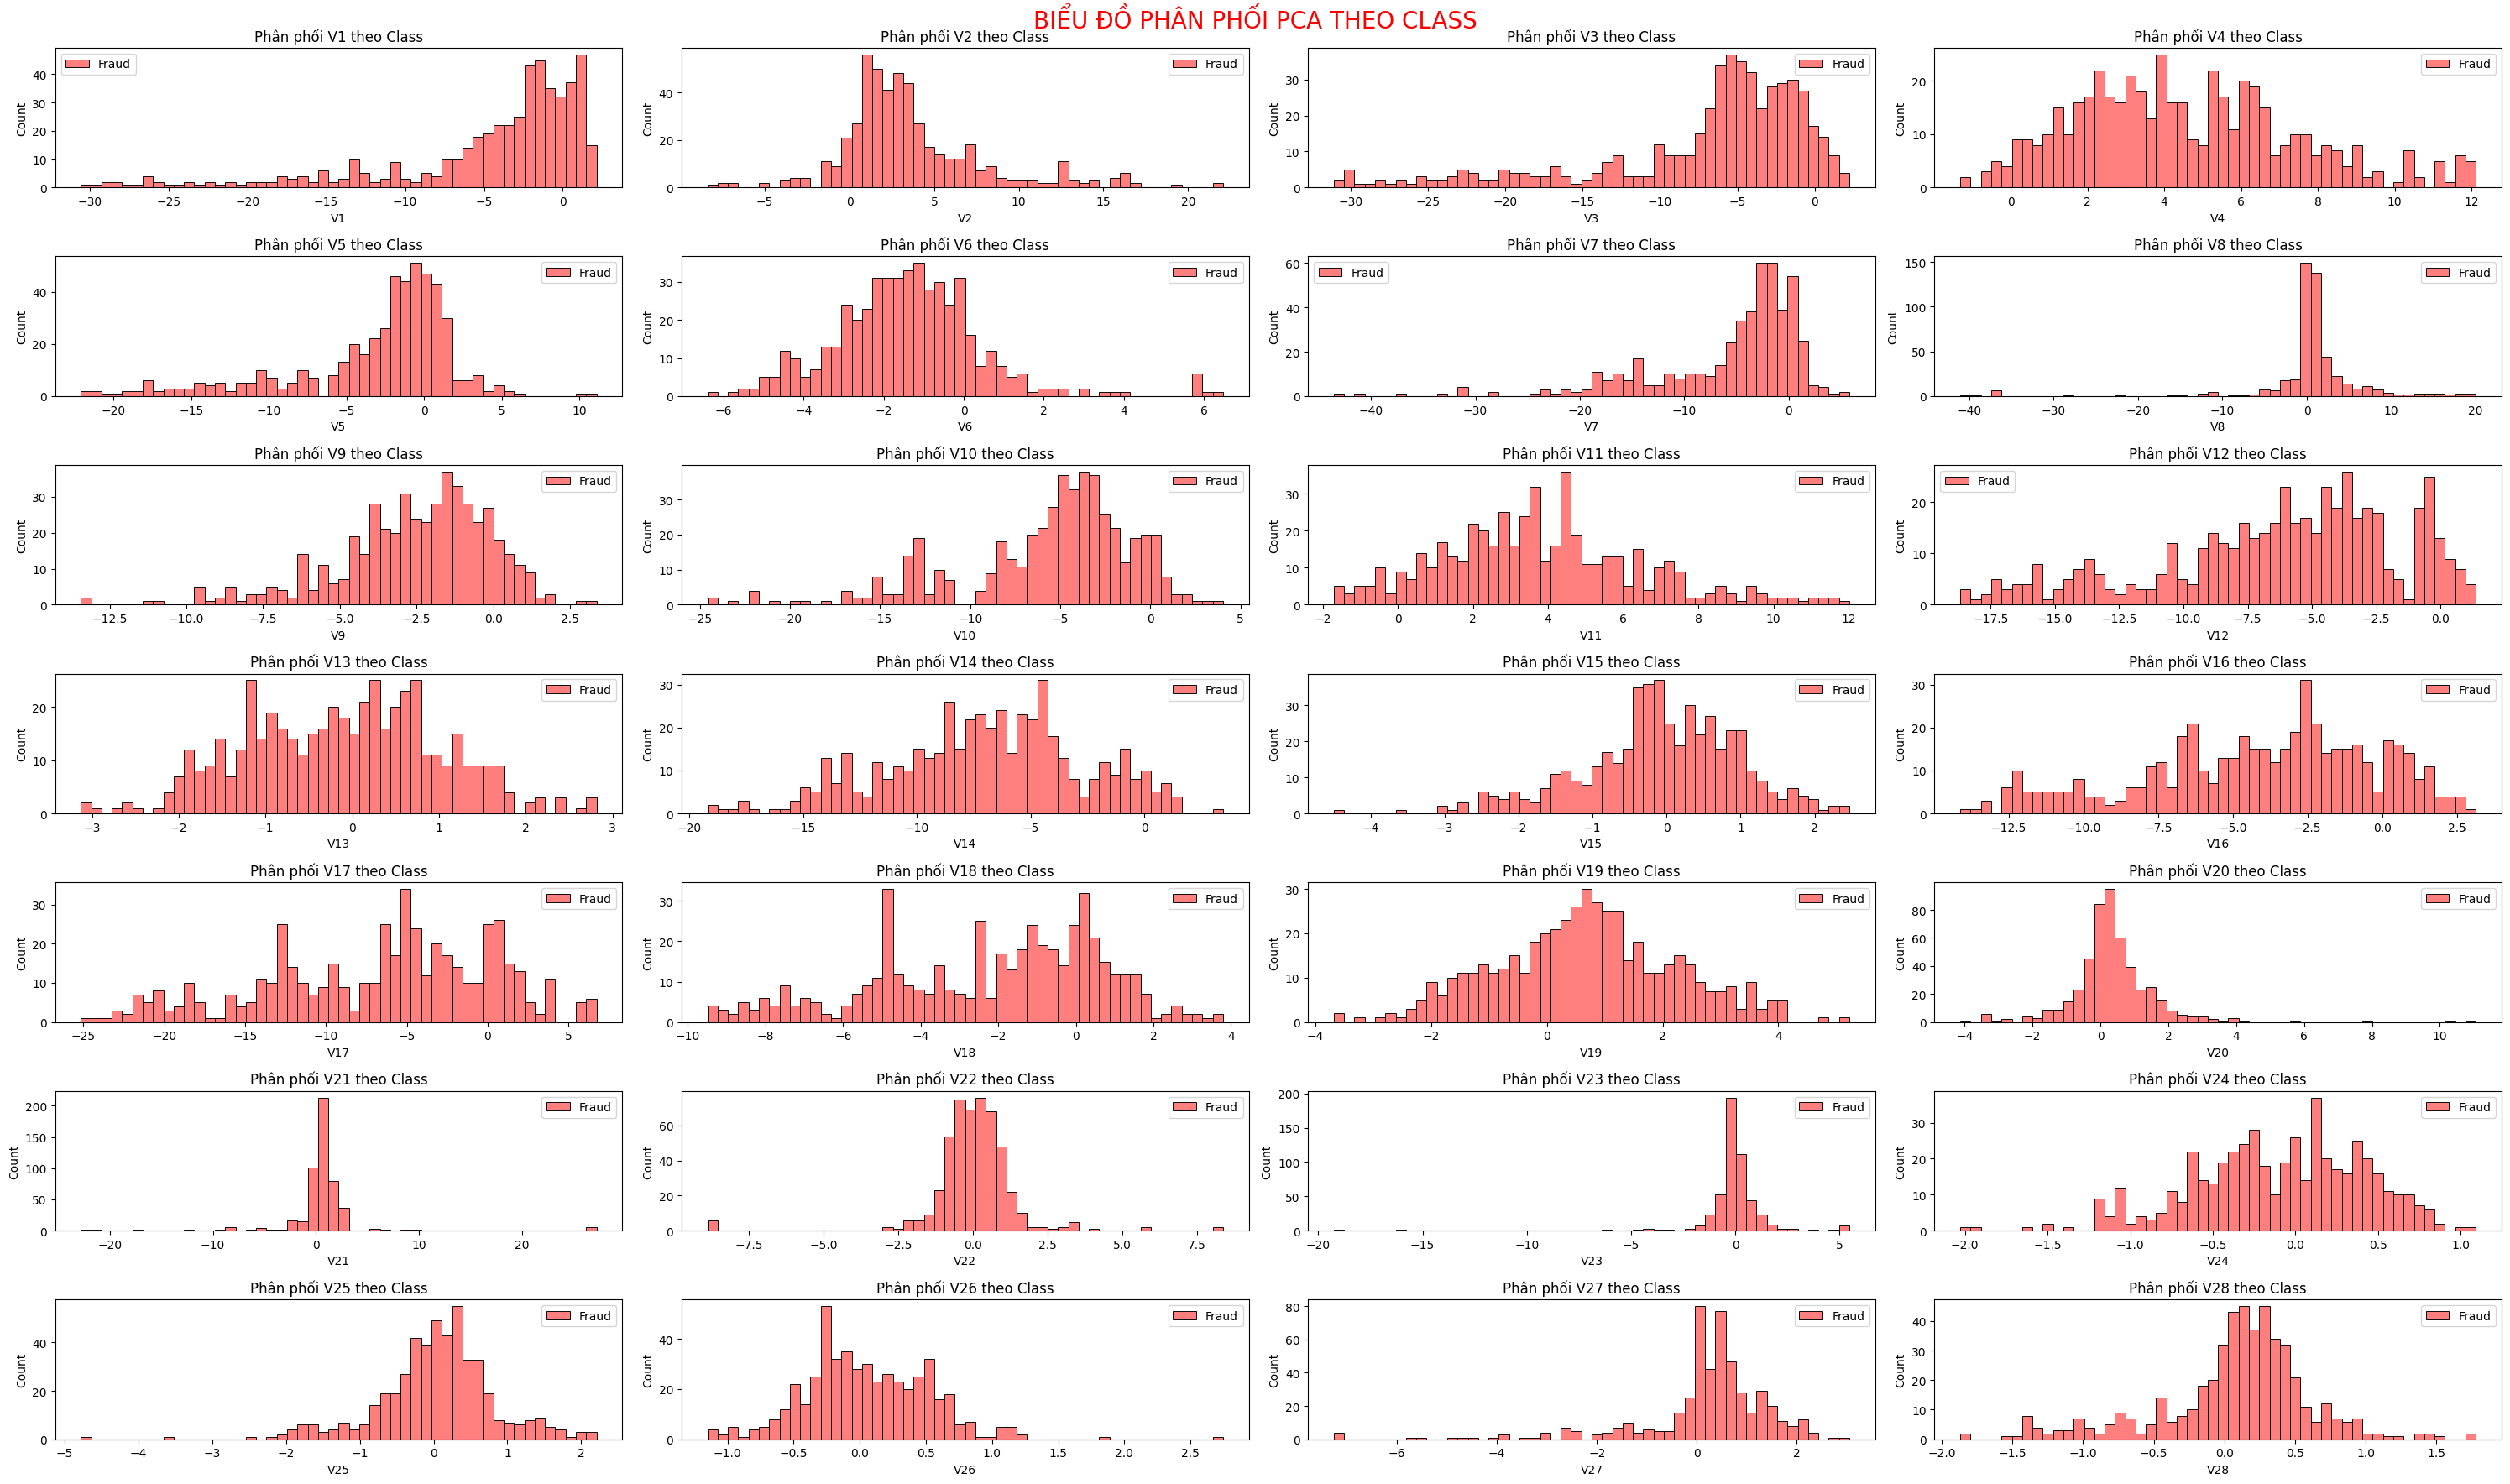

In [ ]:
def Vis_PCA_0(df):
    # 2.4 Phân tích và trực quan các đặc trưng PCA
    fig4 = plt.figure(figsize = (30, 18))
    pca_features = [f"V{i}" for i in range(1,29)]

    for i, feature in enumerate(pca_features):
        plt.subplot(7, 4, i+1)
        sns.histplot(
            df[df['Class'] == 0][feature],
            bins = 50,
            color = 'blue',
            alpha = 0.5,
            label = 'Non - Fraud'
          )

        plt.title(f"Phân phối {feature} theo Class")
        plt.xlabel(feature)
        plt.legend()

    fig4 = plt.suptitle("BIỂU ĐỒ PHÂN PHỐI PCA THEO CLASS", fontsize = 20, color = 'red')
    plt.tight_layout()
    plt.show()
    plt.close()

def Vis_PCA_1(df):
    # 2.4 Phân tích và trực quan các đặc trưng PCA
    fig4 = plt.figure(figsize = (30, 18))
    pca_features = [f"V{i}" for i in range(1,29)]

    for i, feature in enumerate(pca_features):
        plt.subplot(7, 4, i+1)
        sns.histplot(
            df[df['Class'] == 1][feature],
            bins = 50,
            color = 'red',
            alpha = 0.5,
            label = 'Fraud'
          )
        plt.title(f"Phân phối {feature} theo Class")
        plt.xlabel(feature)
        plt.legend()

    fig4 = plt.suptitle("BIỂU ĐỒ PHÂN PHỐI PCA THEO CLASS", fontsize = 20, color = 'red')
    plt.tight_layout()
    plt.show()
    plt.close()

Vis_PCA_0(df)

print('='*300)
print('- -'*100)
print('='*300)

Vis_PCA_1(df)

##✅3. Tiền xử lý dữ liệu và Phân tích dữ liệu
    3.1 Thêm đặc trưng
    3.2 Tách các biến đặc trưng và biến mục tiêu: tạo Data và Nhãn
    3.3 Chia tập huấn luyện
    3.4 Kiểm tra phân phối của y trong tập train và test
    3.5 Chuẩn hóa dữ liệu Amount và Time
    => Không cần chuẩn hóa cho RF, chuẩn hóa trong code mẫu là dùng cho nhiều mô hình

### 👉 Module hóa


In [ ]:
# Thêm đặc trưng
def add_is_night(df):
    df['Is_Night'] = ((df['Hour'] >= 0) & (df['Hour'] <= 5)).astype(int)
    print("Đã thêm đặc trưng Is_Night vào Data")
    print("-"*100)
    return df

def add_High_Amount(df):
    df['High_Amount'] = (df['Amount'] > 1000).astype(int)
    print("Đã thêm đặc trưng High_Amount vào Data")
    print("-"*100)
    return df

def add_Amount_Bins(df):
    bins = [0, 100, 500, 1000, 5000, 2000000]
    labels = [0, 1, 2, 3, 4]
    df['Amount_Bins'] = pd.cut(df['Amount'], bins = bins, labels = labels, include_lowest=True)
    df['Amount_Bins'] = df['Amount_Bins'].astype(int)
    print("Đã thêm đặc trưng Amount_Bins vào Data")
    print("-"*100)
    return df

def add_High_Amount_at_Night(df):
    df['High_Amount_at_Night'] = (df['High_Amount'] & df['Is_Night']).astype(int)
    print("Đã thêm đặc trưng High_Amount_at_Night vào Data")
    print("-"*100)

    return df

# Hàm trực quan hóa
def analize_binary_feature(df, col, target = 'Class', Viz = False):
    print(f"Phân tích đặc trưng {col}:")
    print("-"*100)
    print(df[col].value_counts())
    dataa = df.groupby(col)[target].mean()
    # Với Is Night: trung bình tỉ lệ giao dịch gian lận ban ngày và ban đêm
    print(dataa)

    if Viz:
        print(f"Trực quan hóa cột {col}:")
        print("-"*100)

        fig1 = plt.figure(figsize = (14, 8))

        # Biểu đồ thứ nhất
        plt.subplot(1,2,1)
        sns.countplot(
            data = df,
            x = col,
            hue = target
          )
        plt.yscale('log')
        plt.title(f'Phân tích Fraud - {col}')
        plt.xlabel(col)
        plt.ylabel('Tần suất xuất hiện (Log Scale)')

        # Biểu đồ thứ hai
        plt.subplot(1,2,2)
        # Phương pháp 2: Chuyển Series thành DataFrame và vẽ bằng seaborn
        dataa_df = dataa.reset_index()  # Chuyển Series thành DataFrame
        dataa_df.columns = [col, target]  # Đặt tên cho các cột

        sns.barplot(
            data = dataa_df,
            x = col,
            y = target,
            hue = col
          )
        plt.title(f'Giá trị trung bình của {target} theo {col}')
        plt.ylabel(f'Giá trị trung bình của {target}')

        fig1.suptitle(f"BIỂU ĐỒ PHÂN TÍCH BIẾN {col}", fontsize = 25, color = 'black')
        plt.tight_layout()

        plt.show()
        print("-"*100)

### 👉 Tiền xử lý

In [ ]:
# Hàm tiền xử lý dữ liệu
def preprocess_data(df):
    print("\n TIỀN XỬ LÝ DỮ LIỆU:")
    print("-"*100)

    #3.1 Thêm đặc trưng phi tuyến
    print("Tiến hành thêm đặc trưng phi tuyến:")
    print("-"*100)

    # Thêm đặc trưng Is_Night
    df = add_is_night(df)
    analize_binary_feature(df, col = 'Is_Night', Viz = False)

    # Thêm đặc trưng High_Amount
    df = add_High_Amount(df)
    analize_binary_feature(df, col = 'High_Amount', Viz = False)

    # Thêm đặc trưng Amount_Bins
    df = add_Amount_Bins(df)
    analize_binary_feature(df, col = 'Amount_Bins', Viz = False)

    # Thêm đặc trưng High_Amount_at_Night
    df = add_High_Amount_at_Night(df)
    analize_binary_feature(df, col = 'High_Amount_at_Night', Viz = False)

    #3.2 Tách biến đặc trưng và mục tiêu
    print("Tiến hành tách biến đặc trưng và mục tiêu!")
    X = df.drop(['Class', 'Time'], axis = 1)
    y = df['Class']
    print("-"*100)

    X = X.copy()
    if "Amount" in X.columns:
        X["Amount"] = np.log1p(X["Amount"])

    #3.3 Chia tập huấn luyện
    print("Tiến hành chia tập huấn luyện!")
    print('-'*100)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

    # Kiểm tra lại phân phối nhãn trong tập Train và Test
    print("Tỷ lệ nhãn Fraud trong tập train: ", Counter(y_train)[1]/len(X_train))
    print("Tỷ lệ nhãn Fraud trong tập test: ", Counter(y_test)[1]/len(X_test))

    # Chuẩn hóa: đối với Amount
    robust_scaler = RobustScaler()
    X_train['Amount'] = robust_scaler.fit_transform(X_train['Amount'].values.reshape(-1, 1))
    X_test['Amount'] = robust_scaler.transform(X_test['Amount'].values.reshape(-1, 1))
    print('-'*100)
    print("Đã chuẩn hóa RobustScaler cho cột Amount!")

    return X_train, X_test, y_train, y_test

# Thực hiện tiền xử lý dữ liệu
X_train, X_test, y_train, y_test = preprocess_data(df)



 TIỀN XỬ LÝ DỮ LIỆU:
----------------------------------------------------------------------------------------------------
Tiến hành thêm đặc trưng phi tuyến:
----------------------------------------------------------------------------------------------------
Đã thêm đặc trưng Is_Night vào Data
----------------------------------------------------------------------------------------------------
Phân tích đặc trưng Is_Night:
----------------------------------------------------------------------------------------------------
Is_Night
0    263862
1     20945
Name: count, dtype: int64
Is_Night
0    0.001436
1    0.005395
Name: Class, dtype: float64
Đã thêm đặc trưng High_Amount vào Data
----------------------------------------------------------------------------------------------------
Phân tích đặc trưng High_Amount:
----------------------------------------------------------------------------------------------------
High_Amount
0    281867
1      2940
Name: count, dtype: int64
High_Amount


In [ ]:
display(X_train)

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V25,V26,V27,V28,Amount,Hour,Is_Night,High_Amount,Amount_Bins,High_Amount_at_Night
265518,1.946747,-0.752526,-1.355130,-0.661630,1.502822,4.024933,-1.479661,1.139880,1.406819,-0.157403,...,-0.350316,-0.388907,0.077641,-0.032248,-0.411696,20.977500,0,0,0,0
180305,2.035149,-0.048880,-3.058693,0.247945,2.943487,3.298697,-0.002192,0.674782,0.045826,0.284864,...,0.512885,-0.471198,0.002520,-0.069002,-0.709232,10.576944,0,0,0,0
42664,-0.991920,0.603193,0.711976,-0.992425,-0.825838,1.956261,-2.212603,-5.037523,0.000772,-2.009561,...,0.826684,0.913773,0.038049,0.185340,0.824159,11.441944,0,0,1,0
198723,2.285718,-1.500239,-0.747565,-1.668119,-1.394143,-0.350339,-1.427984,0.010010,-1.118447,1.756121,...,-0.278032,-0.162068,0.018045,-0.063005,-0.475897,12.840000,0,0,0,0
82325,-0.448747,-1.011440,0.115903,-3.454854,0.715771,-0.147490,0.504347,-0.113817,-0.044782,-0.558955,...,-0.292234,-0.144622,-0.032580,-0.064194,0.539125,16.488611,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
233802,1.993864,-0.516866,-0.620118,0.129845,-0.285128,0.395044,-0.822358,0.231591,0.995898,0.212619,...,-0.195404,0.623598,-0.032455,-0.058552,-0.482219,17.030556,0,0,0,0
85418,-1.497933,0.657921,1.581568,-0.024286,0.584698,1.303031,0.609212,0.135561,0.452745,0.108640,...,-0.425883,0.263968,-0.448445,0.045178,0.203181,16.878889,0,0,0,0
29062,1.069777,0.072105,0.496540,1.505318,-0.380277,-0.370243,0.100551,-0.026687,0.319684,-0.131553,...,0.593314,-0.335160,0.031014,0.024886,0.284322,9.805833,0,0,0,0
13766,1.280465,0.300586,0.333044,0.512720,0.065052,-0.145844,-0.145519,-0.091833,1.111187,-0.268878,...,0.278428,0.089546,-0.059835,-0.005887,-1.011765,6.781389,0,0,0,0


### 👉 Kiểm tra lại phân phối Amount


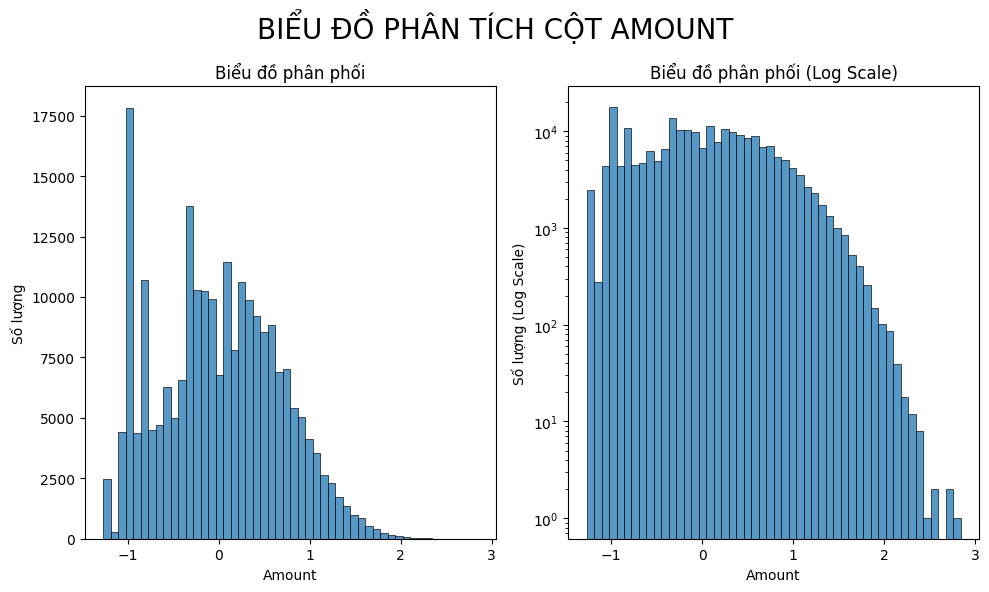

In [ ]:
# 3.2. Phân tích và trực quan hóa cột Amount sau Robust Scale
def Vis_Amount_test(df, col):
    fig3 = plt.figure(figsize = (10,6))

    # Biểu đồ histogram ko log
    plt.subplot(1,2,1)
    sns.histplot(
        data = df,
        x = col,
        bins = 50,
        #kde = True
      )
    plt.title("Biểu đồ phân phối")
    plt.ylabel("Số lượng")

    # Biểu đồ histogram có log scale
    plt.subplot(1,2,2)
    sns.histplot(
        data = df,
        x = col,
        bins = 50,
        #kde = True
      )
    plt.title("Biểu đồ phân phối (Log Scale)")
    plt.yscale('log')
    plt.ylabel("Số lượng (Log Scale)")

    fig3.suptitle(
        "BIỂU ĐỒ PHÂN TÍCH CỘT AMOUNT",
        fontsize = 20,
        color = 'black'
      )
    plt.tight_layout()
    plt.show()
    plt.close()

Vis_Amount_test(X_train, "Amount")


##✅4. Xử lý dữ liệu

        

### 👉 Xử lý mất cân bằng


        - Random Under-sampling
        - SMOTE (Synthetic Minority Over-sampling Technique)
        - Kết hợp Under-sampling với SMOTE

In [ ]:
# Xử lý mất cân bằng dữ liệu

def handle_imbalanced_data(X_train, y_train):
    print("XỬ LÝ MẤT CÂN BẰNG DỮ LIỆU:")
    print("-"*100)

    # 4.1 In ra phân phối nhãn ban đầu
    print("Phân phối ban đầu: ", Counter(y_train))
    print("-"*100)

    # 4.2 Kỹ thuật Random Under - sampling
    print("Thực hiện kỹ thuật Random Under-sampling: ")
    rus = RandomUnderSampler(
        sampling_strategy = 0.1,
        random_state = 42
      ) # Khởi tạo bộ biến đổi
    X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train) # Áp dụng biến đổi

    print("Phân phối sau Random Under-sampling: ", Counter(y_train_rus))
    print("-"*100)

    # 4.3 Kỹ thuật SMOTE (Synthetic Minority Over-sampling Technique)
    print("Thực hiện kỹ thuật Smote:")
    smote = SMOTE(
        sampling_strategy = 0.1,
        random_state = 42
      ) # Khởi tạo bộ biến đổi
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train) # Áp dụng bộ biến đổi

    print("Phân phối sau SMOTE: ", Counter(y_train_smote))
    print("-"*100)

    # 4.4 Kết hợp Under-sampling với SMOTE
    print("Thực hiện kỹ thuật Us-Smote: ")
    rus_smote = RandomUnderSampler(
        sampling_strategy = 0.5,
        random_state = 42
      )
    X_train_rus_smote, y_train_rus_smote = rus_smote.fit_resample(X_train_smote, y_train_smote)
    print("Phân phối sau rus - SMOTE: ", Counter(y_train_rus_smote))
    print("-"*100)

    # 4.5 Return kết quả sau xử lý
    return {
        'original':(X_train, y_train),
        'undersampling': (X_train_rus, y_train_rus),
        'smote': (X_train_smote, y_train_smote),
        'combined': (X_train_rus_smote, y_train_rus_smote)
    }

resampled_data = handle_imbalanced_data(X_train, y_train)



XỬ LÝ MẤT CÂN BẰNG DỮ LIỆU:
----------------------------------------------------------------------------------------------------
Phân phối ban đầu:  Counter({0: 227451, 1: 394})
----------------------------------------------------------------------------------------------------
Thực hiện kỹ thuật Random Under-sampling: 
Phân phối sau Random Under-sampling:  Counter({0: 3940, 1: 394})
----------------------------------------------------------------------------------------------------
Thực hiện kỹ thuật Smote:
Phân phối sau SMOTE:  Counter({0: 227451, 1: 22745})
----------------------------------------------------------------------------------------------------
Thực hiện kỹ thuật Us-Smote: 
Phân phối sau rus - SMOTE:  Counter({0: 45490, 1: 22745})
----------------------------------------------------------------------------------------------------


##✅5. Huấn luyện và đánh giá mô hình


    - Khởi tạo model
    - Lập danh sách các phương pháp xử lý mất cân bằng
    - Huấn luyện và đánh giá mô hình với từng phương pháp xử lý dữ liệu
        Lặp qua từng phương pháp, với mỗi phương pháp:
            - Lấy Data
            - model.fit()
            - Dự đoán
            - Đánh giá mô hình:
                ~ ROC-AUC
                ~ Precison - Recall
    - Trả về results

### 👉 Xây dựng mô hình huấn luyện

#### 🔑 Random Forest

In [ ]:
def rf_model():
    rf_model = RandomForestClassifier(
        n_estimators = 50, # 50 cây
        max_depth = 10,  # độ sâu tối đa 10
        min_samples_split = 5,
        random_state = 42,
        oob_score = True,
        n_jobs = -1,                     # Tận dụng toàn bộ CPU
        verbose = 0
      )
    return rf_model

rf_model = rf_model()

#### 🔑 MLP

##### 🎯 Tensorflow

###### 📊 Code mẫu

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_36 (Dense)                │ (None, 64)             │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,929 (19.25 KB)

 Trainable params: 4,929 (19.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/3
1781/1781 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.9969 - auc: 0.7274 - loss: 0.0196 - val_accuracy: 0.9994 - val_auc: 0.9279 - val_loss: 0.0040
Epoch 2/3
1781/1781 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9993 - auc: 0.9204 - loss: 0.0048 - val_accuracy: 0.9994 - val_auc: 0.9468 - val_loss: 0.0038
Epoch 3/3
1781/1781 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9993 - auc: 0.9126 - loss: 0.0041 - val_accuracy: 0.9994 - val_auc: 0.9483 - val_loss: 0.0032


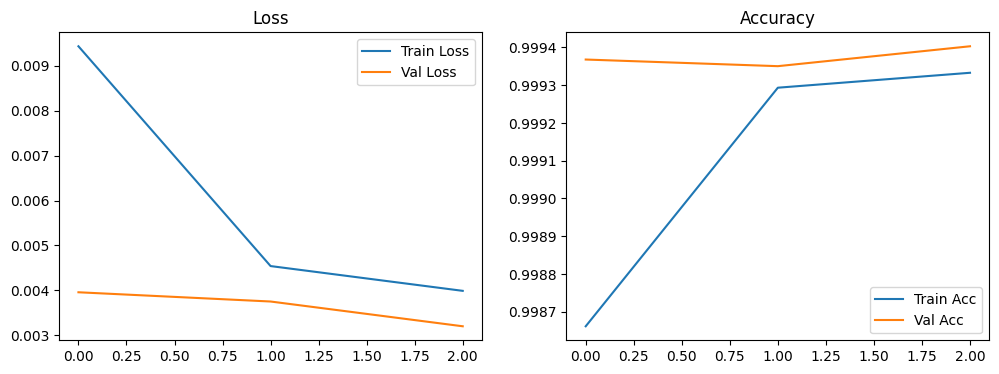

In [ ]:
import tensorflow as tf
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.metrics import Precision, Recall, AUC

# Xây dựng model
model = Sequential([
    #Input(shape = (X_train.shape[1],)),
    Input(shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')  # nhị phân
])

# Compile
model.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy', tf.keras.metrics.AUC(name='auc')]
    # Chỉ số phụ để quan sát trong quá trình huấn luyện (không ảnh hưởng đến gradient)
)

model.summary()

history = model.fit(
    X_train, y_train,
    validation_data = (X_test, y_test),
    epochs = 3,
    batch_size = 128,
    verbose = 1
)

# Vẽ loss và accuracy
plt.figure(figsize = (12,4))
plt.subplot(1,2,1)
plt.plot(
    history.history['loss'],
    label='Train Loss'
  )
plt.plot(
    history.history['val_loss'],
    label='Val Loss'
  )
plt.legend()
plt.title("Loss")

plt.subplot(1,2,2)
plt.plot(
    history.history['accuracy'],
    label='Train Acc'
  )
plt.plot(
    history.history['val_accuracy'],
    label='Val Acc'
  )
plt.legend()
plt.title("Accuracy")
plt.show()

###### 📊 Code tay

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,865 (19.00 KB)

 Trainable params: 4,865 (19.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
1781/1781 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - loss: 0.2113 - pr_auc: 0.0128 - val_loss: 0.0038 - val_pr_auc: 0.7231
Epoch 2/15
1781/1781 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0049 - pr_auc: 0.7097 - val_loss: 0.0034 - val_pr_auc: 0.7648
Epoch 3/15
1781/1781 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 0.0039 - pr_auc: 0.7624 - val_loss: 0.0032 - val_pr_auc: 0.7679
Epoch 4/15
1781/1781 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0031 - pr_auc: 0.7946 - val_loss: 0.0034 - val_pr_auc: 0.7815
Epoch 5/15
1781/1781 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 0.0035 - pr_auc: 0.7633 - val_loss: 0.0031 - val_pr_auc: 0.8400
Epoch 6/15
1781/1781 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0031 - pr_auc: 0.7488 - val_loss: 0.0029 - val_pr_auc: 0.8450
Epoch 7/15
1781/1781 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0028 - pr_auc: 0.8060 - val_loss: 0.0032 - val_pr_auc: 0.8405
Epoch 8/15
1781/1781 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0027 - pr_auc: 0.8123 - val_loss: 0.0031 - val_pr_au

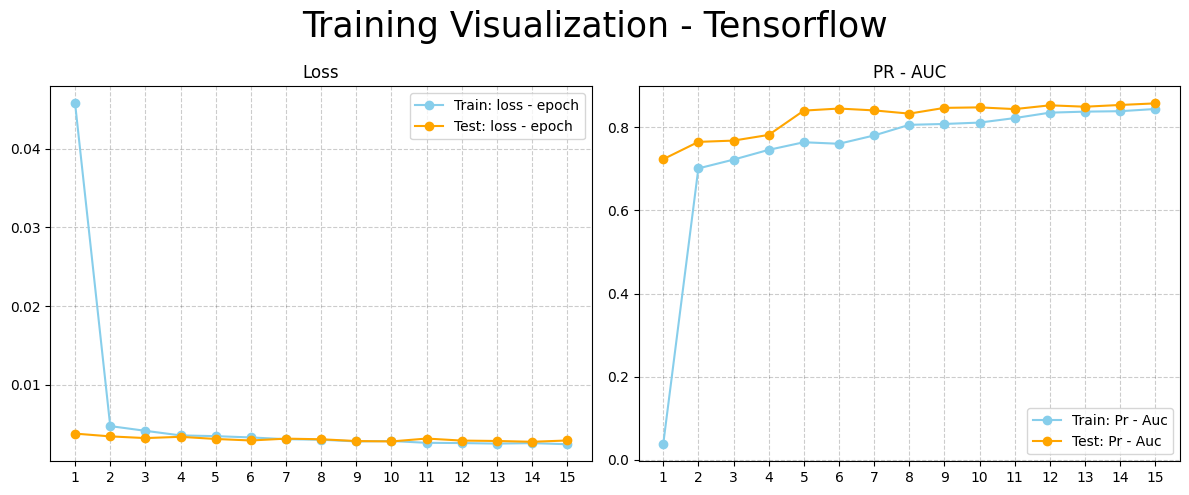

In [ ]:
import tensorflow as tf
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.metrics import AUC

# Xây dựng model - Khởi tạo mô hình MLP
model = Sequential([
    Input(shape = (X_train.shape[1], )),

    # Lớp ẩn thứ nhất
    Dense(64, activation = 'relu'),
    Dropout(0.3), # tắt 30% neuron ngẫu nhiên trong quá trình training để giảm overfitting.

    # Lớp ẩn thứ hai
    Dense(32, activation = 'relu'),
    Dropout(0.3),

    # Lớp ẩn thứ ba
    Dense(16, activation = 'relu'),

    #Lớp đầu ra
    Dense(1, activation = 'sigmoid')
])

# Compile - Thiết lập huấn luyện
model.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics =  [AUC(
        name = 'pr_auc',
        curve = 'PR'
    )] # Chỉ số phụ để quan sát trong quá trình huấn luyện (không ảnh hưởng đến gradient)
)

# Hiển thị kiến trúc mô hình: số lớp, số tham số
model.summary()

# Huấn luyện model
history = model.fit(
    X_train, y_train,
    validation_data = (X_test, y_test),
    epochs = 15,
    batch_size = 128,
    verbose = 1
)
print()

# Trực quan hóa kết quả huấn luyện
plt.figure(figsize = (12, 5))
epochs = np.arange(1, len(history.history['loss']) + 1)

# Vẽ biểu đồ bên trái: loss - epoch
plt.subplot(1, 2, 1)

# Tập train
plt.plot(
    epochs,
    history.history['loss'],
    marker = 'o',
    label = 'Train: loss - epoch',
    color = 'skyblue'
)

# Tập test
plt.plot(
    epochs,
    history.history['val_loss'],
    marker = 'o',
    label = 'Test: loss - epoch',
    color = 'orange'
)
plt.title("Loss")

plt.xticks(epochs)
plt.grid(
    linestyle = '--',
    alpha = 0.2,
    color = 'black'
)
plt.legend()

# Biểu đồ Pr_AUC - Epoch
plt.subplot(1, 2, 2)

# Tập train
plt.plot(
    epochs,
    history.history['pr_auc'],
    marker = 'o',
    color = 'skyblue',
    label = 'Train: Pr - Auc'
)

# Tập test
plt.plot(
    epochs,
    history.history['val_pr_auc'],
    marker = 'o',
    color = 'orange',
    label = 'Test: Pr - Auc'
)

plt.xticks(epochs)

plt.title("PR - AUC")
plt.legend()

plt.suptitle(
    "Training Visualization - Tensorflow",
    fontsize = 25
    )
plt.grid(
    linestyle = '--',
    alpha = 0.2,
    color = 'black'
)
plt.tight_layout()
plt.show()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 64)             │         2,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,865 (19.00 KB)

 Trainable params: 4,865 (19.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
446/446 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - loss: 0.0512 - pr_auc: 0.0280 - val_loss: 0.0044 - val_pr_auc: 0.6507
Epoch 2/20
446/446 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0053 - pr_auc: 0.6946 - val_loss: 0.0040 - val_pr_auc: 0.6933
Epoch 3/20
446/446 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0044 - pr_auc: 0.7201 - val_loss: 0.0037 - val_pr_auc: 0.7039
Epoch 4/20
446/446 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0043 - pr_auc: 0.7174 - val_loss: 0.0032 - val_pr_auc: 0.7546
Epoch 5/20
446/446 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0038 - pr_auc: 0.7198 - val_loss: 0.0032 - val_pr_auc: 0.7552
Epoch 6/20
446/446 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0034 - pr_auc: 0.7737 - val_loss: 0.0032 - val_pr_auc: 0.7938
Epoch 7/20
446/446 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0035 - pr_auc: 0.7701 - val_loss: 0.0032 - val_pr_auc: 0.7927
Epoch 8/20
446/446 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0031 - pr_auc: 0.7487 - val_loss: 0.0029 - val_pr_auc: 0.8236
Epoch 

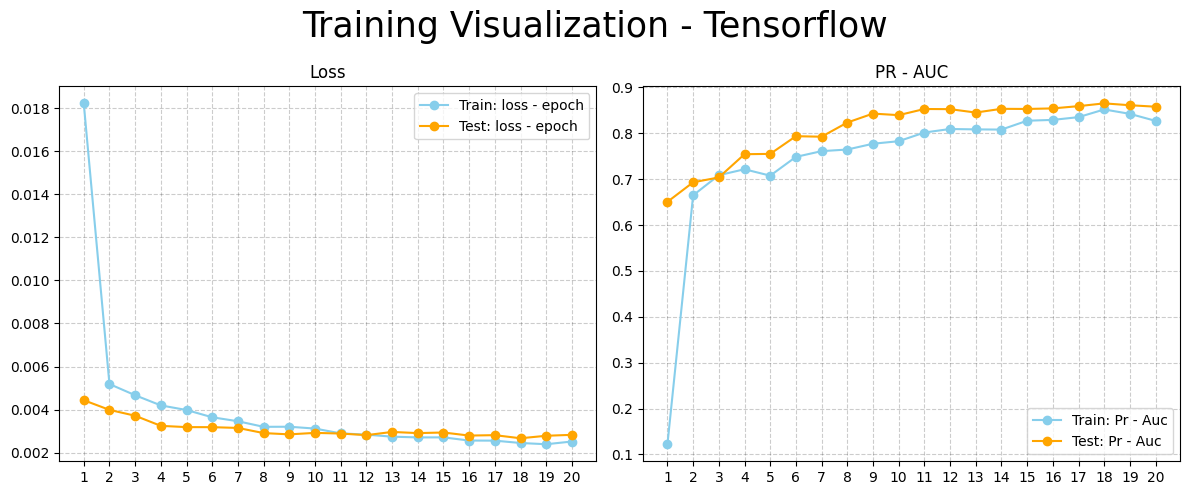

In [ ]:
import tensorflow as tf
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.metrics import AUC

# Xây dựng model - Khởi tạo mô hình MLP
model = Sequential([
    Input(shape = (X_train.shape[1], )),

    # Lớp ẩn thứ nhất
    Dense(64, activation = 'relu'),
    Dropout(0.3), # tắt 30% neuron ngẫu nhiên trong quá trình training để giảm overfitting.

    # Lớp ẩn thứ hai
    Dense(32, activation = 'relu'),
    Dropout(0.3),

    # Lớp ẩn thứ ba
    Dense(16, activation = 'relu'),

    #Lớp đầu ra
    Dense(1, activation = 'sigmoid')
])

# Compile - Thiết lập huấn luyện
model.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics =  [AUC(
        name = 'pr_auc',
        curve = 'PR'
    )] # Chỉ số phụ để quan sát trong quá trình huấn luyện (không ảnh hưởng đến gradient)
)

# Hiển thị kiến trúc mô hình: số lớp, số tham số
model.summary()

# Huấn luyện model
history = model.fit(
    X_train, y_train,
    validation_data = (X_test, y_test),
    epochs = 20,
    batch_size = 512,
    verbose = 1
)

print('='*200)
print("Trực quan hóa quá trình huấn luyện")
print('='*200)

# Trực quan hóa kết quả huấn luyện
plt.figure(figsize = (12, 5))
epochs = np.arange(1, len(history.history['loss']) + 1)

# Vẽ biểu đồ bên trái: loss - epoch
plt.subplot(1, 2, 1)

# Tập train
plt.plot(
    epochs,
    history.history['loss'],
    marker = 'o',
    label = 'Train: loss - epoch',
    color = 'skyblue'
)

# Tập test
plt.plot(
    epochs,
    history.history['val_loss'],
    marker = 'o',
    label = 'Test: loss - epoch',
    color = 'orange'
)
plt.title("Loss")

plt.xticks(epochs)
plt.grid(
    linestyle = '--',
    alpha = 0.2,
    color = 'black'
)
plt.legend()

# Biểu đồ Pr_AUC - Epoch
plt.subplot(1, 2, 2)

# Tập train
plt.plot(
    epochs,
    history.history['pr_auc'],
    marker = 'o',
    color = 'skyblue',
    label = 'Train: Pr - Auc'
)

# Tập test
plt.plot(
    epochs,
    history.history['val_pr_auc'],
    marker = 'o',
    color = 'orange',
    label = 'Test: Pr - Auc'
)

plt.xticks(epochs)

plt.title("PR - AUC")
plt.legend()

plt.suptitle(
    "Training Visualization - Tensorflow",
    fontsize = 25
    )
plt.grid(
    linestyle = '--',
    alpha = 0.2,
    color = 'black'
)
plt.tight_layout()
plt.show()

##### 🎯 Pytorch

###### 📊 Code mẫu


Epoch 1/5 - Train Loss: 0.0118, Train Acc: 0.9988 - Val Loss: 0.0035, Val Acc: 0.9993
Epoch 2/5 - Train Loss: 0.0041, Train Acc: 0.9994 - Val Loss: 0.0032, Val Acc: 0.9993
Epoch 3/5 - Train Loss: 0.0036, Train Acc: 0.9994 - Val Loss: 0.0032, Val Acc: 0.9993
Epoch 4/5 - Train Loss: 0.0035, Train Acc: 0.9994 - Val Loss: 0.0033, Val Acc: 0.9993
Epoch 5/5 - Train Loss: 0.0032, Train Acc: 0.9994 - Val Loss: 0.0030, Val Acc: 0.9993


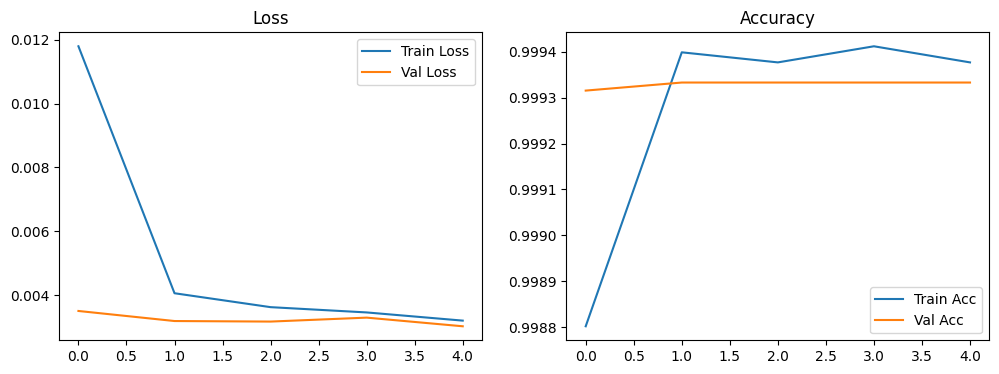

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

# Giả sử X_train, y_train, X_test, y_test đã có từ sklearn
X_train_t = torch.tensor(X_train.values, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)

X_test_t = torch.tensor(X_test.values, dtype=torch.float32)
y_test_t = torch.tensor(y_test.values, dtype=torch.float32).view(-1,1)

# Tạo Dataset và DataLoader
train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

class MLP(nn.Module):
    def __init__(self, input_dim):
        super(MLP, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()  # cho nhị phân
        )

    def forward(self, x):
        return self.layers(x)

input_dim = X_train.shape[1]
model = MLP(input_dim)

criterion = nn.BCELoss()               # binary cross entropy
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 5
train_losses, val_losses, train_accs, val_accs = [], [], [], []

for epoch in range(num_epochs):
    model.train()
    epoch_loss, correct, total = 0, 0, 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * X_batch.size(0)
        preds = (outputs >= 0.5).float()
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

    train_loss = epoch_loss / total
    train_acc = correct / total

    # Evaluation
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item() * X_batch.size(0)
            preds = (outputs >= 0.5).float()
            val_correct += (preds == y_batch).sum().item()
            val_total += y_batch.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # Lưu lại
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs} "
          f"- Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} "
          f"- Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.legend(); plt.title("Loss")

plt.subplot(1,2,2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.legend(); plt.title("Accuracy")
plt.show()


In [ ]:
type(range(5))


range

###### 📊 Code tay


Đã chuyển đổi dữ liệu Pandas -> Tensor!
----------------------------------------------------------------------------------------------------
Đã chuyển đổi Tensor Dataset và DataLoader!
----------------------------------------------------------------------------------------------------
Đã xây dựng kiến trúc mô hình MLP (Class)!
----------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------
Tiến hành huấn luyện mô hình:
- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -
Epoch 1/15 - Train Loss: 0.0128, Train PR_AUC: 0.7069 - Val Loss: 0.0035, Val PR_AUC: 0.7092
Epoch 2/15 - Train Loss: 0.0041, Train PR_AUC: 0.7356 - Val Loss: 0.0033, Val PR_AUC: 0.7241
Epoch 3/15 - Train Loss: 0.0036, Train PR_AUC: 0.7502 - Val Loss: 0.0034, Val PR_AUC: 0.7279
Epoch 4/1

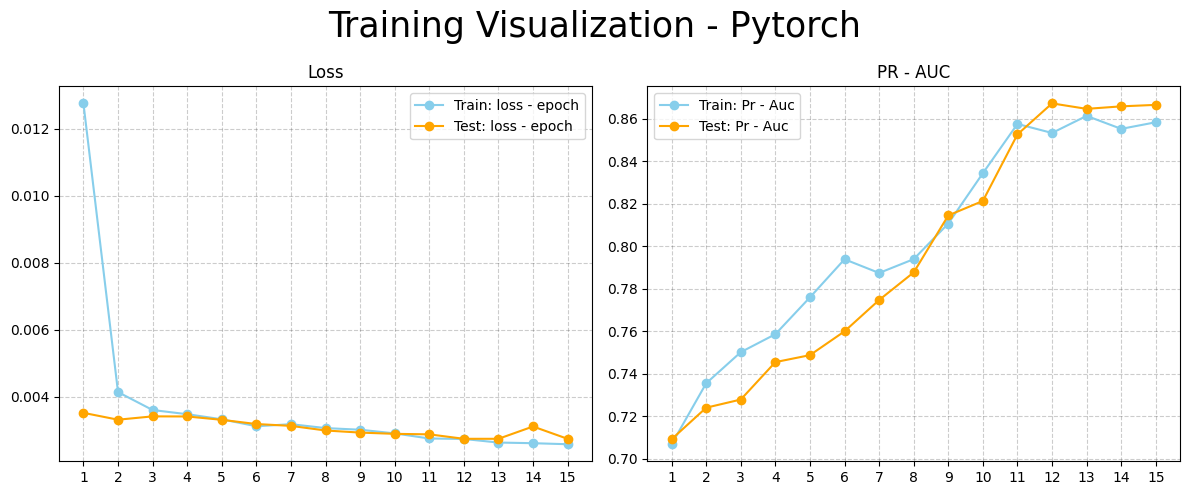

In [ ]:
# Bước 1: Import thư viện
import torch # Thư viện chính của Pytorch
import torch.nn as nn # Module chứa các thành phần xây dựng mạng (lớp, loss, activation)
import torch.optim as optim # Chứa các thuật toán tối ưu (SGD, Adam...)
from torch.utils.data import TensorDataset, DataLoader

# Bước 2: Chuyển dữ liệu từ pandas -> tensor
X_train_t = torch.tensor(
    X_train.values, # Lấy mảng trong DataFrame X_train
    dtype = torch.float32
)
y_train_t = torch.tensor(
    y_train.values,
    dtype = torch.float32
).view(-1, 1)

X_test_t = torch.tensor(
    X_test.values,
    dtype = torch.float32
)

y_test_t = torch.tensor(
    y_test.values,
    dtype = torch.float32
).view(-1, 1)

print("Đã chuyển đổi dữ liệu Pandas -> Tensor!")
print('-'*100)

# Bước 3: Tạo Dataset và Dataloader
train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(
    train_dataset,
    batch_size = 128,
    shuffle = True
  )

test_loader = DataLoader(
    test_dataset,
    batch_size = 128,
    shuffle = False
)

print('Đã chuyển đổi Tensor Dataset và DataLoader!')
print('-'*100)

# Bước 4: Xây dựng kiến trúc mô hình MLP
class MLP(nn.Module):
    def __init__(self, input_dim):
        super(MLP, self).__init__()
        self.layers = nn.Sequential(
            # Lớp ẩn thứ nhất
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),

            # Lớp ẩn thứ hai
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),

            # Lớp ẩn thứ ba
            nn.Linear(32, 16),
            nn.ReLU(),

            # Lớp output
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.layers(x)

print('Đã xây dựng kiến trúc mô hình MLP (Class)!')
print('-'*100)

# Bước 5: Khởi tạo model, loss, optimizer
input_dim = X_train.shape[1]
model = MLP(input_dim) # Khởi tạo mô hình MLP

criterion = nn.BCELoss() # binary cross entropy
optimizer = optim.Adam( # sử dụng thuật toán tối ưu hóa Adam
    model.parameters(), # Lấy trọng số và bias của từng layer
    lr = 0.001
)

# Hàm tính chỉ số phụ
def calculate_metric_(model, data_loader):
    from sklearn.metrics import precision_recall_curve, auc
    all_preds, all_labels = [], []

    # Tính y_probs, lấy y_true
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            outputs = model(X_batch) # Lấy xác suất dự đoán
            all_preds.extend(outputs.numpy().flatten()) # y_pred
            all_labels.extend(y_batch.numpy().flatten()) # y_true

    # Tính pr_auc
    precision, recall, _ = precision_recall_curve(all_labels, all_preds)
    pr_auc = auc(recall, precision)

    return pr_auc

# Bước 6: Huấn luyện mô hình
num_epochs = 15 # Tổng số vòng lặp huấn luyện
train_losses, val_losses = [], [] # Lưu lại loss
train_pr_auc_, val_pr_auc_ = [], [] # Lưu lại PR AUC

print('-'*100)
print("Tiến hành huấn luyện mô hình:")
print('- -'*50)
for epoch in range(num_epochs):
    # Bước 6.1: Training - Huấn luyện
    model.train() # Bật chế độ huấn luyện (dropout hoạt động)
    train_loss, correct, train_total = 0, 0, 0

    # Huấn luyện qua từng batch
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad() # Reset Gradient qua từng Batch
        outputs = model(X_batch) # Lan truyền xuôi, tính y_prob
        loss = criterion(outputs, y_batch) # Tính Loss
        loss.backward()
        optimizer.step()

        # Tính tổng loss trong từng batch
        train_loss += loss.item() * X_batch.size(0)

        # Lấy y_pred, ngưỡng 0.5
        preds = (outputs >= 0.5).float()
        correct += (preds == y_batch).sum().item()

        #.sum() trả về một tensor chứa một số duy nhất, ví dụ: tensor(2).
        #.item() biến nó thành giá trị Python scalar (int/float), để có thể cộng dồn hoặc in ra dễ dàng.

        # Tính tổng số mẫu huấn luyện
        train_total += y_batch.size(0) # tensor.size(dim)

    train_loss = train_loss / train_total
    train_pr_auc = calculate_metric_(model, train_loader)

    # Bước 6.2: Evaluation - Đánh giá
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            val_outputs = model(X_batch)
            loss = criterion(val_outputs, y_batch)
            val_loss += loss.item() * X_batch.size(0)
            preds = (val_outputs >= 0.5).float()

            val_correct += (preds == y_batch).sum().item()
            val_total += y_batch.size(0)

    val_loss = val_loss / val_total
    val_pr_auc = calculate_metric_(model, test_loader)

    # Lưu lại
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_pr_auc_.append(train_pr_auc)
    val_pr_auc_.append(val_pr_auc)

    # In kết quả huấn luyện
    print(
        f"Epoch {epoch + 1}/{num_epochs} "
        f"- Train Loss: {train_loss:.4f}, Train PR_AUC: {train_pr_auc:.4f} "
        f"- Val Loss: {val_loss:.4f}, Val PR_AUC: {val_pr_auc:.4f}"
    )

# Trực quan hóa quá trình huấn luyện
plt.figure(figsize = (12, 5))

# Vẽ biểu đồ bên trái: loss - epoch
plt.subplot(1, 2, 1)

epochs = np.arange(1, num_epochs + 1)
# Tập train
plt.plot(
    epochs,
    train_losses,
    marker = 'o',
    label = 'Train: loss - epoch',
    color = 'skyblue'
)

# Tập test
plt.plot(
    epochs,
    val_losses,
    marker = 'o',
    label = 'Test: loss - epoch',
    color = 'orange'
)
plt.title("Loss")

plt.xticks(epochs)
plt.grid(
    linestyle = '--',
    alpha = 0.2,
    color = 'black'
)
plt.legend()

# Biểu đồ Pr_AUC - Epoch
plt.subplot(1, 2, 2)

# Tập train
plt.plot(
    epochs,
    train_pr_auc_,
    marker = 'o',
    color = 'skyblue',
    label = 'Train: Pr - Auc'
)

# Tập test
plt.plot(
    epochs,
    val_pr_auc_,
    marker = 'o',
    color = 'orange',
    label = 'Test: Pr - Auc'
)

plt.xticks(epochs)

plt.title("PR - AUC")
plt.legend()

plt.suptitle(
    "Training Visualization - Pytorch",
    fontsize = 25
    )
plt.grid(
    linestyle = '--',
    alpha = 0.2,
    color = 'black'
)
plt.tight_layout()
plt.show()


#### Hàm train model - Pytorch

In [ ]:
def train_model(X_train, X_test, y_test, y_train, model = 'Pytorch', num_epochs = 15,threshold = 0.5, verbose = True, Vis = False):
    # Bước 1: Import thư viện
    import torch # Thư viện chính của Pytorch
    import torch.nn as nn # Module chứa các thành phần xây dựng mạng (lớp, loss, activation)
    import torch.optim as optim # Chứa các thuật toán tối ưu (SGD, Adam...)
    from torch.utils.data import TensorDataset, DataLoader

    # Bước 2: Chuyển dữ liệu từ pandas -> tensor
    X_train_t = torch.tensor(
        X_train.values, # Lấy mảng trong DataFrame X_train
        dtype = torch.float32
    )
    y_train_t = torch.tensor(
        y_train.values,
        dtype = torch.float32
    ).view(-1, 1)

    X_test_t = torch.tensor(
        X_test.values,
        dtype = torch.float32
    )

    y_test_t = torch.tensor(
        y_test.values,
        dtype = torch.float32
    ).view(-1, 1)

    print("Đã chuyển đổi dữ liệu Pandas -> Tensor!")
    print('-'*100)

    # Bước 3: Tạo Dataset và Dataloader
    train_dataset = TensorDataset(X_train_t, y_train_t)
    test_dataset = TensorDataset(X_test_t, y_test_t)

    train_loader = DataLoader(
        train_dataset,
        batch_size = 128,
        shuffle = True
      )

    test_loader = DataLoader(
        test_dataset,
        batch_size = 128,
        shuffle = False
    )

    print('Đã chuyển đổi Tensor Dataset và DataLoader!')
    print('-'*100)

    # Bước 4: Xây dựng kiến trúc mô hình MLP
    class MLP(nn.Module):
        def __init__(self, input_dim):
            super(MLP, self).__init__()
            self.layers = nn.Sequential(
                # Lớp ẩn thứ nhất
                nn.Linear(input_dim, 64),
                nn.ReLU(),
                nn.Dropout(0.3),

                # Lớp ẩn thứ hai
                nn.Linear(64, 32),
                nn.ReLU(),
                nn.Dropout(0.3),

                # Lớp ẩn thứ ba
                nn.Linear(32, 16),
                nn.ReLU(),

                # Lớp output
                nn.Linear(16, 1),
                nn.Sigmoid()
            )

        def forward(self, x):
            return self.layers(x)

    print('Đã xây dựng kiến trúc mô hình MLP (Class)!')
    print('-'*100)

    # Bước 5: Khởi tạo model, loss, optimizer
    input_dim = X_train.shape[1]
    model = MLP(input_dim) # Khởi tạo mô hình MLP

    # device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    # model = MLP(input_dim).to(device) # Khởi tạo mô hình MLP

    criterion = nn.BCELoss() # binary cross entropy
    optimizer = optim.Adam( # sử dụng thuật toán tối ưu hóa Adam
        model.parameters(), # Lấy trọng số và bias của từng layer
        lr = 0.001
    )

    # Hàm tính chỉ số phụ
    def calculate_metric_(model, data_loader):
        from sklearn.metrics import precision_recall_curve, auc
        all_preds, all_labels = [], []

        # Tính y_probs, lấy y_true
        with torch.no_grad():
            for X_batch, y_batch in data_loader:
                outputs = model(X_batch) # Lấy xác suất dự đoán
                all_preds.extend(outputs.numpy().flatten()) # y_pred
                all_labels.extend(y_batch.numpy().flatten()) # y_true

        # Tính pr_auc
        precision, recall, _ = precision_recall_curve(all_labels, all_preds)
        pr_auc = auc(recall, precision)

        return pr_auc

    # Bước 6: Huấn luyện mô hình
    num_epochs = num_epochs # Tổng số vòng lặp huấn luyện
    train_losses, val_losses = [], [] # Lưu lại loss
    train_pr_auc_, val_pr_auc_ = [], [] # Lưu lại PR AUC

    print('-'*100)
    print("Tiến hành huấn luyện mô hình:")
    print('- -'*50)
    for epoch in range(num_epochs):
        # Bước 6.1: Training - Huấn luyện
        model.train() # Bật chế độ huấn luyện (dropout hoạt động)
        train_loss, correct, train_total = 0, 0, 0

        # Huấn luyện qua từng batch
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad() # Reset Gradient qua từng Batch
            train_outputs = model(X_batch) # Lan truyền xuôi, tính y_prob
            loss = criterion(train_outputs, y_batch) # Tính Loss
            loss.backward()
            optimizer.step()

            # Tính tổng loss trong từng batch
            train_loss += loss.item() * X_batch.size(0)

            # Lấy y_pred, ngưỡng 0.5
            train_preds = (train_outputs >= threshold).float()
            correct += (train_preds == y_batch).sum().item()

            #.sum() trả về một tensor chứa một số duy nhất, ví dụ: tensor(2).
            #.item() biến nó thành giá trị Python scalar (int/float), để có thể cộng dồn hoặc in ra dễ dàng.

            # Tính tổng số mẫu huấn luyện
            train_total += y_batch.size(0) # tensor.size(dim)

        train_loss = train_loss / train_total
        train_pr_auc = calculate_metric_(model, train_loader)

        # Bước 6.2: Evaluation - Đánh giá
        model.eval()
        y_prob, y_pred = [], []
        val_loss, val_correct, val_total = 0, 0, 0

        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                val_outputs = model(X_batch)
                loss = criterion(val_outputs, y_batch)
                val_loss += loss.item() * X_batch.size(0)
                val_preds = (val_outputs >= threshold).float()

                val_correct += (val_preds == y_batch).sum().item()
                val_total += y_batch.size(0)

                y_prob.extend(val_outputs.numpy().flatten()) # y_pred
                y_pred.extend(val_preds.numpy().flatten())

        val_loss = val_loss / val_total
        val_pr_auc = calculate_metric_(model, test_loader)

        # Lưu lại
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_pr_auc_.append(train_pr_auc)
        val_pr_auc_.append(val_pr_auc)

        if verbose:
            # In kết quả huấn luyện
            print(
                f"Epoch {epoch + 1}/{num_epochs} "
                f"- Train Loss: {train_loss:.4f}, Train PR_AUC: {train_pr_auc:.4f} "
                f"- Val Loss: {val_loss:.4f}, Val PR_AUC: {val_pr_auc:.4f}"
            )

    if Vis:
        # Trực quan hóa quá trình huấn luyện
        plt.figure(figsize = (12, 5))

        # Vẽ biểu đồ bên trái: loss - epoch
        plt.subplot(1, 2, 1)

        epochs = np.arange(1, num_epochs + 1)
        # Tập train
        plt.plot(
            epochs,
            train_losses,
            marker = 'o',
            label = 'Train: loss - epoch',
            color = 'skyblue'
        )

        # Tập test
        plt.plot(
            epochs,
            val_losses,
            marker = 'o',
            label = 'Test: loss - epoch',
            color = 'orange'
        )
        plt.title("Loss")

        plt.xticks(epochs)
        plt.grid(
            linestyle = '--',
            alpha = 0.2,
            color = 'black'
        )
        plt.legend()

        # Biểu đồ Pr_AUC - Epoch
        plt.subplot(1, 2, 2)

        # Tập train
        plt.plot(
            epochs,
            train_pr_auc_,
            marker = 'o',
            color = 'skyblue',
            label = 'Train: Pr - Auc'
        )

        # Tập test
        plt.plot(
            epochs,
            val_pr_auc_,
            marker = 'o',
            color = 'orange',
            label = 'Test: Pr - Auc'
        )

        plt.xticks(epochs)

        plt.title("PR - AUC")
        plt.legend()

        plt.suptitle(
            "Training Visualization - Pytorch",
            fontsize = 25
            )
        plt.grid(
            linestyle = '--',
            alpha = 0.2,
            color = 'black'
        )
        plt.tight_layout()
        plt.show()
        plt.close()
    return y_prob, y_pred


In [ ]:
y_prob, y_pred = train_model(X_train, X_test, y_test, y_train, model = 'Pytorch', num_epochs = 3, threshold = 0.5, verbose = True, Vis = False)


Đã chuyển đổi dữ liệu Pandas -> Tensor!
----------------------------------------------------------------------------------------------------
Đã chuyển đổi Tensor Dataset và DataLoader!
----------------------------------------------------------------------------------------------------
Đã xây dựng kiến trúc mô hình MLP (Class)!
----------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------
Tiến hành huấn luyện mô hình:
- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -
Epoch 1/3 - Train Loss: 0.0140, Train PR_AUC: 0.7298 - Val Loss: 0.0034, Val PR_AUC: 0.7236
Epoch 2/3 - Train Loss: 0.0039, Train PR_AUC: 0.7550 - Val Loss: 0.0036, Val PR_AUC: 0.7177
Epoch 3/3 - Train Loss: 0.0036, Train PR_AUC: 0.7699 - Val Loss: 0.0035, Val PR_AUC: 0.7526


##### Xử lý GPU - CPU Pytorch

In [ ]:
def train_model(X_train, X_test, y_train, y_test, model = 'Pytorch', num_epochs = 15,threshold = 0.5, verbose = True, Vis = False):
    # Bước 1: Import thư viện
    import torch # Thư viện chính của Pytorch
    import torch.nn as nn # Module chứa các thành phần xây dựng mạng (lớp, loss, activation)
    import torch.optim as optim # Chứa các thuật toán tối ưu (SGD, Adam...)
    from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Bước 2: Chuyển dữ liệu từ pandas -> tensor
    X_train_t = torch.tensor(
        X_train.values, # Lấy mảng trong DataFrame X_train
        dtype = torch.float32
    ).to(device)

    y_train_t = torch.tensor(
        y_train.values,
        dtype = torch.float32
    ).view(-1, 1).to(device)

    X_test_t = torch.tensor(
        X_test.values,
        dtype = torch.float32
    ).to(device)

    y_test_t = torch.tensor(
        y_test.values,
        dtype = torch.float32
    ).view(-1, 1).to(device)

    print("Đã chuyển đổi dữ liệu Pandas -> Tensor!")
    print('-'*100)

    # # Tính sampler
    # labels = torch.tensor(
    #     y_train.values,
    #     dtype = torch.long
    # )
    # class_sample_count = torch.bincount(labels) # Đếm số lượng xuất hiện từng nhãn trong labels

    # weights = 1. / class_sample_count.float()

    # sample_weights = weights[labels]

    # sampler = WeightedRandomSampler(
    #     sample_weights,
    #     num_samples = len(sample_weights),
    #     replacement = False
    # )

    # Bước 3: Tạo Dataset và Dataloader
    train_dataset = TensorDataset(X_train_t, y_train_t)
    test_dataset = TensorDataset(X_test_t, y_test_t)

    train_loader = DataLoader(
        train_dataset,
        batch_size = 512,
        # sampler = sampler
        shuffle = True
      )

    test_loader = DataLoader(
        test_dataset,
        batch_size = 512,
        shuffle = False,
    )

    print('Đã chuyển đổi Tensor Dataset và DataLoader!')
    print('-'*100)

    # Bước 4: Xây dựng kiến trúc mô hình MLP
    class MLP(nn.Module):
        def __init__(self, input_dim):
            super(MLP, self).__init__()
            self.layers = nn.Sequential(
                # Lớp ẩn thứ nhất
                nn.Linear(input_dim, 64),
                nn.ReLU(),
                nn.Dropout(0.3),

                # Lớp ẩn thứ hai
                nn.Linear(64, 32),
                nn.ReLU(),
                nn.Dropout(0.3),

                # Lớp ẩn thứ ba
                nn.Linear(32, 16),
                nn.ReLU(),

                # Lớp output
                nn.Linear(16, 1),
                nn.Sigmoid()
            )

        def forward(self, x):
            return self.layers(x)

    print('Đã xây dựng kiến trúc mô hình MLP (Class)!')
    print('-'*100)

    # Bước 5: Khởi tạo model, loss, optimizer
    input_dim = X_train.shape[1]
    model = MLP(input_dim).to(device) # Khởi tạo mô hình MLP

    # device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    # model = MLP(input_dim).to(device) # Khởi tạo mô hình MLP

    criterion = nn.BCELoss() # binary cross entropy
    optimizer = optim.Adam( # sử dụng thuật toán tối ưu hóa Adam
        model.parameters(), # Lấy trọng số và bias của từng layer
        lr = 0.001
    )

    # Hàm tính chỉ số phụ
    def calculate_metric_(model, data_loader):
        from sklearn.metrics import precision_recall_curve, auc
        all_preds, all_labels = [], []

        # Tính y_probs, lấy y_true
        with torch.no_grad():
            for X_batch, y_batch in data_loader:
                #X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch) # Lấy xác suất dự đoán
                all_preds.extend(outputs.detach().cpu().numpy().flatten()) # y_pred
                all_labels.extend(y_batch.detach().cpu().numpy().flatten()) # y_true

        # Tính pr_auc
        precision, recall, _ = precision_recall_curve(all_labels, all_preds)
        pr_auc = auc(recall, precision)

        return pr_auc

    # Bước 6: Huấn luyện mô hình
    num_epochs = num_epochs # Tổng số vòng lặp huấn luyện
    train_losses, val_losses = [], [] # Lưu lại loss
    train_pr_auc_, val_pr_auc_ = [], [] # Lưu lại PR AUC

    print('-'*100)
    print("Tiến hành huấn luyện mô hình:")
    print('- -'*50)
    for epoch in range(num_epochs):
        # Bước 6.1: Training - Huấn luyện
        model.train() # Bật chế độ huấn luyện (dropout hoạt động)
        train_loss, correct, train_total = 0, 0, 0

        # Huấn luyện qua từng batch
        for X_batch, y_batch in train_loader:

           # X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad() # Reset Gradient qua từng Batch
            train_outputs = model(X_batch) # Lan truyền xuôi, tính y_prob
            loss = criterion(train_outputs, y_batch) # Tính Loss
            loss.backward()
            optimizer.step()

            # Tính tổng loss trong từng batch
            train_loss += loss.item() * X_batch.size(0)

            # Lấy y_pred, ngưỡng 0.5
            train_preds = (train_outputs >= threshold).float()
            correct += (train_preds == y_batch).sum().item()

            #.sum() trả về một tensor chứa một số duy nhất, ví dụ: tensor(2).
            #.item() biến nó thành giá trị Python scalar (int/float), để có thể cộng dồn hoặc in ra dễ dàng.

            # Tính tổng số mẫu huấn luyện
            train_total += y_batch.size(0) # tensor.size(dim)

        train_loss = train_loss / train_total
        train_pr_auc = calculate_metric_(model, train_loader)

        # Bước 6.2: Evaluation - Đánh giá
        model.eval()
        y_prob, y_pred = [], []
        val_loss, val_correct, val_total = 0, 0, 0

        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                #X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                val_outputs = model(X_batch)
                loss = criterion(val_outputs, y_batch)
                val_loss += loss.item() * X_batch.size(0)
                val_preds = (val_outputs >= threshold).float()

                val_correct += (val_preds == y_batch).sum().item()
                val_total += y_batch.size(0)

                y_prob.extend(val_outputs.detach().cpu().numpy().flatten()) # y_pred
                y_pred.extend(val_preds.detach().cpu().numpy().flatten())

        val_loss = val_loss / val_total
        val_pr_auc = calculate_metric_(model, test_loader)

        # Lưu lại
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_pr_auc_.append(train_pr_auc)
        val_pr_auc_.append(val_pr_auc)

        if verbose:
            # In kết quả huấn luyện
            print(
                f"Epoch {epoch + 1}/{num_epochs} "
                f"- Train Loss: {train_loss:.4f}, Train PR_AUC: {train_pr_auc:.4f} "
                f"- Val Loss: {val_loss:.4f}, Val PR_AUC: {val_pr_auc:.4f}"
            )

    if Vis:
        print('='*200)
        print("Trực quan hóa quá trình huấn luyện")
        print('='*200)
        # Trực quan hóa quá trình huấn luyện
        plt.figure(figsize = (12, 5))

        # Vẽ biểu đồ bên trái: loss - epoch
        plt.subplot(1, 2, 1)

        epochs = np.arange(1, num_epochs + 1)
        # Tập train
        plt.plot(
            epochs,
            train_losses,
            marker = 'o',
            label = 'Train: loss - epoch',
            color = 'skyblue'
        )

        # Tập test
        plt.plot(
            epochs,
            val_losses,
            marker = 'o',
            label = 'Test: loss - epoch',
            color = 'orange'
        )
        plt.title("Loss")

        plt.xticks(epochs)
        plt.grid(
            linestyle = '--',
            alpha = 0.2,
            color = 'black'
        )
        plt.legend()

        # Biểu đồ Pr_AUC - Epoch
        plt.subplot(1, 2, 2)

        # Tập train
        plt.plot(
            epochs,
            train_pr_auc_,
            marker = 'o',
            color = 'skyblue',
            label = 'Train: Pr - Auc'
        )

        # Tập test
        plt.plot(
            epochs,
            val_pr_auc_,
            marker = 'o',
            color = 'orange',
            label = 'Test: Pr - Auc'
        )

        plt.xticks(epochs)

        plt.title("PR - AUC")
        plt.legend()

        plt.suptitle(
            "Training Visualization - Pytorch",
            fontsize = 25
            )
        plt.grid(
            linestyle = '--',
            alpha = 0.2,
            color = 'black'
        )
        plt.tight_layout()
        plt.show()
        plt.close()
    return y_prob, y_pred


In [ ]:
y_prob, y_pred = train_model(X_train, X_test, y_test, y_train, model = 'Pytorch', num_epochs = 20, threshold = 0.5, verbose = True, Vis = False)


Đã chuyển đổi dữ liệu Pandas -> Tensor!
----------------------------------------------------------------------------------------------------
Đã chuyển đổi Tensor Dataset và DataLoader!
----------------------------------------------------------------------------------------------------
Đã xây dựng kiến trúc mô hình MLP (Class)!
----------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------
Tiến hành huấn luyện mô hình:
- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -


KeyboardInterrupt: 

### 👉 Hàm đánh giá và trực quan hóa

In [ ]:
def eva_and_viz_model(X_test, y_test, y_pred, y_prob, name_pp, show = False):
    print("Tiến hành đánh giá mô hình: ")
    print('-'*200)

    acr = accuracy_score(y_test, y_pred)
    print('Độ chính xác mô hình là: ', acr)
    print("-"*200)

    # Tính Ma trận nhầm lẫn
    c_matrix = confusion_matrix(y_test, y_pred)
    print('Đã tính Ma trận nhầm lẫn! ')
    print('-'*200)

    # Tính Classification_report
    cf_report = classification_report(y_test, y_pred, output_dict = True)
    df_report = pd.DataFrame(cf_report).transpose()
    print('Đã tính Classification Report! ')
    print('-'*200)

    # Tính ROC - AUC:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    print('Đã tính ROC-AUC!')
    print('-'*200)

    # Tính PR - AUC
    precison, recall, _ = precision_recall_curve(y_test, y_prob) # output: precision, recall, thresholds
    pr_auc = auc(recall, precison)
    print('Đã tính PR-AUC!')
    print('-'*200)

    # Trực quan hóa
    if show:
        fig, axs = plt.subplots(
            nrows = 2,
            ncols = 2,
            sharex = False,
            sharey = False,
            squeeze = False,
            figsize = (12,6)
        )

        #Trực quan hóa Confusion Matrix
        sns.heatmap(
            c_matrix,
            annot = True,
            cmap = 'coolwarm',
            linecolor = 'black',
            linewidth = 0.5,
            ax = axs[0,0]
          )
        axs[0,0].set_title("Ma trận nhầm lẫn", fontsize = 16, color = 'red')
        axs[0,0].set_xlabel('Dự đoán')
        axs[0,0].set_ylabel('Thực tế')

        # Trực quan hóa Classification Report
        sns.heatmap(
            df_report,
            annot = True,
            cmap = 'coolwarm',
            linecolor = 'black',
            linewidth = 0.5,
            ax = axs[0,1]
          )
        axs[0,1].set_title("Classification Report", fontsize = 16, color = 'red')
        axs[0,1].set_xlabel('Dự đoán')
        axs[0,1].set_ylabel('Thực tế')

        # Trực quan hóa ROC - AUC
        axs[1,0].plot(
            fpr,
            tpr,
            label = "ROC Curve",
            color = 'green',
            linewidth = 2
            )

        axs[1,0].set_title("ROC CURVE", fontsize = 16, color = 'red')
        axs[1,0].set_xlabel('FPR')
        axs[1,0].set_ylabel('TPR')
        axs[1,0].grid()
        axs[1,0].legend(loc = 'lower right')

        # Trực quan hóa PR - AUC
        axs[1,1].plot(
            precison,
            recall,
            label = 'PR Curve',
            color = 'blue',
            linewidth = 2
            )

        axs[1,1].set_title("PR CURVE", fontsize = 16, color = 'red')
        axs[1,1].set_xlabel('Precison')
        axs[1,1].set_ylabel('Recall')
        axs[1,1].grid()
        axs[1,1].legend(loc = 'lower left')


        fig.suptitle(f"TRỰC QUAN HÓA - {name_pp.upper()}", fontsize = 20, color = 'red')

        plt.tight_layout()
        plt.show()

    return {
        'solu' : name_pp,
        'roc_auc' : roc_auc,
        'pr_auc' : pr_auc
    }


### 👉 Hàm huấn luyện và đánh giá


#### Mô hình Random Forest

HUẤN LUYỆN VỚI PHƯƠNG PHÁP XỬ LÝ DỮ LIỆU: ORIGINAL
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Tiến hành đánh giá mô hình: 
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Độ chính xác mô hình là:  0.9995435553526912
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Đã tính Ma trận nhầm lẫn! 
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Đã tính Classification Report! 
------------

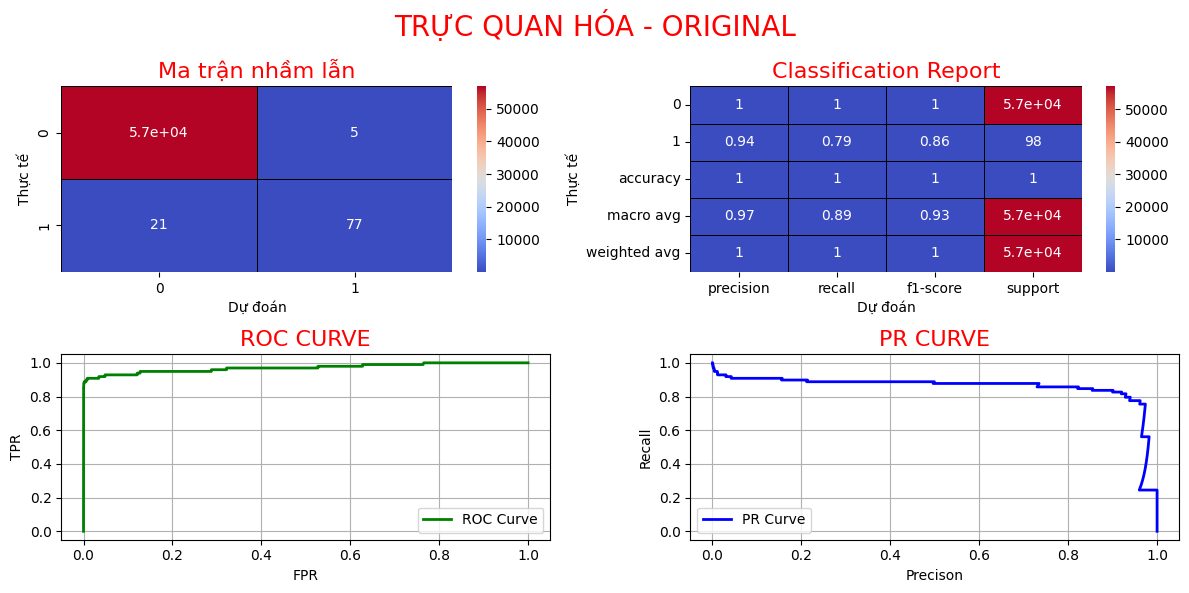


HUẤN LUYỆN VỚI PHƯƠNG PHÁP XỬ LÝ DỮ LIỆU: UNDERSAMPLING
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Tiến hành đánh giá mô hình: 
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Độ chính xác mô hình là:  0.9986657771847899
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Đã tính Ma trận nhầm lẫn! 
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Đã tính Classification Report! 
------

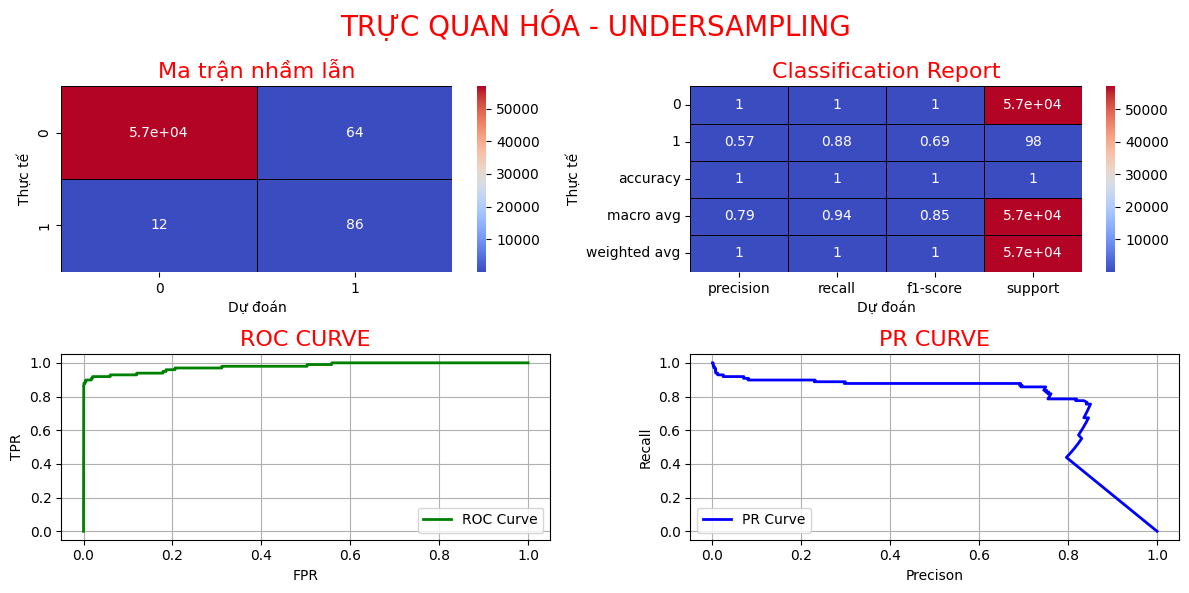


HUẤN LUYỆN VỚI PHƯƠNG PHÁP XỬ LÝ DỮ LIỆU: SMOTE
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Tiến hành đánh giá mô hình: 
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Độ chính xác mô hình là:  0.9992626663389628
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Đã tính Ma trận nhầm lẫn! 
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Đã tính Classification Report! 
--------------

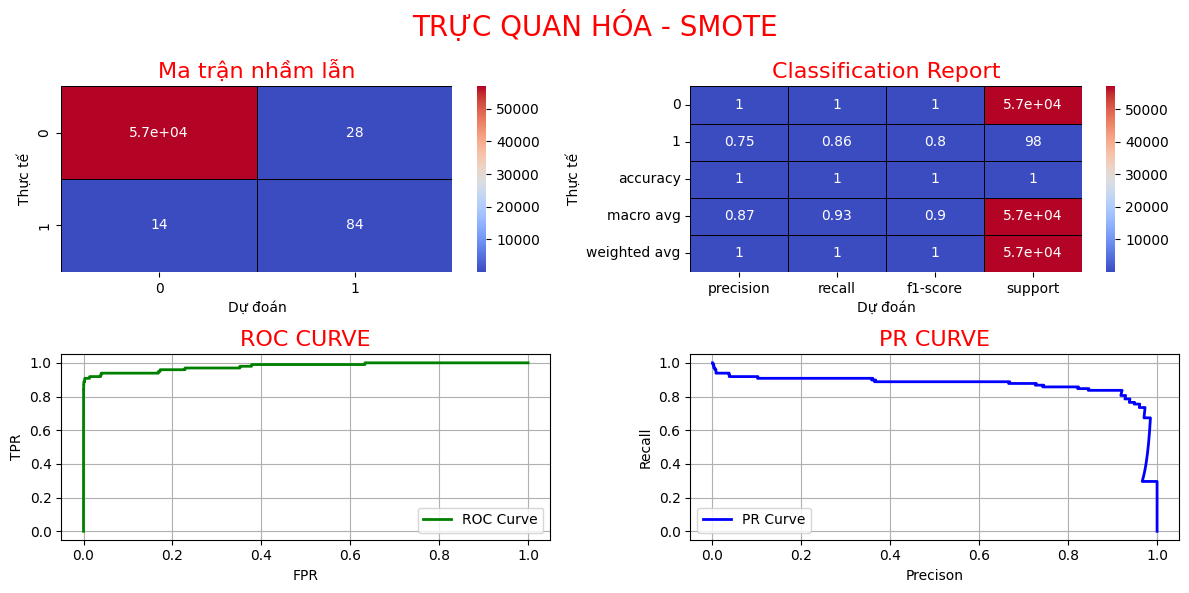


HUẤN LUYỆN VỚI PHƯƠNG PHÁP XỬ LÝ DỮ LIỆU: COMBINED
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Tiến hành đánh giá mô hình: 
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Độ chính xác mô hình là:  0.9982268881008391
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Đã tính Ma trận nhầm lẫn! 
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Đã tính Classification Report! 
-----------

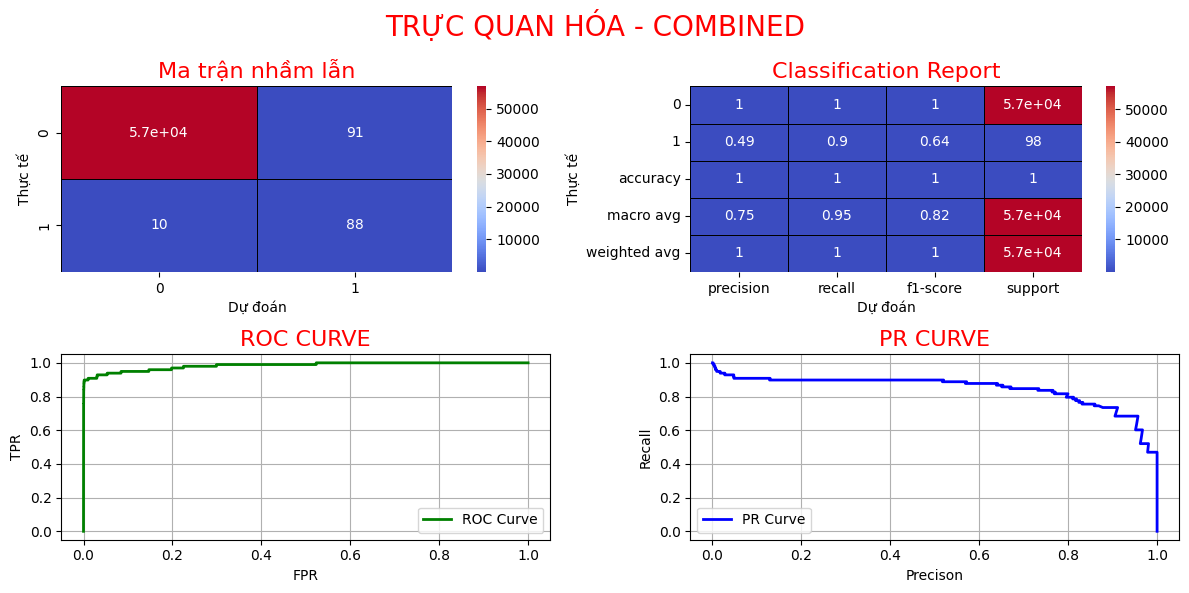

In [ ]:
# Thực hành Huấn luyện và đánh giá mô hình
def train_and_evaluate_model(model, resampled_data, X_test, y_test):
    # Danh sách các phương pháp xử lý mất cân bằng
    resampling_methods = ['original', 'undersampling', 'smote', 'combined']

    # Lưu trữ kết quả
    results = []

    # Huấn luyện và đánh giá mô hình
    for method in resampling_methods:
        print("HUẤN LUYỆN VỚI PHƯƠNG PHÁP XỬ LÝ DỮ LIỆU:", method.upper())
        print("-"*200)

        X_train_resampled, y_train_resampled = resampled_data[method]

        # Huấn luyện mô hình
        model.fit(X_train_resampled, y_train_resampled)

        # Dự đoán
        y_pred = model.predict(X_test)

        # Tính Predict_Proba
        y_prob = model.predict_proba(X_test)[:, 1]

        # Đánh giá mô hình:
        result = eva_and_viz_model(model, X_test, y_test, y_pred, y_prob, method, show = True)
        results.append(result)
        print('='*200)
        print()

    return results

results_rf = train_and_evaluate_model(rf_model, resampled_data, X_test, y_test)

#### Mô hình MLP - Pytorch

HUẤN LUYỆN VỚI PHƯƠNG PHÁP XỬ LÝ DỮ LIỆU: ORIGINAL
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Đã chuyển đổi dữ liệu Pandas -> Tensor!
----------------------------------------------------------------------------------------------------
Đã chuyển đổi Tensor Dataset và DataLoader!
----------------------------------------------------------------------------------------------------
Đã xây dựng kiến trúc mô hình MLP (Class)!
----------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------
Tiến hành huấn luyện mô hình:
- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -
Epoch 1/15 - Train Loss: 0.0476, Tra

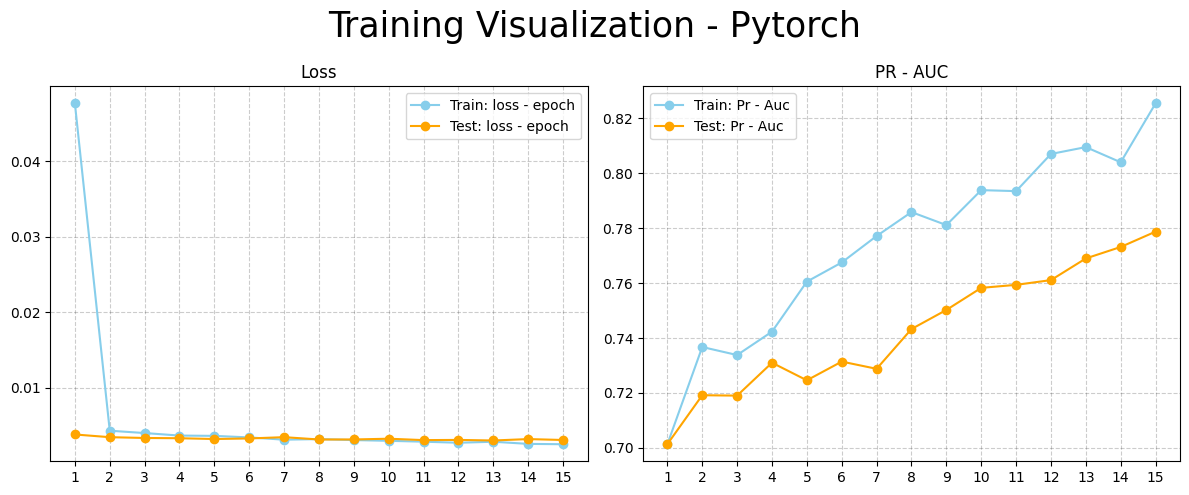

Trực quan hóa kết quả huấn luyện
Tiến hành đánh giá mô hình: 
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Độ chính xác mô hình là:  0.9993504441557529
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Đã tính Ma trận nhầm lẫn! 
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Đã tính Classification Report! 
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Đã tính ROC-AUC!
-------------

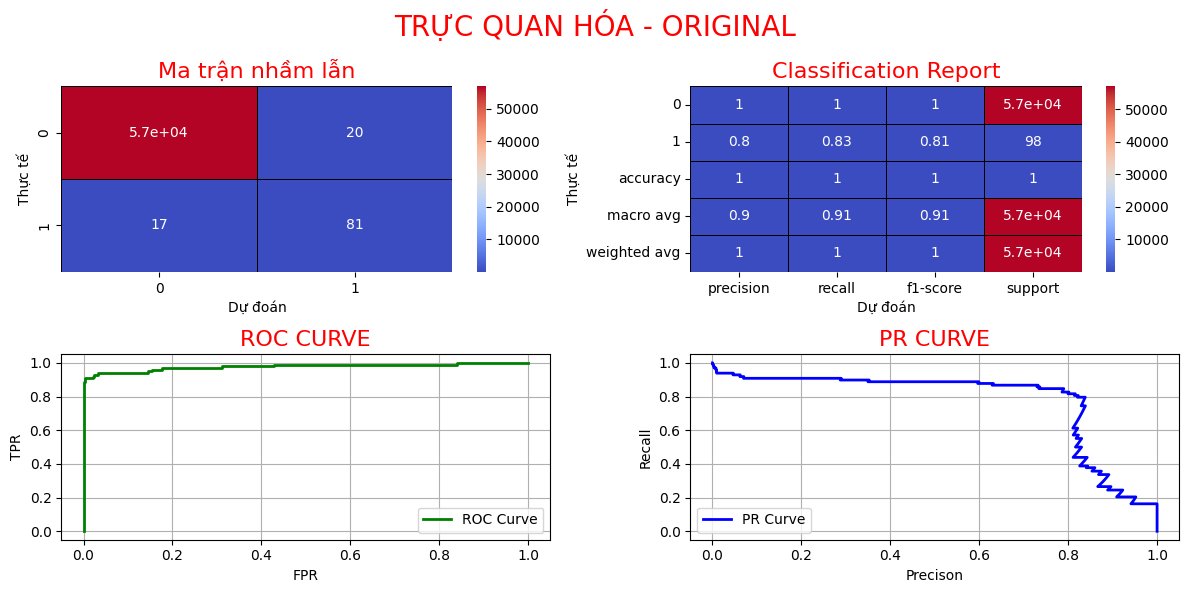


HUẤN LUYỆN VỚI PHƯƠNG PHÁP XỬ LÝ DỮ LIỆU: UNDERSAMPLING
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Đã chuyển đổi dữ liệu Pandas -> Tensor!
----------------------------------------------------------------------------------------------------
Đã chuyển đổi Tensor Dataset và DataLoader!
----------------------------------------------------------------------------------------------------
Đã xây dựng kiến trúc mô hình MLP (Class)!
----------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------
Tiến hành huấn luyện mô hình:
- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -
Epoch 1/15 - Train Loss: 0.030

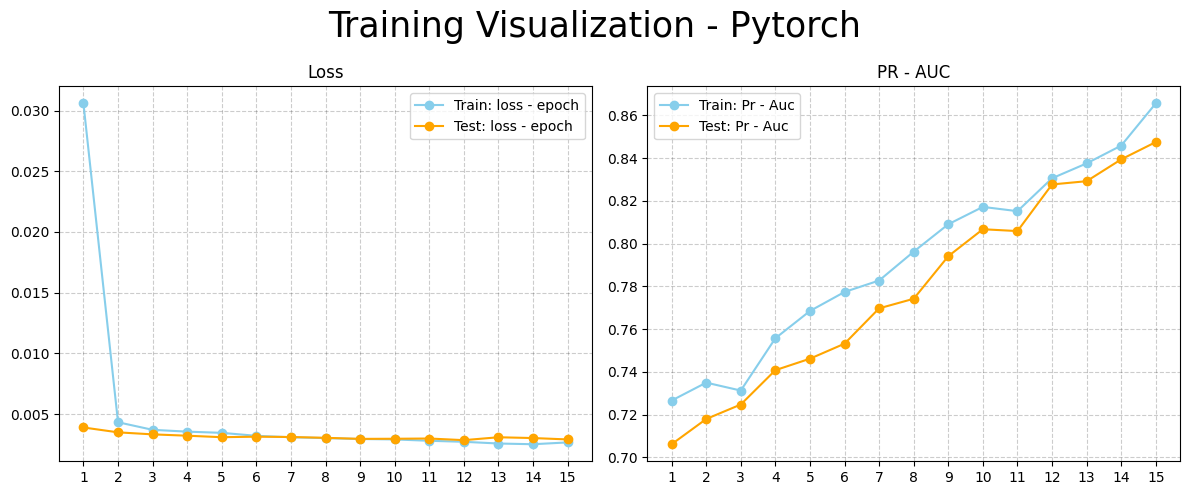

Trực quan hóa kết quả huấn luyện
Tiến hành đánh giá mô hình: 
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Độ chính xác mô hình là:  0.9993328885923949
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Đã tính Ma trận nhầm lẫn! 
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Đã tính Classification Report! 
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Đã tính ROC-AUC!
-------------

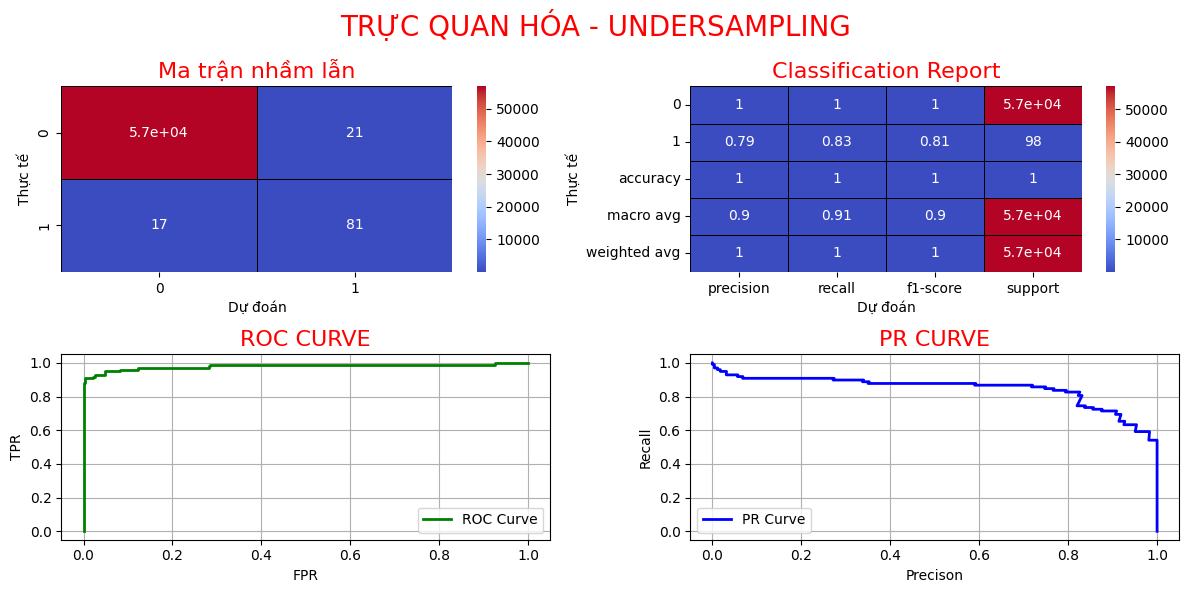


HUẤN LUYỆN VỚI PHƯƠNG PHÁP XỬ LÝ DỮ LIỆU: SMOTE
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Đã chuyển đổi dữ liệu Pandas -> Tensor!
----------------------------------------------------------------------------------------------------
Đã chuyển đổi Tensor Dataset và DataLoader!
----------------------------------------------------------------------------------------------------
Đã xây dựng kiến trúc mô hình MLP (Class)!
----------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------
Tiến hành huấn luyện mô hình:
- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -
Epoch 1/15 - Train Loss: 0.0397, Train

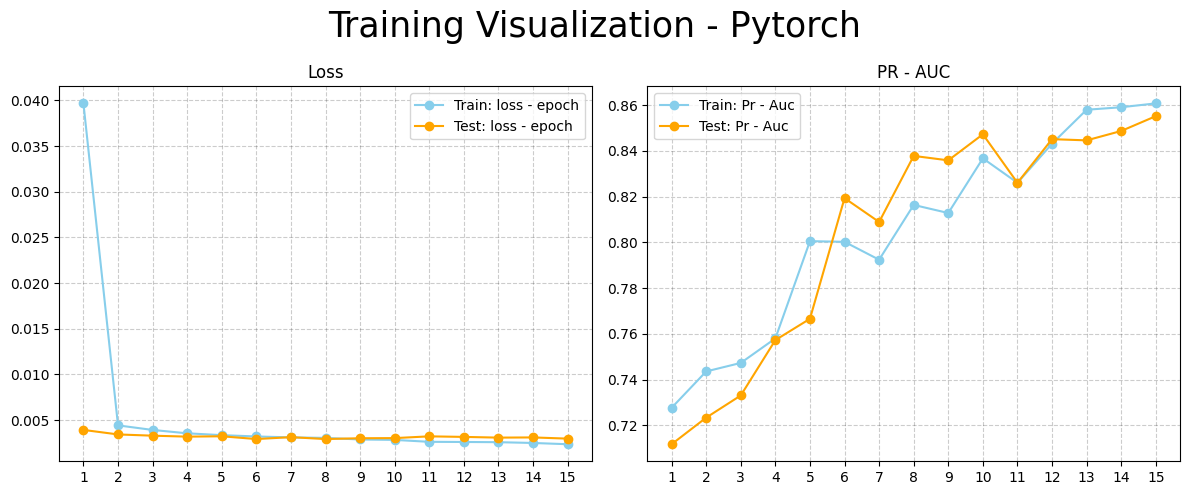

Trực quan hóa kết quả huấn luyện
Tiến hành đánh giá mô hình: 
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Độ chính xác mô hình là:  0.9993328885923949
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Đã tính Ma trận nhầm lẫn! 
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Đã tính Classification Report! 
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Đã tính ROC-AUC!
-------------

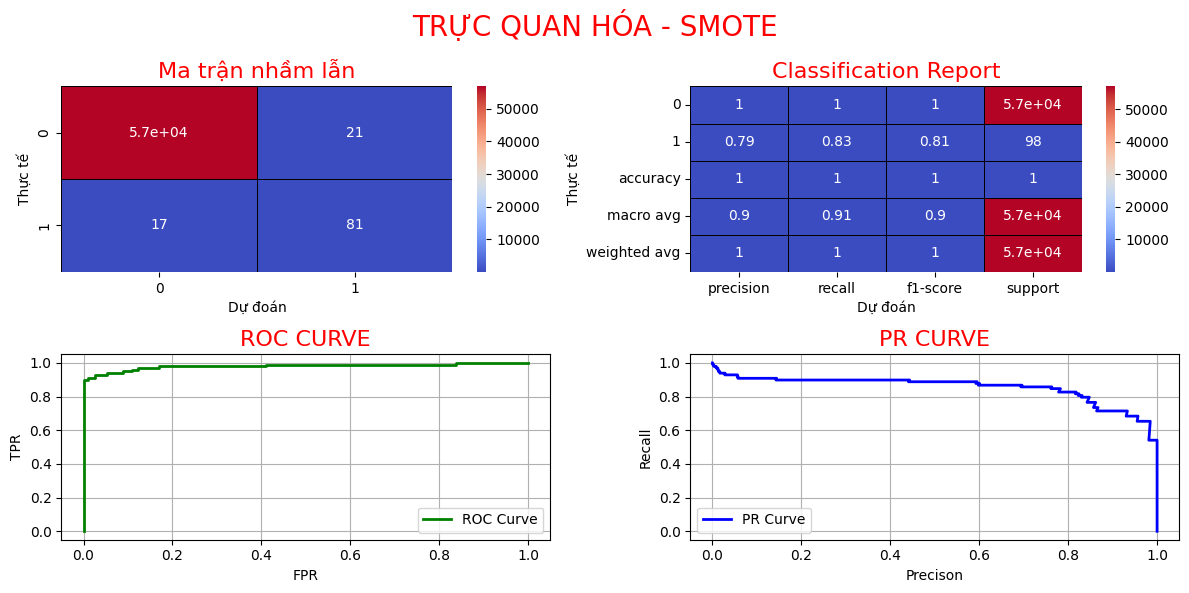


HUẤN LUYỆN VỚI PHƯƠNG PHÁP XỬ LÝ DỮ LIỆU: COMBINED
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Đã chuyển đổi dữ liệu Pandas -> Tensor!
----------------------------------------------------------------------------------------------------
Đã chuyển đổi Tensor Dataset và DataLoader!
----------------------------------------------------------------------------------------------------
Đã xây dựng kiến trúc mô hình MLP (Class)!
----------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------
Tiến hành huấn luyện mô hình:
- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -
Epoch 1/15 - Train Loss: 0.0349, Tr

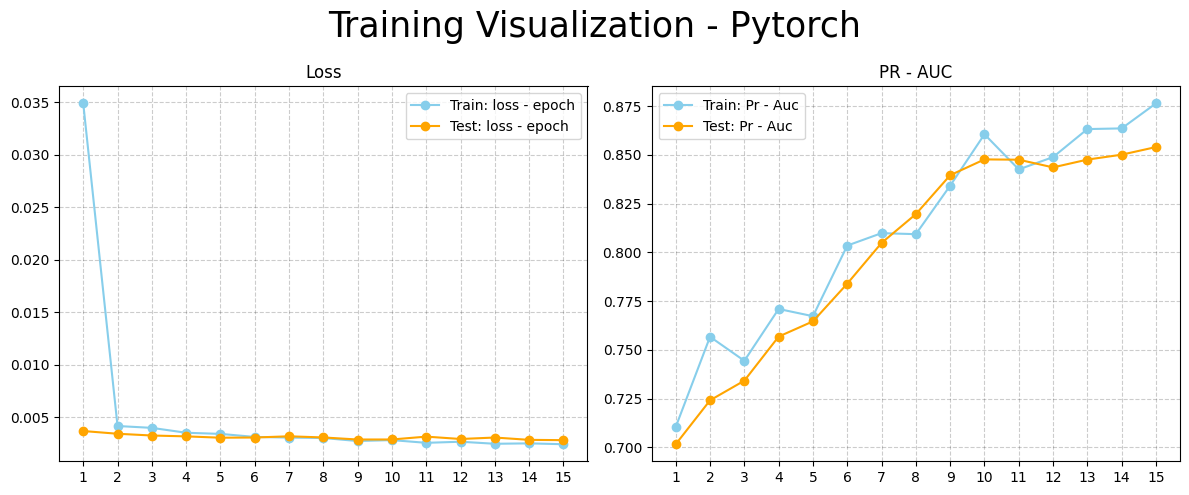

Trực quan hóa kết quả huấn luyện
Tiến hành đánh giá mô hình: 
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Độ chính xác mô hình là:  0.9993679997191109
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Đã tính Ma trận nhầm lẫn! 
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Đã tính Classification Report! 
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Đã tính ROC-AUC!
-------------

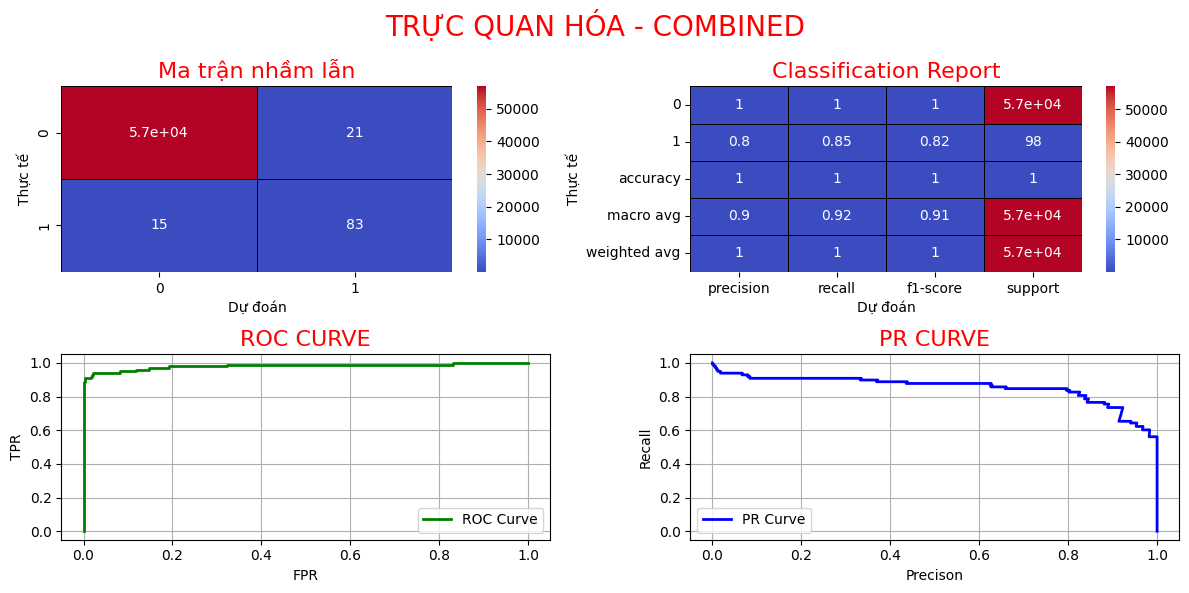

In [ ]:
# Thực hành Huấn luyện và đánh giá mô hình

def train_and_evaluate_model(resampled_data, X_test, y_test):
    # Danh sách các phương pháp xử lý mất cân bằng
    resampling_methods = ['original', 'undersampling', 'smote', 'combined']

    # Lưu trữ kết quả
    results = []

    # Huấn luyện và đánh giá mô hình
    for method in resampling_methods:
        print("HUẤN LUYỆN VỚI PHƯƠNG PHÁP XỬ LÝ DỮ LIỆU:", method.upper())
        print("-"*200)

        X_train_resampled, y_train_resampled = resampled_data[method]

        # Huấn luyện mô hình
        y_prob, y_pred = train_model(X_train, X_test, y_train, y_test, model = 'Pytorch', num_epochs = 15, threshold = 0.5, verbose = True, Vis = True)

        print('='*200)
        print("Trực quan hóa kết quả huấn luyện")
        print('='*200)
        # Đánh giá mô hình:
        result = eva_and_viz_model(X_test, y_test, y_pred, y_prob, method, show = True)
        results.append(result)
        print('='*200)
        print()

    return results

results_mlp_pytorch = train_and_evaluate_model(resampled_data, X_test, y_test)

##✅6. Chọn phương pháp xử lý tốt nhất

### 👉 Code:

    - Lặp qua từng method trong results
    - So sánh và tìm best_method
    - return best_method

In [ ]:
def select_best_method(results):
    print("CHỌN PHƯƠNG PHÁP XỬ LÝ TỐT NHẤT")
    print("-"*100)
    # Truy cập vào từ danh sách từ điển results, truy cập đến key: 'pr_auc'
    # So sánh value của key này, tìm value max
    best_pr_auc = -np.inf
    best_method = None
    for method in results:
        print(f"PR AUC - {method['solu']} : {method['pr_auc']}")
        print('-'*100)
        if method['pr_auc'] > best_pr_auc:
            best_method = method
            best_pr_auc = method['pr_auc']

    print(f"Phương pháp xử lý mất cân bằng tốt nhất là: {best_method['solu'].upper()}, với PR_AUC = {best_pr_auc:.4f} ")
    print("-"*100)
    return best_method

best_method = select_best_method(results_mlp_pytorch)

# Ý tưởng ban đầu: Tối ưu mô hình với phương pháp xử lý dữ liệu đã tối ưu

# Thực hiện: 2 phần tối ưu thực hiện độc lập
# Phần 1: tối ưu riêng để tìm phương pháp xử lý mất cân bằng tốt nhất
# Phần 2: tối ưu mô hình, tìm bộ tham số tốt nhất(với dữ liệu gốc)
#? Liệu mô hình tối ưu đó, có phù hợp với phương pháp xử lý mất cân bằng đã tìm được ko?

# => Tìm mô hình tối ưu trước, sau đó, chọn phương pháp xử lý cân bằng tốt nhất cho mô hình đó


CHỌN PHƯƠNG PHÁP XỬ LÝ TỐT NHẤT
----------------------------------------------------------------------------------------------------
PR AUC - original : 0.7787421693596059
----------------------------------------------------------------------------------------------------
PR AUC - undersampling : 0.8475502920438054
----------------------------------------------------------------------------------------------------
PR AUC - smote : 0.8551859815107502
----------------------------------------------------------------------------------------------------
PR AUC - combined : 0.8540588663347722
----------------------------------------------------------------------------------------------------
Phương pháp xử lý mất cân bằng tốt nhất là: SMOTE, với PR_AUC = 0.8552 
----------------------------------------------------------------------------------------------------


##✅7. Tối ưu hóa mô hình

    Sử dụng GridSearchCV để tìm siêu tham số tối ưu.

### 👉 a. GridSearchCV + Pytorch


Flow:

    - Lấy data huấn luyện
    - Gọi model
    - Xây dựng param_grid
    - Sử dụng StratifiedKFold để giữ nguyên tỷ lệ phân phối các lớp
    - Gọi GridSearchCV(
      Truyền các tham số
    )
    - grid.fit(X_train, y_train)

Trực quan hóa:

    - Đánh giá và vẽ:
        - Ma trận nhầm lẫn
        - Classification Report
        - ROC - AUC
        - PR - AUC

#### ❌ MLP_Grid [Tự xây]

In [ ]:
class MLP(nn.Module):
    def __init__(self, input_dim, n_noron_1 = 64, n_noron_2 = 32, n_noron_3 = 16, dropout = 0.3):
        super(MLP, self).__init__()

        self.n_noron_1 = n_noron_1
        self.n_noron_2 = n_noron_2
        self.n_noron_3 = n_noron_3
        self.dropout = dropout

        self.layers = nn.Sequential(
            # Lớp ẩn thứ nhất
            nn.Linear(input_dim, self.n_noron_1),
            nn.ReLU(),
            nn.Dropout(self.dropout),

            # Lớp ẩn thứ hai
            nn.Linear(self.n_noron_1, self.n_noron_2),
            nn.ReLU(),
            nn.Dropout(self.dropout),

            # Lớp ẩn thứ ba
            nn.Linear(self.n_noron_2, self.n_noron_3),
            nn.ReLU(),

            # Lớp output
            nn.Linear(self.n_noron_3, 1),
            nn.Sigmoid()
            )

    def forward(self, x):
        return self.layers(x)

In [ ]:
class MLP_Grid_:
    def __init__(self, X_train, X_test, y_train, y_test, num_epochs = 2,threshold = 0.5, verbose = True, vis = False, lr = 0.001, n_noron_1 = 16, n_noron_2 = 8, n_noron_3 = 8, dropout = 0.3, batch_size = 512):
        self.X_train = X_train
        self.X_test = X_test
        self.y_train = y_train
        self.y_test = y_test
        self.num_epochs = num_epochs
        self.threshold = threshold
        self.verbose = verbose
        self.vis = vis
        self.lr = lr
        self.batch_size = batch_size

        # Các tham số của mạng
        self.n_noron_1 = n_noron_1
        self.n_noron_2 = n_noron_2
        self.n_noron_3 = n_noron_3
        self.dropout = dropout

        # Mô hình và dữ liệu
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        # convert data
        self.X_train_t, self.X_test_t, self.y_train_t, self.y_test_t = self.pandas_to_tensor_data()

        # Tạo dataloader
        self.train_loader, self.test_loader = self.create_dataloader()

        # Khởi tạo model, loss, optimizer
        input_dim = X_train.shape[1]
        self.model = MLP(
            input_dim,
            self.n_noron_1,
            self.n_noron_2,
            self.n_noron_3,
          ).to(self.device) # Khởi tạo mô hình MLP

        self.criterion = nn.BCELoss() # binary cross entropy
        self.optimizer = optim.Adam( # sử dụng thuật toán tối ưu hóa Adam
            self.model.parameters(), # Lấy trọng số và bias của từng layer
            lr = self.lr
        )

    # Bước 2: Chuyển dữ liệu từ pandas -> tensor
    def pandas_to_tensor_data(self):
        X_train_t = torch.tensor(
            self.X_train.values, # Lấy mảng trong DataFrame X_train
            dtype = torch.float32
        ).to(self.device)

        y_train_t = torch.tensor(
            self.y_train.values,
            dtype = torch.float32
        ).view(-1, 1).to(self.device)

        X_test_t = torch.tensor(
            self.X_test.values,
            dtype = torch.float32
        ).to(self.device)

        y_test_t = torch.tensor(
            self.y_test.values,
            dtype = torch.float32
        ).view(-1, 1).to(self.device)

        print("Đã chuyển đổi dữ liệu Pandas -> Tensor!")
        print('-'*100)

        return X_train_t, X_test_t, y_train_t, y_test_t


    # Bước 3: Tạo Dataset và Dataloader
    def create_dataloader(self):
        train_dataset = TensorDataset(self.X_train_t, self.y_train_t)
        test_dataset = TensorDataset(self.X_test_t, self.y_test_t)

        train_loader = DataLoader(
            train_dataset,
            batch_size = self.batch_size,
            # sampler = sampler
            shuffle = True
          )

        test_loader = DataLoader(
            test_dataset,
            batch_size = self.batch_size,
            shuffle = False,
        )

        print('Đã chuyển đổi Tensor Dataset và DataLoader!')
        print('-'*100)

        return train_loader, test_loader

    # Hàm tính chỉ số phụ
    def calculate_metric_(self, model, data_loader):
        from sklearn.metrics import precision_recall_curve, auc
        all_preds, all_labels = [], []

        # Tính y_probs, lấy y_true
        with torch.no_grad():
            for X_batch, y_batch in data_loader:
                #X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch) # Lấy xác suất dự đoán
                all_preds.extend(outputs.detach().cpu().numpy().flatten()) # y_pred
                all_labels.extend(y_batch.detach().cpu().numpy().flatten()) # y_true

        # Tính pr_auc
        precision, recall, _ = precision_recall_curve(all_labels, all_preds)
        pr_auc = auc(recall, precision)

        return pr_auc

    # Bước 6: Huấn luyện mô hình
    def fit(self, X_train, y_train):
        train_losses, val_losses = [], [] # Lưu lại loss
        train_pr_auc_, val_pr_auc_ = [], [] # Lưu lại PR AUC

        print('-'*100)
        print("Tiến hành huấn luyện mô hình:")
        print('- -'*50)

        for epoch in range(self.num_epochs):
            # Bước 6.1: Training - Huấn luyện
            self.model.train() # Bật chế độ huấn luyện (dropout hoạt động)
            train_loss, correct, train_total = 0, 0, 0

            # Huấn luyện qua từng batch
            for X_batch, y_batch in self.train_loader:
                self.optimizer.zero_grad() # Reset Gradient qua từng Batch
                train_outputs = self.model(X_batch) # Lan truyền xuôi, tính y_prob
                loss = self.criterion(train_outputs, y_batch) # Tính Loss
                loss.backward()
                self.optimizer.step()

                # Tính tổng loss trong từng batch
                train_loss += loss.item() * X_batch.size(0)

                # Lấy y_pred, ngưỡng 0.5
                train_preds = (train_outputs >= self.threshold).float()
                correct += (train_preds == y_batch).sum().item()

                #.sum() trả về một tensor chứa một số duy nhất, ví dụ: tensor(2).
                #.item() biến nó thành giá trị Python scalar (int/float), để có thể cộng dồn hoặc in ra dễ dàng.

                # Tính tổng số mẫu huấn luyện
                train_total += y_batch.size(0) # tensor.size(dim)

            train_loss = train_loss / train_total
            train_pr_auc = self.calculate_metric_(self.model, self.train_loader)

            # Bước 6.2: Evaluation - Đánh giá
            self.model.eval()
            y_prob, y_pred = [], []
            val_loss, val_correct, val_total = 0, 0, 0

            with torch.no_grad():
                for X_batch, y_batch in self.test_loader:
                    #X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                    val_outputs = self.model(X_batch)
                    loss = self.criterion(val_outputs, y_batch)
                    val_loss += loss.item() * X_batch.size(0)
                    val_preds = (val_outputs >= self.threshold).float()

                    val_correct += (val_preds == y_batch).sum().item()
                    val_total += y_batch.size(0)

                    y_prob.extend(val_outputs.detach().cpu().numpy().flatten()) # y_pred
                    y_pred.extend(val_preds.detach().cpu().numpy().flatten())

            val_loss = val_loss / val_total
            val_pr_auc = self.calculate_metric_(self.model, self.test_loader)

            # Lưu lại
            train_losses.append(train_loss)
            val_losses.append(val_loss)
            train_pr_auc_.append(train_pr_auc)
            val_pr_auc_.append(val_pr_auc)

            if self.verbose:
                # In kết quả huấn luyện
                print(
                    f"Epoch {epoch + 1}/{self.num_epochs} "
                    f"- Train Loss: {train_loss:.4f}, Train PR_AUC: {train_pr_auc:.4f} "
                    f"- Val Loss: {val_loss:.4f}, Val PR_AUC: {val_pr_auc:.4f}"
                )
        if self.vis:
            print('='*200)
            print("Trực quan hóa quá trình huấn luyện")
            print('='*200)
            # Trực quan hóa quá trình huấn luyện
            plt.figure(figsize = (12, 5))

            # Vẽ biểu đồ bên trái: loss - epoch
            plt.subplot(1, 2, 1)

            epochs = np.arange(1, self.num_epochs + 1)
            # Tập train
            plt.plot(
                epochs,
                train_losses,
                marker = 'o',
                label = 'Train: loss - epoch',
                color = 'skyblue'
            )

            # Tập test
            plt.plot(
                epochs,
                val_losses,
                marker = 'o',
                label = 'Test: loss - epoch',
                color = 'orange'
            )
            plt.title("Loss")

            plt.xticks(epochs)
            plt.grid(
                linestyle = '--',
                alpha = 0.2,
                color = 'black'
            )
            plt.legend()

            # Biểu đồ Pr_AUC - Epoch
            plt.subplot(1, 2, 2)

            # Tập train
            plt.plot(
                epochs,
                train_pr_auc_,
                marker = 'o',
                color = 'skyblue',
                label = 'Train: Pr - Auc'
            )

            # Tập test
            plt.plot(
                epochs,
                val_pr_auc_,
                marker = 'o',
                color = 'orange',
                label = 'Test: Pr - Auc'
            )

            plt.xticks(epochs)

            plt.title("PR - AUC")
            plt.legend()

            plt.suptitle(
                "Training Visualization - Pytorch",
                fontsize = 25
                )
            plt.grid(
                linestyle = '--',
                alpha = 0.2,
                color = 'black'
            )
            plt.tight_layout()
            plt.show()
            plt.close()
        return self
    def predict_proba(self, X):
        X_test_ = torch.tensor(
            X.values,
            dtype = torch.float32
        ).to(self.device)
        y_prob = self.model(X_test_).detach().cpu().numpy().flatten()
        return y_prob

    def predict(self, X):
        X_test_ = torch.tensor(
            X.values,
            dtype = torch.float32
        ).to(self.device)
        return (self.model(X_test_) >= self.threshold).int().detach().cpu().numpy().flatten()

    def get_params(self, deep = True):
        return {
            "num_epochs": self.num_epochs,
            "threshold": self.threshold,
            "verbose": self.verbose,
            "vis": self.vis,
            "lr": self.lr,
            "n_noron_1": self.n_noron_1,
            "n_noron_2": self.n_noron_2,
            "n_noron_3": self.n_noron_3,
            "dropout": self.dropout,
            "batch_size": self.batch_size
        }

    def set_params(self, **params):
        for key, value in params.items():
            setattr(self, key, value)
        return self

Đã chuyển đổi dữ liệu Pandas -> Tensor!
----------------------------------------------------------------------------------------------------
Đã chuyển đổi Tensor Dataset và DataLoader!
----------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------
Tiến hành huấn luyện mô hình:
- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -
Epoch 1/15 - Train Loss: 0.0296, Train PR_AUC: 0.7042 - Val Loss: 0.0038, Val PR_AUC: 0.6762
Epoch 2/15 - Train Loss: 0.0043, Train PR_AUC: 0.7193 - Val Loss: 0.0036, Val PR_AUC: 0.7205
Epoch 3/15 - Train Loss: 0.0040, Train PR_AUC: 0.7340 - Val Loss: 0.0034, Val PR_AUC: 0.7213
Epoch 4/15 - Train Loss: 0.0037, Train PR_AUC: 0.7408 - Val Loss: 0.0033, Val PR_AUC: 0.7185
Epoch 5/15 - Train Loss: 0.0036, Train PR_AUC: 0.7430 - Val 

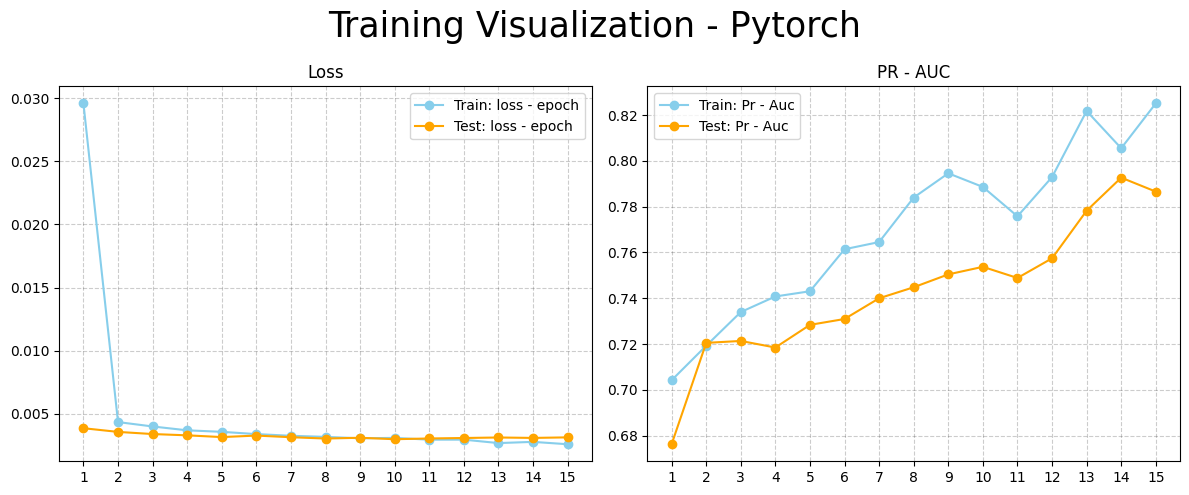

In [ ]:
model_py = MLP_Grid_(
    X_train, X_test, y_train, y_test,
    num_epochs = 15,
    threshold = 0.5,
    verbose = True, vis = True,
    lr = 0.001,
    n_noron_1 = 64,
    n_noron_2 = 32,
    n_noron_3 = 16
    )

train_results = model_py.fit(X_train, y_train)


In [ ]:
y_pred = model_py.predict_proba(X_test)
print(y_pred)

print('-'*100)

y_pred = model_py.predict(X_test)
print(y_pred)

[1.6873965e-07 3.6697096e-05 4.3869871e-04 ... 8.3599332e-09 5.6517099e-08
 6.9857910e-05]
----------------------------------------------------------------------------------------------------
[0 0 0 ... 0 0 0]


In [ ]:
param_grid = {
    #'lr': [0.01, 0.001],
    #'num_epochs': [5, 10],
    'n_noron_1': [8, 16],
    #'n_noron_2': [8, 16],
    #'n_noron_3': [8, 16],
}

grid = GridSearchCV(
    model_py,
    param_grid,
    cv = 5,
    scoring = 'average_precision',
    n_jobs = -1)
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
print("Best Score:", grid.best_score_)

return grid.best_estimator_

TypeError: MLP_Grid.__init__() missing 4 required positional arguments: 'X_train', 'X_test', 'y_train', and 'y_test'

#### ❌ MLP_Grid [Mẫu] - Pytorch

In [ ]:
from sklearn.base import BaseEstimator, ClassifierMixin
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt

class MLP_Grid(ClassifierMixin, BaseEstimator):
    #_estimator_type = "classifier"
    def __init__(self, num_epochs = 1, threshold = 0.5, verbose = True, vis = False,
                 lr = 0.001, n_noron_1 = 16, n_noron_2 = 8, n_noron_3 = 8, dropout = 0.3, batch_size = 512):
        super().__init__()            #
        # chỉ chứa hyperparams
        self.num_epochs = num_epochs
        self.threshold = threshold
        self.verbose = verbose
        self.vis = vis
        self.lr = lr
        self.batch_size = batch_size
        self.n_noron_1 = n_noron_1
        self.n_noron_2 = n_noron_2
        self.n_noron_3 = n_noron_3
        self.dropout = dropout
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        self._estimator_type = "classifier"
    def _build_model(self, input_dim):
        # Định nghĩa MLP
        return nn.Sequential(
            # Lớp ẩn thứ nhất
            nn.Linear(input_dim, self.n_noron_1),
            nn.ReLU(),
            nn.Dropout(self.dropout),

            # Lớp ẩn thứ hai
            nn.Linear(self.n_noron_1, self.n_noron_2),
            nn.ReLU(),
            nn.Dropout(self.dropout),

            # Lớp ẩn thứ ba
            nn.Linear(self.n_noron_2, self.n_noron_3),
            nn.ReLU(),
            # nn.Dropout(self.dropout),

            # Lớp output
            nn.Linear(self.n_noron_3, 1),
            nn.Sigmoid()
        ).to(self.device)

    def fit(self, X, y):
        # convert pandas/numpy -> tensor
        X_t = torch.tensor(np.array(X), dtype = torch.float32).to(self.device)
        y_t = torch.tensor(np.array(y), dtype = torch.float32).view(-1, 1).to(self.device)

        dataset = TensorDataset(X_t, y_t)
        loader = DataLoader(dataset, batch_size = self.batch_size, shuffle = True)

        # build model
        input_dim = X.shape[1]
        self.model = self._build_model(input_dim)
        self.criterion = nn.BCELoss()
        self.optimizer = optim.Adam(self.model.parameters(), lr=self.lr)

        # train loop
        for epoch in range(self.num_epochs):
            self.model.train()
            epoch_loss = 0
            for xb, yb in loader:
                self.optimizer.zero_grad()
                preds = self.model(xb)
                loss = self.criterion(preds, yb)
                loss.backward()
                self.optimizer.step()
                epoch_loss += loss.item() * xb.size(0)

            if self.verbose:
                print(f"Epoch {epoch+1}/{self.num_epochs} - Loss: {epoch_loss/len(dataset):.4f}")

        print('-'*100)
        print('Đã huấn luyện!')
        print('-'*100)

        self.classes_ = np.array([0, 1])  # khai báo là classifier nhị phân
        return self

    def predict_proba(self, X):
        self.model.eval()
        X_t = torch.tensor(
            np.array(X),
            dtype = torch.float32
          ).to(self.device)

        # with torch.no_grad():
        #     probs = self.model(X_t).detach().cpu().numpy().flatten()
        # # sklearn yêu cầu dạng (n_samples, 2)
        # return np.vstack([1 - probs, probs]).T

        with torch.no_grad():
            probs = self.model(X_t).detach().cpu().numpy().flatten()
        if np.isnan(probs).any():
            raise ValueError(f"NaN found in predicted probabilities (min/max): {np.nanmin(probs)}/{np.nanmax(probs)}")

        #print("predict_proba called - probs stats:", probs.min(), probs.max())
        return np.vstack([1.0 - probs, probs]).T
        #return probs

    def predict(self, X):
        probs = self.predict_proba(X)[:, 1]
        return (probs >= self.threshold).astype(int)


##### Tính Average Precision thủ công

In [ ]:
model_py = MLP_Grid(
    num_epochs = 15,
    threshold = 0.5,
    verbose = True, vis = True,
    n_noron_1 = 64,
    n_noron_2 = 32,
    n_noron_3 = 16
  )

model_py.fit(X_train, y_train)


Epoch 1/15 - Loss: 0.0407
Epoch 2/15 - Loss: 0.0043
Epoch 3/15 - Loss: 0.0040
Epoch 4/15 - Loss: 0.0036
Epoch 5/15 - Loss: 0.0034
Epoch 6/15 - Loss: 0.0033
Epoch 7/15 - Loss: 0.0031
Epoch 8/15 - Loss: 0.0029
Epoch 9/15 - Loss: 0.0028
Epoch 10/15 - Loss: 0.0028
Epoch 11/15 - Loss: 0.0028
Epoch 12/15 - Loss: 0.0026
Epoch 13/15 - Loss: 0.0026
Epoch 14/15 - Loss: 0.0026
Epoch 15/15 - Loss: 0.0024
----------------------------------------------------------------------------------------------------
Đã huấn luyện!
----------------------------------------------------------------------------------------------------


MLP_Grid(n_noron_1=64, n_noron_2=32, n_noron_3=16, num_epochs=15, vis=True)

In [ ]:
y_proba = model_py.predict_proba(X_test)
display(y_proba)

print('-'*100)

y_pred = model_py.predict(X_test)
display(y_pred.sum())

array([[1.0000000e+00, 4.4055532e-12],
       [9.9999952e-01, 4.6380893e-07],
       [9.9987704e-01, 1.2297816e-04],
       ...,
       [1.0000000e+00, 2.5775291e-14],
       [1.0000000e+00, 1.4323933e-11],
       [9.9999523e-01, 4.7870162e-06]], dtype=float32)

----------------------------------------------------------------------------------------------------


np.int64(95)

In [ ]:
from sklearn.metrics import average_precision_score

y_true = y_test
y_score = y_proba[:, 1]

print("sklearn:", average_precision_score(y_true, y_score))


sklearn: 0.6910901149605713


In [ ]:
model_py = MLP_Grid(
    num_epochs = 5,
    threshold = 0.5,
    verbose = True, vis = True,
    n_noron_1 = 16,
    n_noron_2 = 16,
    n_noron_3 = 8
    )

for train_idx, valid_idx in cv.split(X_train, y_train):
    print("Train:", np.bincount(y_train.iloc[train_idx]))
    print("Valid:", np.bincount(y_train.iloc[valid_idx]))
    print('-'*100)

    X_train_cv = X_train.iloc[train_idx]
    y_train_cv = y_train.iloc[train_idx]

    model_py.fit(X_train, y_train)

    y_proba = model_py.predict_proba(X_test)

    y_pred = model_py.predict(X_test)

    y_true = y_test
    y_score = y_proba[:, 1]

    print("sklearn:", average_precision_score(y_true, y_score))

    print('='*100)

Train: [181960    316]
Valid: [45491    78]
----------------------------------------------------------------------------------------------------
Epoch 1/5 - Loss: 0.0689
Epoch 2/5 - Loss: 0.0070
Epoch 3/5 - Loss: 0.0060
Epoch 4/5 - Loss: 0.0058
Epoch 5/5 - Loss: 0.0058
sklearn: 0.7210983596766036
Train: [181961    315]
Valid: [45490    79]
----------------------------------------------------------------------------------------------------
Epoch 1/5 - Loss: 0.1009
Epoch 2/5 - Loss: 0.0098
Epoch 3/5 - Loss: 0.0085
Epoch 4/5 - Loss: 0.0084
Epoch 5/5 - Loss: 0.0080
sklearn: 0.7105801503676306
Train: [181961    315]
Valid: [45490    79]
----------------------------------------------------------------------------------------------------
Epoch 1/5 - Loss: 0.1521
Epoch 2/5 - Loss: 0.0295
Epoch 3/5 - Loss: 0.0281
Epoch 4/5 - Loss: 0.0251
Epoch 5/5 - Loss: 0.0231
sklearn: 0.718502083296233
Train: [181961    315]
Valid: [45490    79]
---------------------------------------------------------------

##### Chạy GridSearch

In [ ]:
from sklearn.model_selection import GridSearchCV

cv = StratifiedKFold(
    n_splits = 5,
    shuffle = True,
    random_state = 42
  )

param_grid = {
    "lr": [0.01, 0.001],
    "n_noron_1": [128, 64, 32, 16],
    "n_noron_2": [16, 32, 64],
    "n_noron_3": [16, 32, 64],
    "num_epochs": [5, 10, 15]
}

grid = GridSearchCV(
    estimator = MLP_Grid(),
    param_grid = param_grid,
    scoring = "average_precision",
    cv = cv
)

X = df.drop(['Class', 'Time'], axis = 1)
y = df['Class']

grid.fit(X, y.to_numpy())
print("Best params:", grid.best_params_)

cv_res = pd.DataFrame(
    grid.cv_results_
  )
pd.set_option(
    "display.max_columns",
    None
  )

print('-'*100)
print("Kết quả GridSearch:")
print('-'*100)

print(
    cv_res.filter(
        regex="split"
      )
  )  # chỉ in các cột split

print('-'*100)
print("Thông số Best Param:")
print('-'*100)

best_index = grid.best_index_
cv_res.iloc[best_index, :]

Epoch 1/5 - Loss: 0.6943
Epoch 2/5 - Loss: 0.6932
Epoch 3/5 - Loss: 0.6932
Epoch 4/5 - Loss: 0.6932
Epoch 5/5 - Loss: 0.6932
----------------------------------------------------------------------------------------------------
Đã huấn luyện!
----------------------------------------------------------------------------------------------------
Epoch 1/5 - Loss: 0.6969
Epoch 2/5 - Loss: 0.6932
Epoch 3/5 - Loss: 0.6932
Epoch 4/5 - Loss: 0.6932
Epoch 5/5 - Loss: 0.6932
----------------------------------------------------------------------------------------------------
Đã huấn luyện!
----------------------------------------------------------------------------------------------------
Epoch 1/5 - Loss: 0.6963
Epoch 2/5 - Loss: 0.6932
Epoch 3/5 - Loss: 0.6932
Epoch 4/5 - Loss: 0.6932
Epoch 5/5 - Loss: 0.6932
----------------------------------------------------------------------------------------------------
Đã huấn luyện!
---------------------------------------------------------------------------

KeyboardInterrupt: 

In [ ]:
print("Best params:", grid.best_params_)
print("Best index:", grid.best_index_)
cv_res = pd.DataFrame(
    grid.cv_results_
  )
best_index = grid.best_index_
cv_res.iloc[best_index, :]

Best params: {'lr': 0.01, 'n_noron_1': 32, 'n_noron_2': 32, 'n_noron_3': 16, 'num_epochs': 15}
Best index: 65


,65
mean_fit_time,0.678458
std_fit_time,0.089617
mean_score_time,0.002808
std_score_time,0.000334
param_lr,0.01
param_n_noron_1,32
param_n_noron_2,32
param_n_noron_3,16
param_num_epochs,15
params,"{'lr': 0.01, 'n_noron_1': 32, 'n_noron_2': 32,..."


##### Test Class MLP_Grid

In [ ]:
from sklearn.base import is_classifier

m = MLP_Grid(num_epochs=1)
print(is_classifier(m))   # phải ra True


False


In [ ]:
from sklearn.base import is_classifier

print(is_classifier(MLP_Grid))       # ✅ True, check trên class
print(is_classifier(MLP_Grid()))     # ✅ True, check trên instance
print(MLP_Grid._estimator_type)      # ✅ 'classifier'
print(getattr(MLP_Grid(), "_estimator_type", None))  # ✅ 'classifier'


is_classifier
True
False
classifier
classifier


In [ ]:
print(MLP_Grid.__dict__.get("_estimator_type"))
print(getattr(MLP_Grid(), "_estimator_type", None))
from sklearn.base import is_classifier
print(is_classifier(MLP_Grid()))


classifier
classifier
False


In [ ]:
grid = GridSearchCV(
    estimator = MLP_Grid(),
    param_grid = param_grid,
    scoring = "average_precision",
    cv = cv,
    n_jobs = -1,
    return_train_score = True
)

grid.fit(X_train, y_train)

import pandas as pd
cv_res = pd.DataFrame(grid.cv_results_)
pd.set_option("display.max_columns", None)
print(cv_res.filter(regex="split"))  # chỉ in các cột split


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan]
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the train scores are non-finite: [nan nan]
  warnings.warn(


Epoch 1/1 - Loss: 0.1128
   split0_test_score  split1_test_score  split2_test_score  split3_test_score  \
0                NaN                NaN                NaN                NaN   
1                NaN                NaN                NaN                NaN   

   split4_test_score  split0_train_score  split1_train_score  \
0                NaN                 NaN                 NaN   
1                NaN                 NaN                 NaN   

   split2_train_score  split3_train_score  split4_train_score  
0                 NaN                 NaN                 NaN  
1                 NaN                 NaN                 NaN  


#### ❌ MLP_Grid [Mẫu] - Tensorflow

    Code mẫu - Chưa test

In [ ]:
from sklearn.base import BaseEstimator, ClassifierMixin

class MLP_Grid(BaseEstimator, ClassifierMixin):
    def __init__(self, hidden_units=64, epochs=10, lr=0.01):
        self.hidden_units = hidden_units
        self.epochs = epochs
        self.lr = lr
        self.model = None

    def fit(self, X, y):
        import tensorflow as tf
        self.model = tf.keras.Sequential([
            tf.keras.layers.Dense(self.hidden_units, activation='relu'),
            tf.keras.layers.Dense(len(set(y)), activation='softmax')
        ])
        self.model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=self.lr),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )
        self.model.fit(X, y, epochs=self.epochs, verbose=0)
        return self

    def predict(self, X):
        y_pred = self.model.predict(X)
        return y_pred.argmax(axis=1)


#### ❌ skorch

    Đã chạy GridSearch
    Chưa đọc và đánh giá kết quả

In [ ]:
class MLP(nn.Module):
    def __init__(self, input_dim, n_noron_1 = 64, n_noron_2 = 32, n_noron_3 = 16, dropout = 0.3):
        super(MLP, self).__init__()

        self.n_noron_1 = n_noron_1
        self.n_noron_2 = n_noron_2
        self.n_noron_3 = n_noron_3
        self.dropout = dropout

        self.layers = nn.Sequential(
            # Lớp ẩn thứ nhất
            nn.Linear(input_dim, self.n_noron_1),
            nn.ReLU(),
            nn.Dropout(self.dropout),

            # Lớp ẩn thứ hai
            nn.Linear(self.n_noron_1, self.n_noron_2),
            nn.ReLU(),
            nn.Dropout(self.dropout),

            # Lớp ẩn thứ ba
            nn.Linear(self.n_noron_2, self.n_noron_3),
            nn.ReLU(),

            # Lớp output
            nn.Linear(self.n_noron_3, 1),
            nn.Sigmoid()
            )

    def forward(self, x):
        return self.layers(x)

In [ ]:
from skorch import NeuralNetClassifier #skorch: thư viện wrapper - biến mô hình pytorch thành estimator theo chuẩn sklearn

net = NeuralNetClassifier(
    module = MLP,
    module__input_dim = X_train.shape[1],
    max_epochs = 40,
    lr = 0.001,
    optimizer = torch.optim.Adam,
    #criterion = nn.BCEWithLogitsLoss,
    criterion = nn.BCELoss(), # binary cross entropy
    device = 'cuda'
)

X_train, y_train = resampled_data[best_method['solu']]

net.fit(
    X_train.values.astype(np.float32),
    y_train.values.reshape(-1, 1).astype(np.float32)
  )
y_pred = net.predict(X_test.values.astype(np.float32))
y_prob = net.predict_proba(X_test.values.astype(np.float32))


  epoch    train_loss    valid_acc    valid_loss     dur
-------  ------------  -----------  ------------  ------
      1        0.6741       0.9089        0.5272  0.0903
      2        0.4825       0.9089        0.3276  0.0906
      3        0.3008       0.9343        0.2273  0.1022
      4        0.2048       0.9469        0.1836  0.0897
      5        0.1542       0.9677        0.1516  0.0896
      6        0.1246       0.9758        0.1301  0.0894
      7        0.1067       0.9758        0.1179  0.0909
      8        0.0966       0.9746        0.1118  0.0902
      9        0.0886       0.9746        0.1077  0.0892
     10        0.0834       0.9746        0.1032  0.0921
     11        0.0858       0.9758        0.1008  0.0888
     12        0.0800       0.9769        0.0977  0.0886
     13        0.0780       0.9769        0.0952  0.0913
     14        0.0793       0.9769        0.0944  0.1007
     15        0.0722       0.9792        0.0937  0.0899
     16        0.0736       0.9

In [ ]:
params = {
    'lr': [0.001, 0.005],
    'max_epochs': [10, 20],
}

gs = GridSearchCV(
    net,
    params,
    cv = 5,
    scoring = 'average_precision'
  )
gs.fit(
    X_train.values.astype(np.float32),
    y_train.values.reshape(-1, 1).astype(np.float32)
  )

  epoch    train_loss    valid_acc    valid_loss     dur
-------  ------------  -----------  ------------  ------
      1        0.5637       0.9092        0.4222  0.0716
      2        0.4019       0.9092        0.3012  0.0777
      3        0.2970       0.9092        0.2252  0.0809
      4        0.2294       0.9294        0.1830  0.0727
      5        0.1893       0.9568        0.1498  0.0711
      6        0.1566       0.9769        0.1198  0.0702
      7        0.1353       0.9827        0.0946  0.0703
      8        0.1159       0.9841        0.0780  0.0708
      9        0.1083       0.9885        0.0678  0.0724
     10        0.1018       0.9885        0.0616  0.0709
  epoch    train_loss    valid_acc    valid_loss     dur
-------  ------------  -----------  ------------  ------
      1        0.7268       0.8991        0.5723  0.0694
      2        0.5234       0.9092        0.3663  0.0706
      3        0.3436       0.9092        0.2674  0.0750
      4        0.2493       0.9

GridSearchCV(cv=5,
             estimator=NeuralNetClassifier(_params_to_validate={'module__input_dim'}, batch_size=128, callbacks=None, compile=False, criterion=BCELoss(), dataset=<class 'skorch.dataset.Dataset'>, device='cuda', iterator_train=<class 'torch.utils.data.dataloader.DataLoader'>, iterator_valid=<class 'torch.utils.data.dataloader.DataLoader'>, lr=0.001, max_epochs=40, module=<class '__main__.MLP'>, module__input_dim=34, optimizer=<class 'torch.optim.adam.Adam'>, predict_nonlinearity='auto', torch_load_kwargs=None, use_caching='auto', verbose=1, warm_start=False),
             param_grid={'lr': [0.001, 0.005], 'max_epochs': [10, 20]},
             scoring='average_precision')

#### ❌ MLP của sklearn

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV

mlp = MLPClassifier(max_iter=500)
params = {
    'hidden_layer_sizes': [(50,), (100,)],
    'alpha': [0.0001, 0.001],
}

gs = GridSearchCV(mlp, params, cv=3, scoring='accuracy')
gs.fit(X, y)

In [ ]:
def optimize_best_model(best_method, resampled_data, X_test, y_test):
    print('TỐI ƯU HÓA MÔ HÌNH')
    print("-"*100)

    # 7.0. Lấy dữ liệu huấn luyện
    X_train, y_train = resampled_data[best_method]
    # 7.1. Khởi tạo mô hình
    model = RandomForestClassifier(random_state =  42)

    # 7.2. Khai báo các siêu tham số cần thử
    param_grid = {
        'n_estimators': np.arange(20,100,40).tolist(),
        #'max_depth': np.arange(5,21,5).tolist(),
        'class_weight': [None, 'balanced']
    }
    # 7.3. Thiết lập cv với StratifiedKFOLD để giữ nguyên tỷ lệ phân phối các lớp
    skf = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)

    # 7.4 Dùng GridSearchCV để thử các tổ hợp siêu tham số
    grid = GridSearchCV(
        estimator = model,
        param_grid = param_grid,
        cv = skf,
        scoring = 'average_precision',
        n_jobs = -1,
        verbose = 1
        )
    print("Đang thực hiện tìm kiếm lưới")
    grid.fit(X_train, y_train)

    print("Best Params:", grid.best_params_)
    print("Best Score:", grid.best_score_)

    return grid.best_estimator_

best_model = optimize_best_model(best_method, resampled_data, X_test, y_test)

TỐI ƯU HÓA MÔ HÌNH
----------------------------------------------------------------------------------------------------
Đang thực hiện tìm kiếm lưới
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best Params: {'class_weight': 'balanced', 'n_estimators': 60}
Best Score: 0.9997662468825069


### 👉 b. RandomizedSearchCV + Pytorch

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

cv = StratifiedKFold(
    n_splits = 3,
    shuffle = True,
    random_state = 42
  )

param_grid = {
    "lr": [0.01, 0.001],
    "n_noron_1": [128, 64, 32, 16],
    "n_noron_2": [16, 32, 64],
    "n_noron_3": [16, 32, 64],
    "num_epochs": [5, 10, 15]
}

search = RandomizedSearchCV(
    estimator = MLP_Grid(),
    param_distributions = param_grid,
    n_iter = 5,   # chỉ thử 5 tổ hợp
    cv = cv,
    scoring = "average_precision",
    #n_jobs = -1,
    random_state = 42
)

X = df.drop(['Class', 'Time'], axis = 1)
y = df['Class']

search.fit(X, y.to_numpy())
print("Best params:", search.best_params_)


cv_res = pd.DataFrame(search.cv_results_)   # <--- đổi từ grid thành search
pd.set_option("display.max_columns", None)

print('-'*100)
print("Kết quả RandomizedSearch:")
print('-'*100)
print(cv_res.filter(regex="split"))   # chỉ in cột split

print('-'*100)
print("Thông số Best Param:")
print('-'*100)
best_index = search.best_index_       # <--- đổi từ grid thành search
print(cv_res.iloc[best_index, :])

Epoch 1/5 - Loss: 0.7074
Epoch 2/5 - Loss: 0.6932
Epoch 3/5 - Loss: 0.6932
Epoch 4/5 - Loss: 0.6932
Epoch 5/5 - Loss: 0.6932
----------------------------------------------------------------------------------------------------
Đã huấn luyện!
----------------------------------------------------------------------------------------------------
Epoch 1/5 - Loss: 0.7151
Epoch 2/5 - Loss: 0.6932
Epoch 3/5 - Loss: 0.6931
Epoch 4/5 - Loss: 0.6931
Epoch 5/5 - Loss: 0.6931
----------------------------------------------------------------------------------------------------
Đã huấn luyện!
----------------------------------------------------------------------------------------------------
Epoch 1/5 - Loss: 0.7070
Epoch 2/5 - Loss: 0.6932
Epoch 3/5 - Loss: 0.6932
Epoch 4/5 - Loss: 0.6932
Epoch 5/5 - Loss: 0.6931
----------------------------------------------------------------------------------------------------
Đã huấn luyện!
---------------------------------------------------------------------------

### 👉 c. Tối ưu + Trực quan hóa kết quả

In [ ]:
def optimize_best_model(best_method, resampled_data, X_test, y_test):
    print('TỐI ƯU HÓA MÔ HÌNH')
    print("-"*100)

    # 7.0. Lấy dữ liệu huấn luyện
    X_train, y_train = resampled_data[best_method]
    # 7.1. Khởi tạo mô hình
    model = RandomForestClassifier(random_state =  42)

    # 7.2. Khai báo các siêu tham số cần thử
    param_grid = {
        'n_estimators': np.arange(50,101,40).tolist(),
        'max_depth': np.arange(5,21,5).tolist(),
        'class_weight': [None, 'balanced']
    }
    # 7.3. Thiết lập cv với StratifiedKFOLD để giữ nguyên tỷ lệ phân phối các lớp
    skf = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)

    # 7.4 Dùng GridSearchCV để thử các tổ hợp siêu tham số
    grid = GridSearchCV(
        estimator = model,
        param_grid = param_grid,
        cv = skf,
        scoring = 'average_precision',
        n_jobs = -1,
        verbose = 1
        )
    print("Đang thực hiện tìm kiếm lưới")
    grid.fit(X_train, y_train)

    print("Best Params:", grid.best_params_)
    print("Best Score:", grid.best_score_)

    return grid.best_estimator_

best_model = optimize_best_model(best_method, resampled_data, X_test, y_test)

y_pred = best_model.predict(X_test)

y_prob = best_model.predict_proba(X_test)[:, 1]

result = eva_and_viz_model(best_model, X_test, y_test, y_pred, y_prob, best_method)

Tiến hành đánh giá mô hình: 
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Độ chính xác mô hình là:  0.9994908886626171
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Đã tính Ma trận nhầm lẫn! 
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Đã tính Classification Report! 
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Đã tính ROC-AUC!
----------------------------------------------

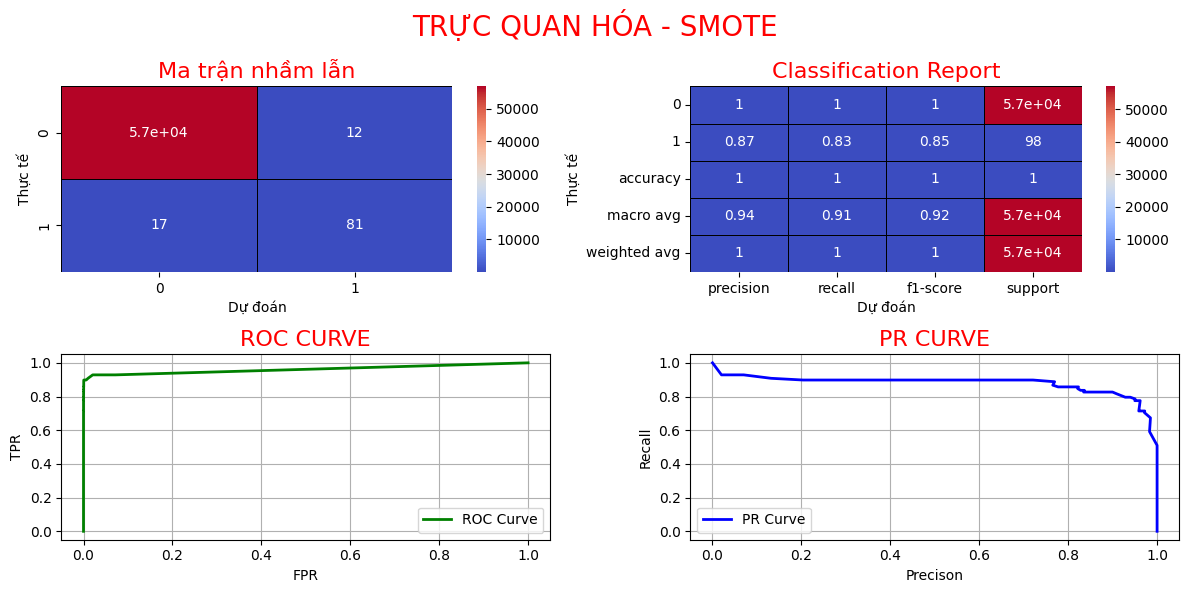

In [ ]:
y_pred = best_model.predict(X_test)

y_prob = best_model.predict_proba(X_test)[:, 1]

result = eva_and_viz_model(best_model, X_test, y_test, y_pred, y_prob, best_method)

##✅8. Xây dựng Pipeline

### 👉 Code mẫu


In [ ]:
import pandas as pd
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV

from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.neural_network import MLPClassifier

from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from scipy.stats import randint, loguniform

# ========================
# Tiền xử lý cơ bản
# ========================

# Ví dụ: log-transform cột Amount để giảm lệch
def log_transform_amount(X):
    X = X.copy()
    if "Amount" in X.columns:
        X["Amount"] = np.log1p(X["Amount"])

    return X

amount_pipeline = Pipeline([
    ('log', FunctionTransformer(
        log_transform_amount,
        validate = False
    ))
    ("scale", RobustScaler())
])

preprocess = ColumnTransformer(
    transformers = [
        ("amount", amount_pipeline, ["Amount"]),
        ("pca_features", "passthrough", [col for col in X.columns if col != "Amount"])
    ]
)

# Pipeline tiền xử lý
preprocess = Pipeline(
    steps = [
        ("log_amount", FunctionTransformer(
            log_transform_amount,
            validate = False
          )),
        ("scale", RobustScaler())
    ])

# ========================
# Pipeline tổng hợp
# ========================
pipe = ImbPipeline(steps=[
    ("preprocess", preprocess),
    ("sampler", SMOTE(random_state=42)),
    ("clf", MLPClassifier(max_iter=200, random_state=42))
])

# ========================
# Không gian tham số
# ========================
param_dist = {
    "sampler": [SMOTE(random_state=42), "passthrough"],  # có sampling hoặc không
    "clf__hidden_layer_sizes": [(128,64,32), (64,32), (32,16), (128,128)],
    "clf__alpha": loguniform(1e-5, 1e-2),   # regularization strength
    "clf__learning_rate_init": loguniform(1e-4, 1e-1),
    "clf__batch_size": [32, 64, 128]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=20,              # thử 20 tổ hợp
    cv=cv,
    scoring="average_precision",
    n_jobs=-1,
    random_state=42
)

# ========================
# Train + đánh giá
# ========================
X = df.drop(["Class", "Time"], axis=1)
y = df["Class"]

search.fit(X, y)

print("Best params:", search.best_params_)
print("Best score:", search.best_score_)


### 👉 Triển khai Training_Pipe


In [ ]:
import pandas as pd
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV

from sklearn.base import BaseEstimator, TransformerMixin

from sklearn.preprocessing import RobustScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer

from sklearn.neural_network import MLPClassifier

from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from scipy.stats import randint, loguniform

df = read_and_explore_data(file_path, show = False)

X = df.drop(["Class"], axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, stratify = y, random_state = 42
)

# ========================
# Tiền xử lý cơ bản
# ========================

class FeatureEngineer(BaseEstimator, TransformerMixin):
    def fit(self, X, y = None):
        return self

    def transform(self, X):
        X = X.copy()
        # Tạo cột 'hour' trong df

        X['Hour'] = X['Time']/3600%24

        X = X.drop(["Time"], axis = 1)

        X["Is_Night"] = ((X['Hour'] >= 0) & (X['Hour'] <= 5)).astype(int)

        X['High_Amount'] = (X['Amount'] > 1000).astype(int)

        bins = [0, 100, 500, 1000, 5000, 2000000]
        labels = [0, 1, 2, 3, 4]
        X['Amount_Bins'] = pd.cut(X['Amount'], bins = bins, labels = labels, include_lowest=True)
        X['Amount_Bins'] = X['Amount_Bins'].astype(int)

        X['High_Amount_at_Night'] = (X['High_Amount'] & X['Is_Night']).astype(int)
        return X

# Ví dụ: log-transform cột Amount để giảm lệch
def log_transform_amount(X):
    X = X.copy()
    if "Amount" in X.columns:
        X["Amount"] = np.log1p(X["Amount"])

    return X

amount_pipeline = Pipeline([
    ('log', FunctionTransformer(
        log_transform_amount,
        validate = False
    )),
    ("scale", RobustScaler())
])

preprocess = ColumnTransformer(
    transformers = [
        ("amount", amount_pipeline, ["Amount"])
    ],
    remainder = "passthrough",  # tất cả cột khác giữ nguyên
    force_int_remainder_cols = False
)

MLP_ = MLP_Grid(
    num_epochs = 15,
    threshold = 0.5,
    verbose = True, vis = True,
    n_noron_1 = 64,
    n_noron_2 = 32,
    n_noron_3 = 16
)

# ========================
# Pipeline tổng hợp
# ========================

# pipe = ImbPipeline(steps=[
#     ("feature_engineer", FeatureEngineer()),
#     ("preprocess", preprocess),
#     ("sampler", SMOTE(random_state=42)),
#     ("clf", MLP_)
# ])

pipe = Pipeline(steps=[
    ("feature_engineer", FeatureEngineer()),
    ("preprocess", preprocess),
    #("sampler", SMOTE(random_state=42)),
    ("clf", MLP_)
])

pipe.fit(X_train, y_train)


1. Đọc và khám phá dữ liệu
----------------------------------------------------------------------------------------------------
Kích thước dữ liệu: (284807, 31)
Epoch 1/15 - Loss: 0.0374
Epoch 2/15 - Loss: 0.0043
Epoch 3/15 - Loss: 0.0038
Epoch 4/15 - Loss: 0.0036
Epoch 5/15 - Loss: 0.0034
Epoch 6/15 - Loss: 0.0033
Epoch 7/15 - Loss: 0.0031
Epoch 8/15 - Loss: 0.0031
Epoch 9/15 - Loss: 0.0028
Epoch 10/15 - Loss: 0.0030
Epoch 11/15 - Loss: 0.0028
Epoch 12/15 - Loss: 0.0027
Epoch 13/15 - Loss: 0.0027
Epoch 14/15 - Loss: 0.0027
Epoch 15/15 - Loss: 0.0025
----------------------------------------------------------------------------------------------------
Đã huấn luyện!
----------------------------------------------------------------------------------------------------


Pipeline(steps=[('feature_engineer', FeatureEngineer()),
                ('preprocess',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('amount',
                                                  Pipeline(steps=[('log',
                                                                   FunctionTransformer(func=<function log_transform_amount at 0x7dab98573a60>)),
                                                                  ('scale',
                                                                   RobustScaler())]),
                                                  ['Amount'])])),
                ('clf',
                 MLP_Grid(n_noron_1=64, n_noron_2=32, n_noron_3=16,
                          num_epochs=15, vis=True))])

Tiến hành đánh giá mô hình: 
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Độ chính xác mô hình là:  0.9990519995786665
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Đã tính Ma trận nhầm lẫn! 
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Đã tính Classification Report! 
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Đã tính ROC-AUC!
----------------------------------------------

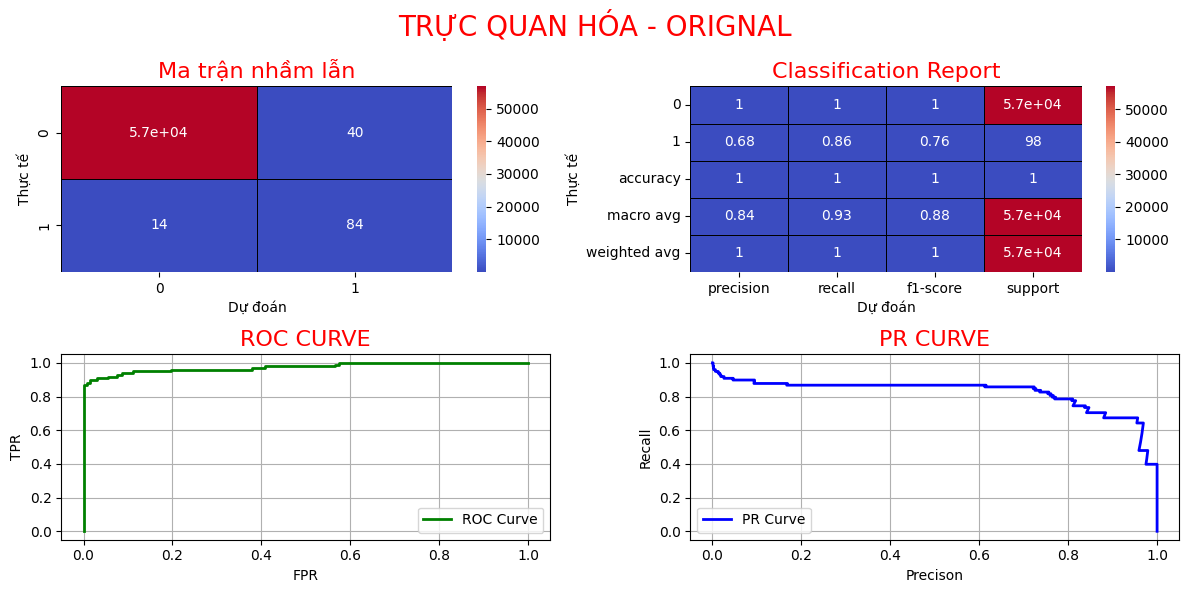

In [ ]:
y_pred = pipe.predict(X_test)
y_prob = pipe.predict_proba(X_test)[:, 1]

method =  "Orignal"
result = eva_and_viz_model(X_test, y_test, y_pred, y_prob, method, show = True)

### 👉 Triển khai Grid_Pipe


In [ ]:
import pandas as pd
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV

from sklearn.base import BaseEstimator, TransformerMixin

from sklearn.preprocessing import RobustScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer

from sklearn.neural_network import MLPClassifier

from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTEENN, SMOTETomek

from scipy.stats import randint, loguniform

df = read_and_explore_data(file_path, show = False)

X = df.drop(["Class"], axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, stratify = y, random_state = 42
)

# ========================
# Tiền xử lý cơ bản
# ========================

class FeatureEngineer(BaseEstimator, TransformerMixin):
    def fit(self, X, y = None):
        return self

    def transform(self, X):
        X = X.copy()
        # Tạo cột 'hour' trong df

        X['Hour'] = X['Time']/3600%24

        X = X.drop(["Time"], axis = 1)

        X["Is_Night"] = ((X['Hour'] >= 0) & (X['Hour'] <= 5)).astype(int)

        X['High_Amount'] = (X['Amount'] > 1000).astype(int)

        bins = [0, 100, 500, 1000, 5000, 2000000]
        labels = [0, 1, 2, 3, 4]
        X['Amount_Bins'] = pd.cut(X['Amount'], bins = bins, labels = labels, include_lowest=True)
        X['Amount_Bins'] = X['Amount_Bins'].astype(int)

        X['High_Amount_at_Night'] = (X['High_Amount'] & X['Is_Night']).astype(int)
        return X

# Ví dụ: log-transform cột Amount để giảm lệch
def log_transform_amount(X):
    X = X.copy()
    if "Amount" in X.columns:
        X["Amount"] = np.log1p(X["Amount"])

    return X

amount_pipeline = Pipeline([
    ('log', FunctionTransformer(
        log_transform_amount,
        validate = False
    )),
    ("scale", RobustScaler())
])

preprocess = ColumnTransformer(
    transformers = [
        ("amount", amount_pipeline, ["Amount"])
    ],
    remainder = "passthrough",  # tất cả cột khác giữ nguyên
    force_int_remainder_cols = False
)

MLP_ = MLP_Grid(
    num_epochs = 15,
    threshold = 0.5,
    verbose = True, vis = True,
    n_noron_1 = 64,
    n_noron_2 = 32,
    n_noron_3 = 16
)

# ========================
# Pipeline tổng hợp
# ========================

pipe = ImbPipeline(steps=[
    ("feature_engineer", FeatureEngineer()),
    ("preprocess", preprocess),
    ("sampler", SMOTE(sampling_strategy = 0.1, random_state=42)),
    ("clf", MLP_)
])

# ========================
# Không gian tham số
# ========================
param_dist = {
    "sampler": [
        SMOTE(sampling_strategy = 0.1, random_state=42),
        RandomUnderSampler(sampling_strategy = 0.1, random_state = 42),
        SMOTEENN(sampling_strategy = 0.1, random_state=42),
        "passthrough"
      ],  # có sampling hoặc không
    "clf__n_noron_1": [16, 64, 32],
    "clf__n_noron_2": [32, 16],
    "clf__n_noron_3": [16, 8],
    "clf__lr":  [0.01, 0.001],
    "clf__batch_size": [128, 256, 512],
    "clf__num_epochs": [5, 10]
}

cv = StratifiedKFold(
    n_splits = 3,
    shuffle = True,
    random_state = 42
  )

search = RandomizedSearchCV(
    estimator = pipe,
    param_distributions = param_dist,
    n_iter = 20,              # thử 20 tổ hợp
    cv = cv,
    scoring = "average_precision",
    n_jobs = -1,
    random_state = 42
)

search.fit(X, y)

print("Best params:", search.best_params_)
print("Best score:", search.best_score_)


1. Đọc và khám phá dữ liệu
----------------------------------------------------------------------------------------------------
Kích thước dữ liệu: (284807, 31)


## ✅9.	Tìm ngưỡng tối ưu


    Xác định ngưỡng xác suất tối ưu để phân loại giao dịch gian lận.

Flow:

    - Lấy xác suất dự đoán
    - Tính Precison, Recall, thresholds với precision_recall_curve(y_test, y_probs)
    - Tính F1-score
    - Tìm chỉ số f1_score max
    - Tìm threshold tương ứng

Trực quan hóa:

    - Vẽ đồ thị precision, recall theo ngưỡng
    - Đánh giá mô hình:
        - Ma trận nhầm lẫn
        - Classification Report

### 👉 Tìm ngưỡng tối ưu

In [ ]:
def Optimize_Threshold(model, X_test, y_test, target_recall = 0.8):
    from sklearn.metrics import precision_recall_curve
    # Dự đoán
    y_prob = model.predict_proba(X_test)[:, 1]

    precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)

    # Tính F1-score theo từng threshold
    f1s = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)

    best_idx = (np.abs(recalls - target_recall)).argmin()

    best_threshold = thresholds[best_idx]

    plt.plot(thresholds, recalls[:-1], label='Recall')
    plt.plot(thresholds, precisions[:-1], label='Precision')
    plt.axvline(x=best_threshold, color='red', linestyle='--', label=f'Best Threshold: {best_threshold:.2f}')
    plt.xlabel("Threshold")
    plt.ylabel("Score")
    plt.title("Precision & Recall vs Threshold")
    plt.legend()
    plt.grid()
    plt.show()

    print()
    print("Kết quả chọn ngưỡng:")
    print(f"Gần đúng recall = {recalls[best_idx]:.4f}")
    print(f"Tại threshold = {thresholds[best_idx]:.4f}")
    print(f"Precision tương ứng = {precisions[best_idx]:.4f}")
    print()

    # Lấy xác suất dự đoán class 1
    y_prob = model.predict_proba(X_test)[:, 1]

    # Chọn threshold mong muốn
    custom_threshold = thresholds[best_idx]  # hoặc tự chọn ví dụ 0.3

    # Tạo nhãn dự đoán theo ngưỡng
    y_pred = (y_prob >= custom_threshold).astype(int)

    # Độ chính xác
    print(f"Độ chính xác mô hình: {accuracy_score(y_test, y_pred)}")
    # Ma trận nhầm lẫn

    print(f"Ma trận nhầm lẫn:")
    print(confusion_matrix(y_test, y_pred))

    # Báo cáo phân loại (Classification Report)
    print(classification_report(y_test, y_pred))

    return best_threshold


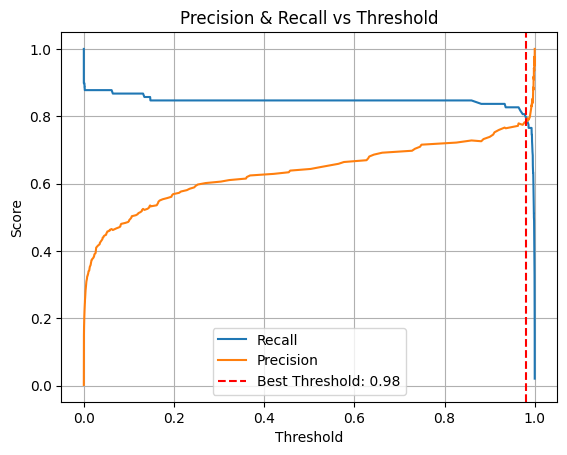


Kết quả chọn ngưỡng:
Gần đúng recall = 0.7959
Tại threshold = 0.9805
Precision tương ứng = 0.7800

Độ chính xác mô hình: 0.9992626663389628
Ma trận nhầm lẫn:
[[56842    22]
 [   20    78]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.78      0.80      0.79        98

    accuracy                           1.00     56962
   macro avg       0.89      0.90      0.89     56962
weighted avg       1.00      1.00      1.00     56962



In [ ]:
best_threshold = Optimize_Threshold(best_model, X_test, y_test, target_recall = 0.8)

### 👉 Trực quan hóa sau tối ưu ngưỡng

Tiến hành đánh giá mô hình: 
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Độ chính xác mô hình là:  0.9992802219023208
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Đã tính Ma trận nhầm lẫn! 
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Đã tính Classification Report! 
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Đã tính ROC-AUC!
----------------------------------------------

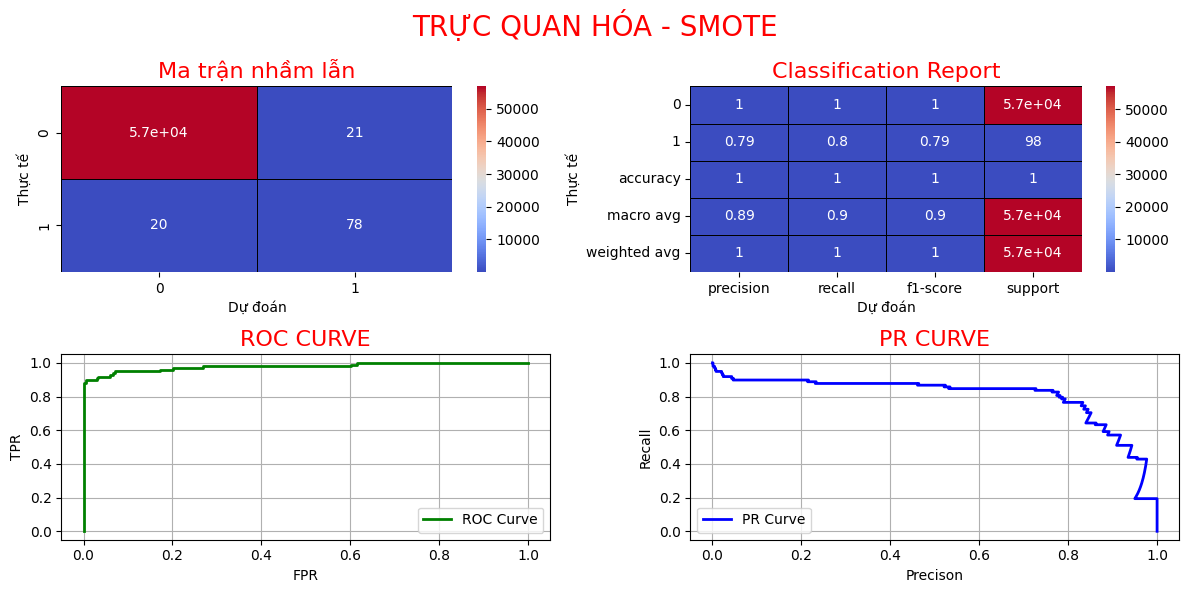

    solu   roc_auc    pr_auc
0  smote  0.978116  0.804905


In [ ]:
y_probs = best_model.predict_proba(X_test)[:,1]

y_pred = (y_probs > best_threshold).astype(int)

end_output = eva_and_viz_model(X_test, y_test, y_pred, y_probs, best_method['solu'], show = True)
print(pd.DataFrame([end_output]))

### 👉 9.1 Train lại model đã GridSearchCV

Tại sao lại train lại?

    Ta train lại để demo nhanh, không cần GridSearchCV lại!

Epoch 1/10 - Loss: 0.1000
Epoch 2/10 - Loss: 0.0395
Epoch 3/10 - Loss: 0.0312
Epoch 4/10 - Loss: 0.0245
Epoch 5/10 - Loss: 0.0169
Epoch 6/10 - Loss: 0.0121
Epoch 7/10 - Loss: 0.0100
Epoch 8/10 - Loss: 0.0096
Epoch 9/10 - Loss: 0.0078
Epoch 10/10 - Loss: 0.0068
----------------------------------------------------------------------------------------------------
Đã huấn luyện!
----------------------------------------------------------------------------------------------------
Tiến hành đánh giá mô hình: 
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Độ chính xác mô hình là:  0.9989291106351603
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Đã tính Ma trận nhầm lẫn! 
-------------------

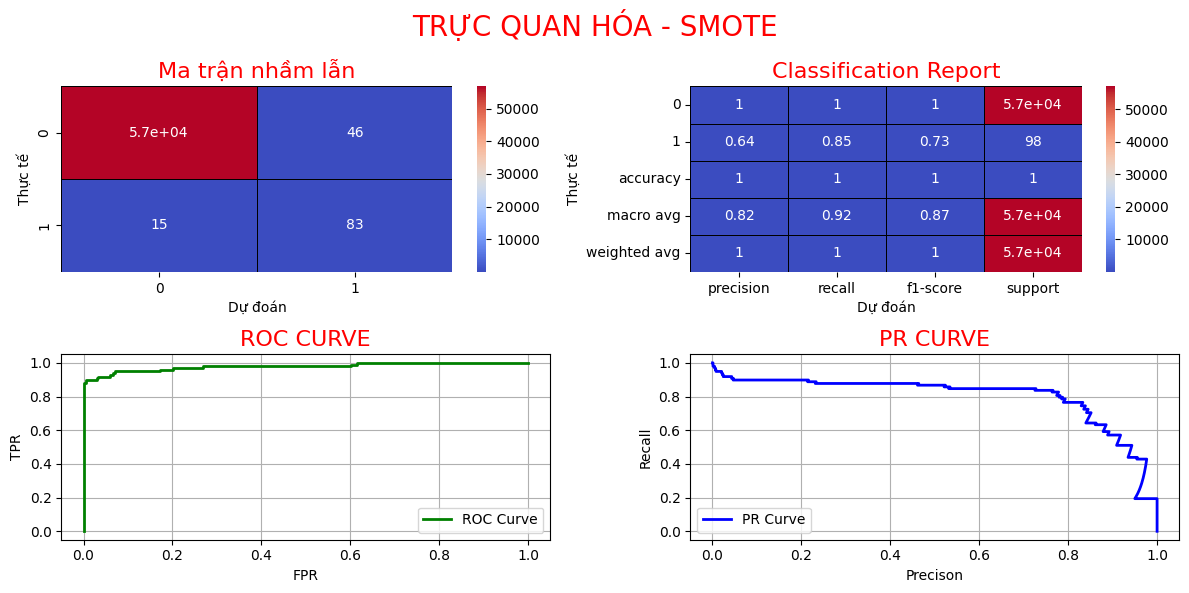

In [ ]:
best_model = MLP_Grid(
    num_epochs = 10,
    threshold = 0.5,
    verbose = True, vis = True,
    n_noron_1 = 64,
    n_noron_2 = 32,
    n_noron_3 = 16
)
#best_method = 'original'

X_train_end, y_train_end = resampled_data[best_method['solu']]

# Huấn luyện mô hình
best_model.fit(X_train_end, y_train_end)

# # Đánh giá mô hình, tìm y_pred
# y_pred = best_model.predict(X_test)

# Ngưỡng tối ưu
best_threshold = 0.5

# Tính xác suất dự đoán predict_proba
y_prob = best_model.predict_proba(X_test)[:, 1]

# Đánh giá mô hình
y_pred = (y_prob >= best_threshold).astype(int)

eva_end_model = eva_and_viz_model(X_test, y_test, y_pred, y_prob, best_method['solu'], show = True )

In [ ]:
eva_end_model = eva_and_viz_model(X_test, y_test, y_pred, y_prob, best_method['solu'])

Tiến hành đánh giá mô hình: 
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Độ chính xác mô hình là:  0.9987008883115059
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Đã tính Ma trận nhầm lẫn! 
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Đã tính Classification Report! 
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Đã tính ROC-AUC!
----------------------------------------------

In [ ]:
acr = accuracy_score(y_test, y_pred)

# Tính Ma trận nhầm lẫn
c_matrix = confusion_matrix(y_test, y_pred)
print('Đã tính Ma trận nhầm lẫn! ')
print('-'*200)

Đã tính Ma trận nhầm lẫn! 
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


### 👉 9.2 Lưu mô hình huấn luyện

In [ ]:
import joblib

# Lưu mô hình RandomForest đã huấn luyện
joblib.dump(best_model, "credit_card_fraud_detection_mlp.pkl")
print("Mô hình đã được lưu!")

Mô hình đã được lưu!


### 👉 9.3 Tải model về máy


In [ ]:
from google.colab import files
# Tải tệp về máy local
files.download("credit_card_fraud_detection_mlp.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>